<a href="https://colab.research.google.com/github/chonthicha-homprommaa/SC663402-Data-Warehouse-and-Big-Data-Analytics/blob/main/SC663402_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

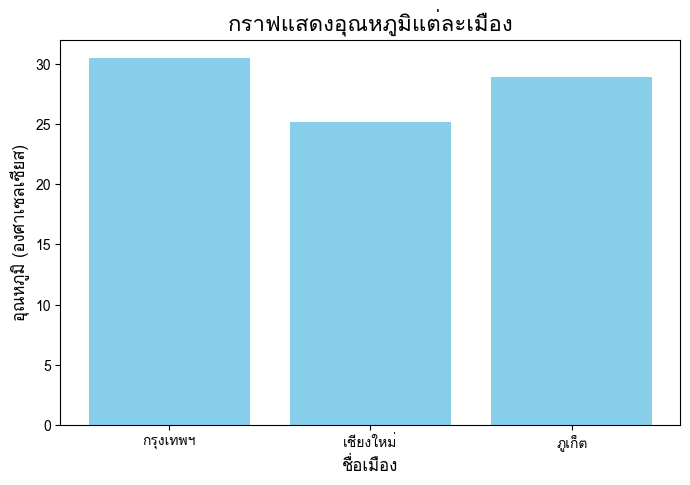

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1

# 1) สร้าง Series ปริมาณฝนรวมของแต่ละเมือง
rain_by_city = (
    df.groupby("city")["rainfall_mm"]
      .sum()
)

print("rain_by_city:")
display(rain_by_city)

# 2) เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top3_rain = rain_by_city.nlargest(3)

print("\n3 เมืองที่มีปริมาณฝนรวมสูงสุด:")
display(top3_rain)

# 3) สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด (%)
rain_share_pct = (
    rain_by_city / rain_by_city.sum() * 100
).round(2)

print("\nสัดส่วนปริมาณฝนของแต่ละเมือง (%):")
display(rain_share_pct)

# 4) จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย
avg_rain = rain_by_city.mean()

n_above_avg = (
    rain_by_city > avg_rain
).sum()

print("\nค่าเฉลี่ยปริมาณฝนรวมของทุกเมือง:", avg_rain)
print("จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย:", n_above_avg)

rain_by_city:


,rainfall_mm
city,
Auckland,351.9
Bangkok,685.6
Beijing,250.1
Berlin,268.4
Buenos Aires,305.1
Cairo,123.0
Cape Town,239.3
Chiang Mai,435.6
Lagos,652.8



3 เมืองที่มีปริมาณฝนรวมสูงสุด:


,rainfall_mm
city,
Singapore,870.4
Bangkok,685.6
Lagos,652.8



สัดส่วนปริมาณฝนของแต่ละเมือง (%):


,rainfall_mm
city,
Auckland,4.22
Bangkok,8.21
Beijing,3.00
Berlin,3.21
Buenos Aires,3.65
Cairo,1.47
Cape Town,2.87
Chiang Mai,5.22
Lagos,7.82



ค่าเฉลี่ยปริมาณฝนรวมของทุกเมือง: 362.97391304347815
จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย: 8


### ผลข้อ 2.1

จากการรวมปริมาณฝน (`rainfall_mm`) แยกตามเมือง พบว่าเมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก ได้แก่
Singapore 870.4 มม., Bangkok 685.6 มม. และ Lagos 652.8 มม.

เมื่อคำนวณสัดส่วนเทียบกับปริมาณฝนรวมทั้งหมด พบว่า Singapore มีสัดส่วนสูงสุด 10.43%
รองลงมาคือ Bangkok 8.21% และ Lagos 7.82%

ค่าเฉลี่ยของปริมาณฝนรวมต่อเมืองอยู่ที่ประมาณ 362.97 มม.
และมีทั้งหมด 8 เมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยดังกล่าว

ในการวิเคราะห์นี้ใช้ `groupby()` เพื่อรวมข้อมูลตามเมือง และใช้การคำนวณจากข้อมูลโดยตรง
จึงไม่จำเป็นต้องกำหนดค่าคำตอบแบบคงที่

### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2

city_profile = (
    df.groupby("city", observed=True)
      .agg(
          country=("country", "first"),
          region=("region", "first"),
          n_records=("record_id", "size"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum")
      )
      .reset_index()
)

# ปัดทศนิยมให้อ่านง่าย
city_profile["avg_temp"] = city_profile["avg_temp"].round(2)
city_profile["total_rain"] = city_profile["total_rain"].round(2)

print("จำนวนเมืองทั้งหมด:", len(city_profile))
display(city_profile)


จำนวนเมืองทั้งหมด: 23


,city,country,region,n_records,avg_temp,total_rain
0,Auckland,New Zealand,Oceania,90,17.80,351.9
1,Bangkok,Thailand,Asia,91,32.45,685.6
2,Beijing,China,Asia,90,15.60,250.1
3,Berlin,Germany,Europe,90,12.38,268.4
4,Buenos Aires,Argentina,South America,90,19.17,305.1
5,Cairo,Egypt,Africa,91,26.09,123.0
6,Cape Town,South Africa,Africa,90,30.16,239.3
7,Chiang Mai,Thailand,Asia,91,29.68,435.6
8,Lagos,Nigeria,Africa,90,29.49,652.8
9,Lima,Peru,South America,90,21.49,180.3


### ผลข้อ 2.2

จากการใช้ `groupby()` สรุปข้อมูลรายเมือง ได้ `city_profile`
จำนวน 23 แถว ซึ่งตรงกับจำนวนเมืองทั้งหมดในข้อมูล และแต่ละเมืองมีเพียง 1 แถว

ในแต่ละแถวประกอบด้วยประเทศ ภูมิภาค จำนวนระเบียน (`n_records`)
อุณหภูมิเฉลี่ย (`avg_temp`) และปริมาณฝนรวม (`total_rain`) ของเมืองนั้น

ตัวอย่างเช่น Bangkok มีข้อมูล 91 ระเบียน อุณหภูมิเฉลี่ย 32.45°C
และปริมาณฝนรวม 685.6 มม. ส่วน Singapore มีอุณหภูมิเฉลี่ย 40.08°C
และปริมาณฝนรวม 870.4 มม.

การใช้ `groupby()` ช่วยย่อข้อมูลจากระดับรายวันให้เป็นข้อมูลสรุประดับเมือง
ทำให้สามารถเปรียบเทียบลักษณะของแต่ละเมืองได้ง่ายขึ้น

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1

df_import = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    },
    index_col="city"
)

print("Data types:")
display(df_import.dtypes)

print("\nDataFrame info:")
df_import.info()

Data types:


,0
date,datetime64[ns]
region,category
temperature_c,float64
humidity_pct,float64
rainfall_mm,float64



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### ผลข้อ 3.1

จากการนำเข้าข้อมูลด้วย `pd.read_csv()` เพียงคำสั่งเดียว พบว่าสามารถกำหนดรูปแบบข้อมูลได้ครบตามโจทย์ตั้งแต่ขั้นตอนการอ่านไฟล์

คอลัมน์ `date` ถูกแปลงเป็นชนิด `datetime64[ns]` และ `region` ถูกกำหนดเป็นชนิด `category`
ส่วน `city` ถูกใช้เป็น index ของ DataFrame จึงแสดงเป็น `CategoricalIndex` แทนการเป็นคอลัมน์ปกติ

ค่า `999` และ `-999` ถูกแปลงเป็นค่าว่าง ทำให้จำนวนค่า non-null ของบางคอลัมน์ลดลง เช่น
`temperature_c` เหลือ 2052 ค่า, `humidity_pct` เหลือ 1993 ค่า และ `rainfall_mm` เหลือ 2013 ค่า จากทั้งหมด 2075 แถว

การกำหนดชนิดข้อมูลตั้งแต่ขั้นตอนนำเข้าช่วยให้ข้อมูลพร้อมสำหรับการวิเคราะห์ต่อ และช่วยลดการใช้หน่วยความจำได้

### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
# คำตอบข้อ 3.2

# อ่านข้อมูลแบบปกติ
df_normal = pd.read_csv(
    BASE + "world_weather_sample.csv"
)

# หน่วยความจำรวมของตารางปกติ
normal_mem = df_normal.memory_usage(deep=True).sum()

# หน่วยความจำรวมของตารางจากข้อ 3.1
optimized_mem = df_import.memory_usage(deep=True).sum()

# คำนวณร้อยละที่ลดลง
reduction_pct = (
    (normal_mem - optimized_mem)
    / normal_mem
    * 100
)

print(f"หน่วยความจำตารางปกติ: {normal_mem:,} bytes")
print(f"หน่วยความจำตารางจากข้อ 3.1: {optimized_mem:,} bytes")
print(f"ลดลง: {reduction_pct:.2f}%")

# ดูหน่วยความจำของแต่ละคอลัมน์ในตารางปกติ
print("\nหน่วยความจำของแต่ละคอลัมน์ในตารางปกติ:")
normal_col_mem = (
    df_normal.memory_usage(deep=True)
    .sort_values(ascending=False)
)

display(normal_col_mem)

หน่วยความจำตารางปกติ: 571,645 bytes
หน่วยความจำตารางจากข้อ 3.1: 72,917 bytes
ลดลง: 87.24%

หน่วยความจำของแต่ละคอลัมน์ในตารางปกติ:


,0
date,122425
region,117631
city,116920
country,114937
record_id,16600
humidity_pct,16600
temperature_c,16600
wind_speed_kmh,16600
rainfall_mm,16600
pressure_hpa,16600


### อธิบายผลข้อ 3.2

ตารางที่นำเข้าตามปกติใช้หน่วยความจำ 571,645 bytes
ขณะที่ตารางจากข้อ 3.1 ใช้ 72,917 bytes ทำให้การใช้หน่วยความจำลดลงประมาณ 87.24%

คอลัมน์ที่มีผลต่อการลดลงของหน่วยความจำอย่างมากคือ `region` และ `city`
เนื่องจากในตารางปกติข้อมูลข้อความมีการเก็บค่าเดิมซ้ำหลายครั้ง
แต่ในข้อ 3.1 ได้กำหนดให้เป็นชนิด `category`
ซึ่งเก็บค่าหมวดหมู่ที่ไม่ซ้ำเพียงครั้งเดียวและใช้รหัสอ้างอิงแทน จึงใช้หน่วยความจำน้อยลงมาก

นอกจากนี้ `date` เดิมถูกอ่านเป็นข้อความและใช้หน่วยความจำสูงถึง 122,425 bytes
แต่เมื่อแปลงเป็น `datetime` จะมีรูปแบบการจัดเก็บที่มีประสิทธิภาพมากขึ้น

อีกสาเหตุหนึ่งที่ทำให้หน่วยความจำลดลงมาก คือข้อ 3.1 อ่านเฉพาะคอลัมน์ที่จำเป็น
จึงตัดคอลัมน์ที่ไม่ได้ใช้ เช่น `country`, `record_id`, `wind_speed_kmh`
และ `pressure_hpa` ออกจากตารางตั้งแต่ขั้นตอนการนำเข้า

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3

# กำหนดค่าเริ่มต้น
global_min = np.inf
global_max = -np.inf

# ใช้สะสมผลรวมและจำนวนข้อมูลของแต่ละเมือง
city_sum = pd.Series(dtype="float64")
city_count = pd.Series(dtype="float64")

# อ่านข้อมูลทีละก้อน
for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "temperature_c"],
    na_values=[999, -999],
    chunksize=500
):

    # -----------------------------
    # 1) หาอุณหภูมิต่ำสุดและสูงสุด
    # -----------------------------
    chunk_min = chunk["temperature_c"].min()
    chunk_max = chunk["temperature_c"].max()

    if pd.notna(chunk_min):
        global_min = min(global_min, chunk_min)

    if pd.notna(chunk_max):
        global_max = max(global_max, chunk_max)

    # -----------------------------
    # 2) สะสมผลรวมและจำนวนข้อมูลรายเมือง
    # -----------------------------
    chunk_sum = (
        chunk.groupby("city")["temperature_c"]
             .sum()
    )

    chunk_count = (
        chunk.groupby("city")["temperature_c"]
             .count()
    )

    city_sum = city_sum.add(chunk_sum, fill_value=0)
    city_count = city_count.add(chunk_count, fill_value=0)


# คำนวณค่าเฉลี่ยรายเมืองจากผลรวมทั้งหมด / จำนวนข้อมูลทั้งหมด
city_avg_temp = (
    city_sum / city_count
).sort_index()


print(f"อุณหภูมิต่ำสุดของทั้งไฟล์: {global_min:.2f} °C")
print(f"อุณหภูมิสูงสุดของทั้งไฟล์: {global_max:.2f} °C")

print("\nอุณหภูมิเฉลี่ยรายเมือง:")
display(
    city_avg_temp.rename("avg_temperature_c")
)

อุณหภูมิต่ำสุดของทั้งไฟล์: -88.00 °C
อุณหภูมิสูงสุดของทั้งไฟล์: 39.20 °C

อุณหภูมิเฉลี่ยรายเมือง:


,avg_temperature_c
city,
Auckland,17.804444
Bangkok,32.453846
Beijing,15.598876
Berlin,12.383146
Buenos Aires,19.171910
Cairo,26.089888
Cape Town,19.153409
Chiang Mai,29.680220
Lagos,29.494253


### อธิบายผลข้อ 3.3

จากการอ่านข้อมูลทีละก้อนด้วย `chunksize` พบว่าอุณหภูมิต่ำสุดของทั้งไฟล์คือ
-88.00°C และอุณหภูมิสูงสุดคือ 39.20°C

สำหรับอุณหภูมิเฉลี่ยรายเมือง คำนวณโดยสะสมผลรวม (`sum`)
และจำนวนค่าที่ไม่ว่าง (`count`) ของแต่ละเมืองจากทุก chunk
แล้วจึงนำผลรวมทั้งหมดหารด้วยจำนวนข้อมูลทั้งหมด

ไม่ควรนำค่าเฉลี่ยของแต่ละ chunk มาเฉลี่ยกันโดยตรง
เพราะแต่ละ chunk อาจมีจำนวนข้อมูลของแต่ละเมืองไม่เท่ากัน
จึงทำให้แต่ละก้อนได้รับน้ำหนักเท่ากันทั้งที่มีจำนวนข้อมูลจริงต่างกัน

การสะสม `sum` และ `count` จึงให้ค่าเฉลี่ยที่ถูกต้องกว่า
และยังสามารถวิเคราะห์ข้อมูลโดยไม่ต้องโหลดทั้งไฟล์เข้าหน่วยความจำพร้อมกัน

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "example_value": df.bfill().iloc[0]
})

# ตั้งชื่อ index ให้ชัดเจน
summary.index.name = "column"

# เรียงจากคอลัมน์ที่มีค่าว่างมากที่สุด
summary = summary.sort_values(
    by="n_missing",
    ascending=False
)

display(summary)

,dtype,n_missing,pct_missing,n_unique,example_value
column,,,,,
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
wind_speed_kmh,float64,41,1.98,278,15.9
pressure_hpa,float64,32,1.54,294,1005.4
temperature_c,float64,20,0.96,331,15.7
record_id,int64,0,0.00,2070,983
date,object,0,0.00,90,2025-03-24
region,object,0,0.00,6,North America
city,object,0,0.00,23,New York


### อธิบายผลข้อ 4.1

จากการสรุปคุณภาพข้อมูลรายคอลัมน์ พบว่า `humidity_pct`
มีค่าว่างมากที่สุดจำนวน 82 ค่า คิดเป็น 3.95%
รองลงมาคือ `rainfall_mm` จำนวน 62 ค่า หรือ 2.99%

คอลัมน์ `wind_speed_kmh`, `pressure_hpa` และ `temperature_c`
มีค่าว่างในสัดส่วนที่น้อยกว่า ขณะที่ `record_id`, `date`,
`region`, `city` และ `country` ไม่มีค่าว่าง

ตาราง `summary` ช่วยให้สามารถตรวจสอบชนิดข้อมูล จำนวนและสัดส่วนค่าว่าง
จำนวนค่าที่ไม่ซ้ำ รวมถึงตัวอย่างค่าของแต่ละคอลัมน์ได้ในตารางเดียว
และถูกเรียงจากคอลัมน์ที่มีค่าว่างมากที่สุดเพื่อให้เห็นปัญหาได้ชัดเจน

### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2

# 1) temperature_c นอกช่วง -60 ถึง 60
temp_invalid = ~df["temperature_c"].between(-60, 60)

# ไม่ให้นับ missing เป็นค่าผิดปกติ
temp_invalid = temp_invalid & df["temperature_c"].notna()

# 2) humidity_pct นอกช่วง 0 ถึง 100
humidity_invalid = ~df["humidity_pct"].between(0, 100)

# ไม่ให้นับ missing เป็นค่าผิดปกติ
humidity_invalid = humidity_invalid & df["humidity_pct"].notna()

# 3) ผิดปกติอย่างน้อยหนึ่งคอลัมน์
any_invalid = temp_invalid | humidity_invalid

print(
    "จำนวนแถวที่ temperature_c อยู่นอกช่วง -60 ถึง 60:",
    temp_invalid.sum()
)

print(
    "จำนวนแถวที่ humidity_pct อยู่นอกช่วง 0 ถึง 100:",
    humidity_invalid.sum()
)

print(
    "จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์:",
    any_invalid.sum()
)

# แสดงตัวอย่างแถวที่ผิดปกติ
display(
    df.loc[
        any_invalid,
        ["city", "date", "temperature_c", "humidity_pct"]
    ].head(10)
)

จำนวนแถวที่ temperature_c อยู่นอกช่วง -60 ถึง 60: 5
จำนวนแถวที่ humidity_pct อยู่นอกช่วง 0 ถึง 100: 3
จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: 8


column,city,date,temperature_c,humidity_pct
25,Singapore,2025-03-05,31.5,150.0
37,Los Angeles,2025-01-27,17.3,150.0
78,Cape Town,2025-02-10,999.0,61.2
499,Singapore,2025-01-16,-88.0,96.4
712,Paris,2025-03-28,999.0,82.7
1280,Buenos Aires,2025-01-19,-88.0,63.5
1855,Singapore,2025-03-11,999.0,72.0
2068,Bangkok,2025-02-25,34.4,150.0


### อธิบายผลข้อ 4.2

พบแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60 จำนวน 5 แถว
และพบแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100 จำนวน 3 แถว

เมื่อนำสองเงื่อนไขมารวมด้วย OR พบแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ทั้งหมด 8 แถว
ซึ่งช่วยป้องกันการนับแถวเดิมซ้ำในกรณีที่แถวเดียวกันมีความผิดปกติมากกว่าหนึ่งคอลัมน์

ค่าที่พบ เช่น `temperature_c = 999`, `temperature_c = -88`
และ `humidity_pct = 150` เป็นค่าที่อยู่นอกช่วงที่โจทย์กำหนด
จึงควรถูกตรวจสอบเพิ่มเติมก่อนนำไปวิเคราะห์ต่อ

### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3

# ------------------------------------------------------------
# 1) ดูค่าประเทศที่ถูกเขียนต่างรูปแบบกัน
# ------------------------------------------------------------

print("ค่าประเทศก่อน normalize:")
display(
    df["country"]
    .value_counts()
    .sort_index()
)

print("\nจำนวนประเทศที่ไม่ซ้ำก่อน normalize:",
      df["country"].nunique())


# ------------------------------------------------------------
# 2) ทดลองใช้ str.title()
# ------------------------------------------------------------

country_title = df["country"].str.strip().str.title()

print("\nค่าประเทศหลังใช้ str.title():")
display(
    country_title
    .value_counts()
    .sort_index()
)

print("\nจำนวนประเทศที่ไม่ซ้ำหลังใช้ str.title():",
      country_title.nunique())


# ------------------------------------------------------------
# 3) Normalize อย่างเหมาะสม
# ------------------------------------------------------------

country_clean = (
    df["country"]
    .str.strip()
    .str.lower()
)

# mapping ชื่อประเทศให้เป็นรูปแบบมาตรฐาน
country_mapping = {
    "usa": "USA",
    "uk": "UK",
    "new zealand": "New Zealand",
    "south africa": "South Africa",
    "argentina": "Argentina",
    "australia": "Australia",
    "brazil": "Brazil",
    "canada": "Canada",
    "china": "China",
    "egypt": "Egypt",
    "france": "France",
    "germany": "Germany",
    "india": "India",
    "japan": "Japan",
    "kenya": "Kenya",
    "mexico": "Mexico",
    "nigeria": "Nigeria",
    "peru": "Peru",
    "russia": "Russia",
    "singapore": "Singapore",
    "thailand": "Thailand"
}

df["country_normalized"] = (
    country_clean
    .map(country_mapping)
)

print("\nจำนวนประเทศหลัง normalize:",
      df["country_normalized"].nunique())

display(
    df[["country", "country_normalized"]]
    .drop_duplicates()
    .sort_values("country_normalized")
)

ค่าประเทศก่อน normalize:


,count
country,
ARGENTINA,1
Argentina,89
Australia,90
Brazil,90
CANADA,2
Canada,88
China,90
Egypt,91
France,90



จำนวนประเทศที่ไม่ซ้ำก่อน normalize: 28

ค่าประเทศหลังใช้ str.title():


,count
country,
Argentina,90
Australia,90
Brazil,90
Canada,90
China,90
Egypt,91
France,90
Germany,90
India,90



จำนวนประเทศที่ไม่ซ้ำหลังใช้ str.title(): 21

จำนวนประเทศหลัง normalize: 21


column,country,country_normalized
1371,ARGENTINA,Argentina
6,Argentina,Argentina
17,Australia,Australia
60,Brazil,Brazil
433,CANADA,Canada
92,Canada,Canada
12,China,China
43,Egypt,Egypt
22,France,France
366,GERMANY,Germany


### อธิบายผลข้อ 4.3

ก่อน normalize พบชื่อประเทศที่ไม่ซ้ำทั้งหมด 28 ค่า
ทั้งที่ข้อมูลจริงควรมี 21 ประเทศ สาเหตุเกิดจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ
เช่น `ARGENTINA` กับ `Argentina`, `CANADA` กับ `Canada`
และ `SINGAPORE` กับ `Singapore` ถูกนับเป็นคนละค่า

เมื่อทดลองใช้ `.str.title()` จำนวนประเทศลดลงเหลือ 21 ประเทศ
แต่ทำให้ชื่อประเทศที่เป็นตัวย่อเสียรูปแบบ เช่น `USA` ถูกเปลี่ยนเป็น `Usa`
และ `UK` ถูกเปลี่ยนเป็น `Uk` เพราะ `title()` จะเปลี่ยนให้เฉพาะตัวอักษรแรก
ของแต่ละคำเป็นตัวพิมพ์ใหญ่

ดังนั้นวิธีที่เหมาะสมกว่าคือใช้ `.str.strip()` เพื่อตัดช่องว่างหัวท้าย
และแปลงข้อความเป็นรูปแบบเดียวกันก่อน แล้วใช้ mapping
เพื่อกำหนดชื่อประเทศมาตรฐาน โดยยังคงตัวย่อ `USA` และ `UK`
ให้เป็นตัวพิมพ์ใหญ่ตามรูปแบบที่ถูกต้อง

หลัง normalize แล้วเหลือ 21 ประเทศ ซึ่งตรงกับจำนวนประเทศที่โจทย์กำหนด
จากข้อมูลทั้งหมด 23 เมือง

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape,
      " city_info:", city_info.shape,
      " region_info:", region_info.shape)

df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


In [ ]:
# คำตอบข้อ 5.1

# 1) แถวตำแหน่งเลขคู่ 10 แถวแรก
#    เฉพาะ 3 คอลัมน์สุดท้าย
part1 = df.iloc[0:20:2, -3:]

print("1) แถวตำแหน่งเลขคู่ 10 แถวแรก + 3 คอลัมน์สุดท้าย")
display(part1)


# 2) ห้าแถวสุดท้าย เรียงจากแถวล่างสุดขึ้นไป
part2 = df.iloc[-1:-6:-1, :]

print("\n2) ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน")
display(part2)


# 3) ค่าเดี่ยวที่อยู่แถวกึ่งกลางตาราง + คอลัมน์สุดท้าย
middle_row = len(df) // 2

middle_value = df.iloc[middle_row, -1]

print("\n3) ตำแหน่งแถวกึ่งกลาง:", middle_row)
print("ค่าที่แถวกึ่งกลางและคอลัมน์สุดท้าย:", middle_value)

1) แถวตำแหน่งเลขคู่ 10 แถวแรก + 3 คอลัมน์สุดท้าย


,rainfall_mm,wind_speed_kmh,pressure_hpa
0,6.3,15.9,1005.4
2,1.2,8.6,1013.5
4,0.0,16.6,1015.1
6,2.7,14.6,1018.0
8,1.6,9.8,1007.7
10,0.0,15.6,1010.1
12,0.0,13.6,1015.8
14,2.2,24.6,1000.5
16,8.3,9.3,1019.4
18,8.9,23.3,1020.6



2) ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
2074,642,2025-01-12,Paris,France,Europe,11.1,65.8,6.3,20.4,1015.7
2073,1210,2025-02-09,Toronto,Canada,North America,NaN,65.0,9.1,6.9,1007.8
2072,1738,2025-01-28,Nairobi,Kenya,Africa,21.7,51.0,9.5,27.2,1013.9
2071,1769,2025-02-28,Nairobi,Kenya,Africa,20.6,65.8,3.7,13.3,1015.6
2070,1093,2025-01-13,Mexico City,Mexico,North America,17.8,63.3,7.4,10.5,1001.2



3) ตำแหน่งแถวกึ่งกลาง: 1037
ค่าที่แถวกึ่งกลางและคอลัมน์สุดท้าย: 1020.9


### อธิบายผลข้อ 5.1

ข้อ 1 ใช้ `.iloc[0:20:2, -3:]` เพื่อเลือกแถวตามตำแหน่งเลขคู่
ตั้งแต่ 0 ถึง 18 รวม 10 แถว และเลือกเฉพาะ 3 คอลัมน์สุดท้าย

ข้อ 2 ใช้ `.iloc[-1:-6:-1, :]` เพื่อเริ่มจากแถวสุดท้าย
แล้วไล่ย้อนขึ้นมา 5 แถว จึงได้ลำดับจาก index 2074 ถึง 2070

ข้อ 3 คำนวณตำแหน่งกึ่งกลางจาก `len(df) // 2`
ได้ตำแหน่ง 1037 และใช้ `.iloc[1037, -1]`
เพื่อดึงค่าเดี่ยวในคอลัมน์สุดท้าย ซึ่งมีค่าเท่ากับ 1020.9

การใช้ `.iloc[]` เป็นการเลือกข้อมูลตามตำแหน่งของแถวและคอลัมน์
จึงไม่จำเป็นต้องอ้างชื่อคอลัมน์ตามเงื่อนไขของโจทย์

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
# คำตอบข้อ 5.2

# สร้าง MultiIndex
multi = (
    df.set_index(["region", "city"])
      .sort_index()
)

# 1) ข้อมูลทั้งหมดของ Asia
#    เฉพาะ date และ temperature_c
asia_data = multi.loc[
    "Asia",
    ["date", "temperature_c"]
]

print("1) ข้อมูลภูมิภาค Asia")
display(asia_data)


# 2) ข้อมูล Tokyo และ Bangkok พร้อมกัน
tokyo_bangkok = multi.loc[
    (
        slice(None),
        ["Tokyo", "Bangkok"]
    ),
    :
]

print("\n2) ข้อมูล Tokyo และ Bangkok")
display(tokyo_bangkok)


# 3) ทุกภูมิภาค แต่เฉพาะเมืองที่ขึ้นต้นด้วย B
city_level = multi.index.get_level_values("city")

cities_b = multi.loc[
    city_level.str.startswith("B")
]

print("\n3) เมืองที่ชื่อขึ้นต้นด้วย B")
display(cities_b)

1) ข้อมูลภูมิภาค Asia


,date,temperature_c
city,,
Bangkok,2025-02-22,30.8
Bangkok,2025-01-10,28.9
Bangkok,2025-01-27,27.9
Bangkok,2025-01-03,29.0
Bangkok,2025-03-28,31.0
...,...,...
Tokyo,2025-01-08,15.3
Tokyo,2025-02-19,19.1
Tokyo,2025-01-02,16.3



2) ข้อมูล Tokyo และ Bangkok


record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Tokyo          220  2025-02-09     Japan           18.3          60.6   
       Tokyo          260  2025-03-21     Japan           19.7          67.4   
       Tokyo          262  2025-03-23     Japan           17.7          60.2   
       Tokyo          203  2025-01-23     Japan           20.8          61.6   
       Tokyo          218  2025-02-07     Japan           19.5          68.2   
...                   ...         ...       ...            ...           ...   
       Bangkok         30  2025-01-30  Thailand           33.9          65.1   
       Bangkok         61  2025-03-02  Thailand           31.4          70.5   
       Bangkok         12  2025-01-12  Thailand           33.1          68.3   
       Bangkok         60  2025-03-01  Thailand           31.7          82.2   
       Bangkok         56  2025-02-25  Thailand           34.4         150.0   

                rainfall_mm  wind_speed_kmh  pressure_hpa  
region city                                                
Asia   Tokyo            0.0            20.5        1015.1  
       Tokyo            2.8            16.6        1014.9  
       Tokyo            4.0            21.5        1015.8  
       Tokyo           12.3            10.9        1023.4  
       Tokyo            5.0            13.4        1011.8  
...                     ...             ...           ...  
       Bangkok          2.7            18.1        1014.8  
       Bangkok         11.0            18.7        1012.9  
       Bangkok          6.8            17.0        1018.9  
       Bangkok          9.2            19.9        1016.8  
       Bangkok          5.6            15.4        1010.7  

[181 rows x 8 columns]


3) เมืองที่ชื่อขึ้นต้นด้วย B


record_id        date    country  temperature_c  \
region        city                                                            
Asia          Bangkok              53  2025-02-22   Thailand           30.8   
              Bangkok              10  2025-01-10   Thailand           28.9   
              Bangkok              27  2025-01-27   Thailand           27.9   
              Bangkok               3  2025-01-03   Thailand           29.0   
              Bangkok              87  2025-03-28   Thailand           31.0   
...                               ...         ...        ...            ...   
South America Buenos Aires       1419  2025-03-10  Argentina           20.5   
              Buenos Aires       1386  2025-02-05  Argentina           17.0   
              Buenos Aires       1401  2025-02-20  Argentina           23.0   
              Buenos Aires       1416  2025-03-07  Argentina           24.8   
              Buenos Aires       1388  2025-02-07  Argentina           21.6   

                            humidity_pct  rainfall_mm  wind_speed_kmh  \
region        city                                                      
Asia          Bangkok               74.5          0.0             8.9   
              Bangkok               71.3         12.2            17.1   
              Bangkok               75.5          3.8            17.8   
              Bangkok               71.3          9.0             3.5   
              Bangkok               58.7          6.9            19.3   
...                                  ...          ...             ...   
South America Buenos Aires           NaN          0.0            22.1   
              Buenos Aires          68.2          0.0            14.6   
              Buenos Aires          53.8          5.9            13.6   
              Buenos Aires          74.4         11.2            18.4   
              Buenos Aires          79.6          1.2            12.4   

                            pressure_hpa  
region        city                        
Asia          Bangkok             1011.5  
              Bangkok             1002.4  
              Bangkok             1007.5  
              Bangkok             1002.7  
              Bangkok             1022.0  
...                                  ...  
South America Buenos Aires        1017.1  
              Buenos Aires        1006.6  
              Buenos Aires        1017.2  
              Buenos Aires        1012.1  
              Buenos Aires        1005.2  

[361 rows x 8 columns]

### อธิบายผลข้อ 5.2

ข้อ 1 ใช้ `.loc[]` กับ MultiIndex เพื่อเลือกข้อมูลทั้งหมดในภูมิภาค Asia
และเลือกเฉพาะคอลัมน์ `date` และ `temperature_c`
ได้ผลลัพธ์ทั้งหมด 542 แถว

ข้อ 2 เลือกข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
โดยอ้างอิงระดับ `city` ของ MultiIndex ได้ทั้งหมด 181 แถว

ข้อ 3 เลือกข้อมูลจากทุกภูมิภาค โดยตรวจชื่อเมืองจากระดับ `city`
และเลือกเฉพาะเมืองที่ขึ้นต้นด้วยตัวอักษร B
ได้ผลลัพธ์ทั้งหมด 361 แถว

การใช้ `.loc[]` กับ MultiIndex ทำให้สามารถเลือกข้อมูลตาม label
ทั้งระดับภูมิภาคและเมืองได้อย่างชัดเจนและยืดหยุ่น

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3

# ------------------------------------------------------------
# ตัวอย่างที่อาจเกิดปัญหา SettingWithCopyWarning
# ------------------------------------------------------------

subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0

print("ตัวอย่าง subset หลังแก้ค่า:")
display(subset.head())

print("\nตรวจสอบ df เดิม:")
display(
    df.loc[
        df["city"] == "Bangkok",
        ["city", "temperature_c"]
    ].head()
)


# ------------------------------------------------------------
# วิธีที่ 1: ต้องการแก้ df จริง
# ใช้ .loc[] โดยตรง
# ------------------------------------------------------------

df_edit = df.copy()

df_edit.loc[
    df_edit["city"] == "Bangkok",
    "temperature_c"
] = 0

print("\nวิธีที่ 1: แก้ DataFrame จริงด้วย .loc[]")
display(
    df_edit.loc[
        df_edit["city"] == "Bangkok",
        ["city", "temperature_c"]
    ].head()
)


# ------------------------------------------------------------
# วิธีที่ 2: ต้องการทำงานกับสำเนาแยก
# ใช้ .copy()
# ------------------------------------------------------------

bangkok_copy = (
    df.loc[df["city"] == "Bangkok"]
      .copy()
)

bangkok_copy["temperature_c"] = 0

print("\nวิธีที่ 2: แก้เฉพาะสำเนา")
display(
    bangkok_copy[
        ["city", "temperature_c"]
    ].head()
)

print("\nตรวจสอบว่า df ต้นฉบับไม่ได้ถูกแก้:")
display(
    df.loc[
        df["city"] == "Bangkok",
        ["city", "temperature_c"]
    ].head()
)

ตัวอย่าง subset หลังแก้ค่า:


/tmp/ipykernel_1844/653872192.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
67,53,2025-02-22,Bangkok,Thailand,Asia,0,74.5,0.0,8.9,1011.5
79,10,2025-01-10,Bangkok,Thailand,Asia,0,71.3,12.2,17.1,1002.4
82,27,2025-01-27,Bangkok,Thailand,Asia,0,75.5,3.8,17.8,1007.5
84,3,2025-01-03,Bangkok,Thailand,Asia,0,71.3,9.0,3.5,1002.7
108,87,2025-03-28,Bangkok,Thailand,Asia,0,58.7,6.9,19.3,1022.0



ตรวจสอบ df เดิม:


,city,temperature_c
67,Bangkok,30.8
79,Bangkok,28.9
82,Bangkok,27.9
84,Bangkok,29.0
108,Bangkok,31.0


...

,city,temperature_c
67,Bangkok,0.0
79,Bangkok,0.0
82,Bangkok,0.0
84,Bangkok,0.0
108,Bangkok,0.0



วิธีที่ 2: แก้เฉพาะสำเนา


,city,temperature_c
67,Bangkok,0
79,Bangkok,0
82,Bangkok,0
84,Bangkok,0
108,Bangkok,0



ตรวจสอบว่า df ต้นฉบับไม่ได้ถูกแก้:


,city,temperature_c
67,Bangkok,30.8
79,Bangkok,28.9
82,Bangkok,27.9
84,Bangkok,29.0
108,Bangkok,31.0


### อธิบายผลข้อ 5.3

เมื่อสร้าง `subset` จากข้อมูล Bangkok แล้วแก้ `temperature_c` เป็น 0
พบว่าเกิด `SettingWithCopyWarning` เนื่องจากเป็นการแก้ข้อมูลที่ได้จากการกรอง DataFrame
ซึ่ง pandas ไม่สามารถยืนยันได้ชัดเจนว่าเป็น view หรือ copy ของข้อมูลต้นฉบับ

จากผลลัพธ์พบว่า `subset` ถูกเปลี่ยนค่าอุณหภูมิเป็น 0 แต่ข้อมูล Bangkok
ใน `df` ต้นฉบับยังคงมีค่าเดิม เช่น 30.8, 28.9 และ 27.9 แสดงว่าการแก้ `subset`
ครั้งนี้ไม่ได้แก้ `df` ต้นฉบับโดยตรง

เมื่อใช้ `.loc[]` กับ DataFrame ที่ต้องการแก้ไข ค่าอุณหภูมิของ Bangkok
สามารถเปลี่ยนเป็น 0 ได้อย่างชัดเจน ส่วนการใช้ `.copy()` จะสร้างสำเนาแยก
ทำให้สามารถแก้ข้อมูลในสำเนาได้โดยไม่กระทบ `df` ต้นฉบับ

ดังนั้น หากต้องการแก้ข้อมูลต้นฉบับควรใช้ `.loc[]`
แต่ถ้าต้องการทำงานกับข้อมูลแยกโดยไม่กระทบต้นฉบับควรใช้ `.copy()`

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1

# 1) Asia + rainfall_mm > 5 + wind_speed_kmh > 20
result1 = df[
    (df["region"] == "Asia")
    & (df["rainfall_mm"] > 5)
    & (df["wind_speed_kmh"] > 20)
]

print("1) Asia ที่ฝน > 5 mm และลม > 20 km/h")
print("จำนวนแถว:", len(result1))
display(result1)


# 2) ไม่ใช่ Bangkok, Tokyo, London
#    และ humidity อยู่ระหว่าง 40 ถึง 60
result2 = df[
    (~df["city"].isin(["Bangkok", "Tokyo", "London"]))
    & (df["humidity_pct"].between(40, 60))
]

print("\n2) ไม่ใช่ Bangkok, Tokyo, London และ humidity 40-60")
print("จำนวนแถว:", len(result2))
display(result2)


# 3) มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
result3 = df[
    df.isna().sum(axis=1) >= 2
]

print("\n3) แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป")
print("จำนวนแถว:", len(result3))
display(result3)

1) Asia ที่ฝน > 5 mm และลม > 20 km/h
จำนวนแถว: 54


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
38,517,2025-03-08,Mumbai,India,Asia,32.6,73.1,5.8,22.3,1019.6
49,525,2025-03-16,Mumbai,India,Asia,33.6,76.3,6.3,23.5,1015.5
178,51,2025-02-20,Bangkok,Thailand,Asia,29.9,82.3,16.5,21.2,1003.9
234,330,2025-03-01,Singapore,Singapore,Asia,32.5,78.5,12.9,22.1,1028.5
286,465,2025-01-15,Mumbai,India,Asia,30.1,76.2,7.8,25.0,1013.0
290,23,2025-01-23,Bangkok,Thailand,Asia,26.7,74.8,8.2,29.8,1011.8
328,232,2025-02-21,Tokyo,Japan,Asia,21.6,54.5,13.0,20.9,1011.1
350,352,2025-03-23,Singapore,Singapore,Asia,35.4,78.9,12.8,24.7,1020.9
374,15,2025-01-15,Bangkok,Thailand,Asia,31.9,87.3,7.9,24.4,997.3
413,75,2025-03-16,Bangkok,Thailand,Asia,33.9,79.0,13.8,20.8,1025.9



2) ไม่ใช่ Bangkok, Tokyo, London และ humidity 40-60
จำนวนแถว: 470


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1
8,1382,2025-02-01,Buenos Aires,Argentina,South America,20.8,58.7,1.6,9.8,1007.7
11,1776,2025-03-07,Nairobi,Kenya,Africa,21.8,57.8,0.0,18.4,1009.1
15,863,2025-02-22,Moscow,Russia,Europe,8.3,54.0,4.0,17.3,1010.5
...,...,...,...,...,...,...,...,...,...,...
2052,1820,2025-01-20,Cape Town,South Africa,Africa,18.7,54.9,0.0,15.6,1010.0
2055,1084,2025-01-04,Mexico City,Mexico,North America,18.9,54.9,0.0,11.6,1005.9
2056,1045,2025-02-24,Los Angeles,USA,North America,25.7,55.1,0.1,9.4,1030.6
2060,1240,2025-03-11,Toronto,Canada,North America,12.4,53.6,1.1,13.2,1010.9



3) แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
จำนวนแถว: 8


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
43,1582,2025-02-21,Cairo,Egypt,Africa,NaN,45.7,NaN,19.6,1017.7
420,1943,2025-02-22,Sydney,Australia,Oceania,18.5,70.4,0.0,NaN,NaN
438,1684,2025-03-05,Lagos,Nigeria,Africa,31.3,NaN,7.4,NaN,1009.9
1315,349,2025-03-20,Singapore,Singapore,Asia,31.7,78.6,9.3,NaN,NaN
1491,514,2025-03-05,Mumbai,India,Asia,30.5,NaN,8.6,NaN,1011.6
1594,1641,2025-01-21,Lagos,Nigeria,Africa,NaN,NaN,4.8,10.2,1010.6
1743,1153,2025-03-14,Mexico City,Mexico,North America,20.9,NaN,NaN,6.6,1013.6
1921,761,2025-02-10,Berlin,Germany,Europe,9.1,57.2,NaN,NaN,1007.6


### อธิบายผลข้อ 6.1

ข้อ 1 กรองข้อมูลเฉพาะภูมิภาค Asia ที่มีปริมาณฝนมากกว่า 5 มิลลิเมตร
และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมงพร้อมกัน
พบทั้งหมด 54 แถว

ข้อ 2 ตัดข้อมูลของเมือง Bangkok, Tokyo และ London ออก
แล้วเลือกเฉพาะแถวที่มีค่าความชื้นอยู่ระหว่าง 40 ถึง 60
พบทั้งหมด 470 แถว

ข้อ 3 ใช้การนับค่าว่างในแต่ละแถวด้วย `isna().sum(axis=1)`
แล้วเลือกเฉพาะแถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
พบทั้งหมด 8 แถว

การกรองข้อมูลหลายเงื่อนไขสามารถใช้ `&`, `~`, `isin()`
และ `between()` ร่วมกัน เพื่อกำหนดเงื่อนไขได้อย่างชัดเจน
และใช้ `axis=1` เมื่อต้องการตรวจสอบข้อมูลในระดับแถว

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 6.2

# 1) อุณหภูมิผิดปกติให้เป็น NaN
df["temperature_clean"] = (
    df["temperature_c"]
    .where(df["temperature_c"].between(-60, 60))
)

# 2) จำกัด rainfall สูงสุดไว้ที่ percentile 99
rain_p99 = df["rainfall_mm"].quantile(0.99)

df["rainfall_capped"] = (
    df["rainfall_mm"]
    .mask(df["rainfall_mm"] > rain_p99, rain_p99)
)

print(f"ค่า percentile 99 ของ rainfall_mm: {rain_p99:.2f}")

print("\nตัวอย่าง temperature ที่ถูกเปลี่ยน:")
display(
    df.loc[
        df["temperature_c"].ne(df["temperature_clean"]),
        ["temperature_c", "temperature_clean"]
    ].head(10)
)

print("\nตัวอย่าง rainfall ที่ถูกจำกัดค่า:")
display(
    df.loc[
        df["rainfall_mm"] > rain_p99,
        ["rainfall_mm", "rainfall_capped"]
    ].head(10)
)

ค่า percentile 99 ของ rainfall_mm: 14.69

ตัวอย่าง temperature ที่ถูกเปลี่ยน:


,temperature_c,temperature_clean
33,NaN,NaN
43,NaN,NaN
51,NaN,NaN
78,999.0,NaN
422,NaN,NaN
495,NaN,NaN
499,-88.0,NaN
688,NaN,NaN
712,999.0,NaN
713,NaN,NaN



ตัวอย่าง rainfall ที่ถูกจำกัดค่า:


,rainfall_mm,rainfall_capped
80,15.0,14.688
85,17.2,14.688
178,16.5,14.688
212,15.2,14.688
383,17.1,14.688
405,16.6,14.688
642,15.4,14.688
698,15.6,14.688
773,15.6,14.688
853,15.2,14.688


In [ ]:
display(
    df.loc[
        df["temperature_c"].notna()
        & ~df["temperature_c"].between(-60, 60),
        ["temperature_c", "temperature_clean"]
    ]
)

,temperature_c,temperature_clean
78,999.0,NaN
499,-88.0,NaN
712,999.0,NaN
1280,-88.0,NaN
1855,999.0,NaN


### อธิบายผลข้อ 6.2

จากการใช้ `.where()` กับคอลัมน์ `temperature_c`
พบว่าค่าที่อยู่นอกช่วง -60 ถึง 60 เช่น 999 และ -88
ถูกแทนด้วยค่าว่าง (`NaN`) ในคอลัมน์ `temperature_clean`
ขณะที่ค่าที่อยู่ในช่วงปกติยังคงค่าเดิมไว้

สำหรับคอลัมน์ `rainfall_mm` พบว่าค่าเปอร์เซ็นไทล์ที่ 99
มีค่าประมาณ 14.69 มิลลิเมตร ดังนั้นค่าฝนที่สูงกว่าค่านี้
จะถูกแทนด้วยค่า 14.688 ในคอลัมน์ `rainfall_capped`
โดยใช้ `.mask()`

แนวทางนี้ต่างจากการลบแถวทิ้ง เพราะเรายังคงข้อมูลส่วนอื่นของแถวนั้นไว้
ทำให้สามารถนำข้อมูลคอลัมน์อื่นไปวิเคราะห์ต่อได้
ในขณะที่การลบแถวจะทำให้ข้อมูลทุกคอลัมน์ของแถวนั้นหายไปทั้งหมด

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3

# ค่าเฉลี่ยอุณหภูมิของ "เมืองเดียวกัน" สำหรับแต่ละแถว
city_mean_temp = (
    df.groupby("city")["temperature_clean"]
      .transform("mean")
)

# สร้างค่า deviation = ระยะห่างจากค่าเฉลี่ยของเมืองตนเอง
temp_dev = df.assign(
    deviation=(df["temperature_clean"] - city_mean_temp).abs()
)

# หา index ของแถวที่ deviation มากที่สุดในแต่ละเมือง
max_dev_idx = (
    temp_dev.groupby("city")["deviation"]
            .idxmax()
)

# เลือกผลลัพธ์ให้เหลือ 1 แถวต่อ 1 เมือง
result_63 = (
    temp_dev.loc[
        max_dev_idx,
        ["city", "date", "temperature_c", "deviation"]
    ]
    .sort_values("city")
    .reset_index(drop=True)
)

print("จำนวนเมือง:", len(result_63))
display(result_63)

จำนวนเมือง: 23


,city,date,temperature_c,deviation
0,Auckland,2025-02-27,25.6,7.795556
1,Bangkok,2025-03-26,39.1,6.646154
2,Beijing,2025-03-06,22.6,7.001124
3,Berlin,2025-03-26,19.4,7.016854
4,Buenos Aires,2025-01-02,12.2,8.189773
5,Cairo,2025-03-31,33.6,7.510112
6,Cape Town,2025-03-23,25.5,6.346591
7,Chiang Mai,2025-03-28,37.3,7.619780
8,Lagos,2025-01-01,21.1,8.394253
9,Lima,2025-01-22,12.9,8.590000


### อธิบายผลข้อ 6.3

ผลลัพธ์มีทั้งหมด 23 แถว ซึ่งตรงกับจำนวนเมืองทั้งหมด
โดยแต่ละแถวแสดงวันที่ที่อุณหภูมิของเมืองนั้นแตกต่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุด

ค่า `deviation` คือค่าความแตกต่างแบบสัมบูรณ์ระหว่างอุณหภูมิในวันนั้น
กับอุณหภูมิเฉลี่ยของเมืองนั้น ดังนั้นค่า `deviation` ที่มาก
หมายถึงวันดังกล่าวมีอุณหภูมิแตกต่างจากลักษณะปกติของเมืองมากกว่า

จากผลลัพธ์ ตัวอย่างเช่น London มีค่า deviation ประมาณ 9.91°C
ซึ่งเป็นค่าที่สูงที่สุดในตาราง รองลงมาคือ New York ประมาณ 9.02°C
และ Singapore ประมาณ 8.94°C

การคำนวณแบบนี้ช่วยเปรียบเทียบความผิดปกติของอุณหภูมิภายในแต่ละเมือง
โดยอ้างอิงค่าเฉลี่ยของเมืองนั้นเอง แทนการใช้ค่าเฉลี่ยเดียวกันสำหรับทุกเมือง

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1

df_date = df.assign(
    year_month=lambda x: pd.to_datetime(x["date"]).dt.to_period("M").astype(str),
    week_of_year=lambda x: pd.to_datetime(x["date"]).dt.isocalendar().week,
    day_name=lambda x: pd.to_datetime(x["date"]).dt.day_name(),
    is_weekend=lambda x: pd.to_datetime(x["date"]).dt.dayofweek >= 5
)

display(
    df_date[
        ["date", "year_month", "week_of_year", "day_name", "is_weekend"]
    ].head(15)
)

,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False
5,2025-03-18,2025-03,12,Tuesday,False
6,2025-02-13,2025-02,7,Thursday,False
7,2025-02-15,2025-02,7,Saturday,True
8,2025-02-01,2025-02,5,Saturday,True
9,2025-02-06,2025-02,6,Thursday,False


### อธิบายผลข้อ 7.1

จากการใช้ `.assign()` สามารถสร้างคอลัมน์ใหม่ได้ครบทั้ง 4 คอลัมน์ในคำสั่งเดียว

คอลัมน์ `year_month` ใช้แสดงปีและเดือนของวันที่ เช่น `2025-03`
ส่วน `week_of_year` แสดงลำดับสัปดาห์ของปี และ `day_name`
แสดงชื่อวันในสัปดาห์ เช่น Monday, Saturday และ Sunday

คอลัมน์ `is_weekend` ใช้ระบุว่าวันนั้นเป็นวันหยุดสุดสัปดาห์หรือไม่
โดย Saturday และ Sunday จะได้ค่า `True`
ส่วนวันจันทร์ถึงศุกร์จะได้ค่า `False`

ผลลัพธ์แสดงว่าการแปลงข้อมูลวันที่สามารถสร้างคุณลักษณะใหม่
ที่เหมาะสำหรับการนำไปวิเคราะห์ตามเดือน สัปดาห์ หรือวันในสัปดาห์ต่อได้

### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2

# ============================================================
# 1) ข้อมูลครอบคลุมกี่วัน และมีวันที่ไม่มีข้อมูลหรือไม่
# ============================================================

dates = pd.to_datetime(df_date["date"]).dropna()

start_date = dates.min()
end_date = dates.max()

all_dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

observed_dates = pd.DatetimeIndex(
    dates.dt.normalize().unique()
)

missing_dates = all_dates.difference(observed_dates)

print("1) การครอบคลุมของข้อมูลวันที่")
print("วันที่เริ่มต้น:", start_date.date())
print("วันที่สิ้นสุด:", end_date.date())
print("จำนวนวันทั้งหมดในช่วง:", len(all_dates))
print("จำนวนวันที่มีข้อมูล:", len(observed_dates))
print("จำนวนวันที่ไม่มีข้อมูลเลย:", len(missing_dates))

if len(missing_dates) > 0:
    print("วันที่ไม่มีข้อมูล:")
    display(pd.Series(missing_dates, name="missing_date"))
else:
    print("ไม่มีวันที่ขาดหาย ข้อมูลครอบคลุมทุกวันในช่วง")


# ============================================================
# 2) อุณหภูมิเฉลี่ย Weekend vs Weekday แยกตาม region
# ============================================================

temp_weekday_weekend = (
    df_date.groupby(
        ["region", "is_weekend"],
        observed=True
    )["temperature_c"]
    .mean()
    .unstack()
    .rename(
        columns={
            False: "weekday_avg_temp",
            True: "weekend_avg_temp"
        }
    )
    .round(2)
)

print("\n2) อุณหภูมิเฉลี่ยวันธรรมดาและวันหยุด แยกตามภูมิภาค")
display(temp_weekday_weekend)


# ============================================================
# 3) เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
# ============================================================

monthly_rain = (
    df_date.groupby(
        ["city", "year_month"],
        observed=True
    )["rainfall_mm"]
    .sum()
)

max_rain_idx = (
    monthly_rain.groupby(level="city")
                .idxmax()
)

highest_rain_month = (
    monthly_rain.loc[max_rain_idx]
    .rename("total_rainfall_mm")
    .reset_index()
    .sort_values("city")
    .reset_index(drop=True)
)

print("\n3) เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง")
display(highest_rain_month)

1) การครอบคลุมของข้อมูลวันที่
วันที่เริ่มต้น: 2025-01-01
วันที่สิ้นสุด: 2025-03-31
จำนวนวันทั้งหมดในช่วง: 90
จำนวนวันที่มีข้อมูล: 90
จำนวนวันที่ไม่มีข้อมูลเลย: 0
ไม่มีวันที่ขาดหาย ข้อมูลครอบคลุมทุกวันในช่วง

2) อุณหภูมิเฉลี่ยวันธรรมดาและวันหยุด แยกตามภูมิภาค


is_weekend,weekday_avg_temp,weekend_avg_temp
region,,
Africa,27.94,23.88
Asia,28.49,26.53
Europe,15.82,11.95
North America,16.72,16.84
Oceania,18.94,19.40
South America,21.70,19.84



3) เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง


,city,year_month,total_rainfall_mm
0,Auckland,2025-03,150.0
1,Bangkok,2025-02,243.9
2,Beijing,2025-02,87.4
3,Berlin,2025-03,100.1
4,Buenos Aires,2025-02,121.2
5,Cairo,2025-02,48.0
6,Cape Town,2025-01,98.3
7,Chiang Mai,2025-03,188.0
8,Lagos,2025-03,233.0
9,Lima,2025-01,88.0


### อธิบายผลข้อ 7.2

ข้อ 1 ข้อมูลครอบคลุมตั้งแต่วันที่ 1 มกราคม 2025 ถึง 31 มีนาคม 2025
รวมทั้งหมด 90 วัน และพบว่ามีข้อมูลครบทั้ง 90 วัน
จึงไม่มีวันที่ขาดหายจากช่วงเวลาที่กำหนด

ข้อ 2 เมื่อเปรียบเทียบอุณหภูมิเฉลี่ยระหว่างวันธรรมดาและวันหยุดสุดสัปดาห์
โดยแยกตามภูมิภาค พบว่าหลายภูมิภาคมีอุณหภูมิเฉลี่ยในวันธรรมดาสูงกว่า
วันหยุดสุดสัปดาห์ เช่น Africa, Asia, Europe และ South America

อย่างไรก็ตาม North America และ Oceania มีอุณหภูมิเฉลี่ยในวันหยุดสุดสัปดาห์
สูงกว่าวันธรรมดาเล็กน้อย แสดงให้เห็นว่าความแตกต่างระหว่างวันธรรมดา
และวันหยุดไม่ได้มีรูปแบบเดียวกันในทุกภูมิภาค

ข้อ 3 เมื่อนำปริมาณฝนมารวมเป็นรายเดือนของแต่ละเมือง
แล้วเลือกเดือนที่มีปริมาณฝนรวมสูงที่สุด พบว่าแต่ละเมืองมีเดือนที่ฝนสูงสุดแตกต่างกัน
ตัวอย่างเช่น Bangkok มีฝนรวมสูงสุดในเดือนกุมภาพันธ์ 243.9 มิลลิเมตร
Lagos สูงสุดในเดือนมีนาคม 233.0 มิลลิเมตร
และ Singapore สูงสุดในเดือนมกราคม 321.4 มิลลิเมตร

ผลลัพธ์นี้ช่วยให้เห็นทั้งความต่อเนื่องของข้อมูลตามเวลา
ความแตกต่างของอุณหภูมิระหว่างวันธรรมดาและวันหยุด
รวมถึงช่วงเดือนที่มีฝนมากที่สุดของแต่ละเมือง

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3

bangkok_7d = (
    df.loc[df["city"] == "Bangkok"]
      .assign(date=lambda x: pd.to_datetime(x["date"]))
      .set_index("date")
      .sort_index()
      .resample("7D")
      .agg(
          avg_temperature_c=("temperature_c", "mean"),
          total_rainfall_mm=("rainfall_mm", "sum")
      )
      .round(2)
)

display(bangkok_7d)

,avg_temperature_c,total_rainfall_mm
date,,
2025-01-01,30.36,65.7
2025-01-08,31.09,47.6
2025-01-15,30.39,58.7
2025-01-22,32.29,50.0
2025-01-29,31.76,55.4
2025-02-05,33.03,65.1
2025-02-12,34.21,60.2
2025-02-19,32.30,42.5
2025-02-26,32.34,61.7


### อธิบายผลข้อ 7.3

จากการใช้ `.resample("7D")` กับข้อมูลของ Bangkok
สามารถสรุปข้อมูลเป็นช่วงเวลา 7 วันต่อหนึ่งแถวได้
โดยคำนวณอุณหภูมิเฉลี่ยและปริมาณฝนรวมในแต่ละช่วงเวลา

จากผลลัพธ์ พบว่าอุณหภูมิเฉลี่ยของ Bangkok มีแนวโน้มเพิ่มขึ้นจากช่วงต้นปี
โดยช่วงวันที่ 2025-03-26 มีอุณหภูมิเฉลี่ยสูงที่สุดประมาณ 35.40°C
ขณะที่ปริมาณฝนรวมแตกต่างกันไปในแต่ละช่วง 7 วัน
เช่น ช่วงวันที่ 2025-01-01 มีฝนรวม 65.7 มิลลิเมตร
และช่วงวันที่ 2025-03-26 มีฝนรวม 31.3 มิลลิเมตร

`.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` ตรงที่
`.resample()` แบ่งข้อมูลตามช่วงเวลาจริงที่ต่อเนื่องกัน เช่น ทุก 7 วัน
ทุกสัปดาห์ หรือทุกเดือน โดยอาศัย DatetimeIndex

ในขณะที่ `groupby(df["date"].dt.month)` จะจัดกลุ่มตามค่าของเดือนเท่านั้น
เช่น เดือน 1 เดือน 2 และเดือน 3 โดยไม่ได้คำนึงถึงช่วงเวลาที่ต่อเนื่องกัน

ดังนั้นกรณีที่ต้องการวิเคราะห์ข้อมูลเป็นช่วงเวลาต่อเนื่อง
เช่น ทุก 7 วัน ทุกสัปดาห์ หรือทุก 30 นาที
จำเป็นต้องใช้ `.resample()` เพราะสามารถจัดช่วงเวลาได้โดยตรง
และเหมาะกับข้อมูลอนุกรมเวลา

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1

# ใช้เฉพาะคอลัมน์จากข้อมูลต้นฉบับ
original_cols = [
    "record_id",
    "date",
    "city",
    "country",
    "region",
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "wind_speed_kmh",
    "pressure_hpa"
]

df_81 = df[original_cols].copy()


# ============================================================
# 1) คอลัมน์ที่มีค่าว่างมากที่สุด
# ============================================================

missing_count = df_81.isna().sum()
missing_pct = df_81.isna().mean() * 100

max_missing_col = missing_count.idxmax()

print("1) คอลัมน์ที่มีค่าว่างมากที่สุด")
print("คอลัมน์:", max_missing_col)
print("จำนวนค่าว่าง:", missing_count[max_missing_col])
print(f"คิดเป็นร้อยละ: {missing_pct[max_missing_col]:.2f}%")

missing_summary = pd.DataFrame({
    "n_missing": missing_count,
    "pct_missing": missing_pct.round(2)
}).sort_values("n_missing", ascending=False)

display(missing_summary)


# ============================================================
# 2) สัดส่วน temperature_c ที่เป็นค่าว่าง จำแนกตามเมือง
# ============================================================

temp_missing_by_city = (
    df_81.assign(
        temp_missing=df_81["temperature_c"].isna()
    )
    .groupby("city", observed=True)
    .agg(
        n_records=("temperature_c", "size"),
        n_missing=("temp_missing", "sum"),
        pct_missing=("temp_missing", "mean")
    )
)

temp_missing_by_city["pct_missing"] = (
    temp_missing_by_city["pct_missing"] * 100
).round(2)

temp_missing_by_city = (
    temp_missing_by_city
    .sort_values("pct_missing", ascending=False)
)

print("\n2) สัดส่วนค่าว่างของ temperature_c แยกตามเมือง")
display(temp_missing_by_city)


# ============================================================
# 3) ถ้า dropna() ทุกแถวที่มีค่าว่าง
# ============================================================

df_dropna = df_81.dropna()

remaining_pct = len(df_dropna) / len(df_81) * 100

print("\n3) ผลหลังใช้ dropna()")
print("จำนวนข้อมูลเดิม:", len(df_81))
print("จำนวนข้อมูลที่เหลือ:", len(df_dropna))
print(f"คิดเป็นร้อยละของข้อมูลเดิม: {remaining_pct:.2f}%")

# จำนวนข้อมูลของแต่ละเมือง ก่อนและหลัง dropna()
before_city = df_81.groupby("city", observed=True).size()
after_city = df_dropna.groupby("city", observed=True).size()

city_loss = pd.DataFrame({
    "before": before_city,
    "after": after_city
}).fillna(0)

city_loss["lost_rows"] = (
    city_loss["before"] - city_loss["after"]
)

city_loss["loss_pct"] = (
    city_loss["lost_rows"] / city_loss["before"] * 100
).round(2)

city_loss = city_loss.sort_values(
    ["lost_rows", "loss_pct"],
    ascending=False
)

print("\nการสูญเสียข้อมูลของแต่ละเมือง:")
display(city_loss)

print(
    "\nเมืองที่สูญเสียข้อมูลมากที่สุด:",
    city_loss.index[0]
)

1) คอลัมน์ที่มีค่าว่างมากที่สุด
คอลัมน์: humidity_pct
จำนวนค่าว่าง: 82
คิดเป็นร้อยละ: 3.95%


,n_missing,pct_missing
humidity_pct,82,3.95
rainfall_mm,62,2.99
wind_speed_kmh,41,1.98
pressure_hpa,32,1.54
temperature_c,20,0.96
record_id,0,0.00
date,0,0.00
region,0,0.00
city,0,0.00
country,0,0.00



2) สัดส่วนค่าว่างของ temperature_c แยกตามเมือง


,n_records,n_missing,pct_missing
city,,,
Lagos,90,3,3.33
London,90,2,2.22
Toronto,90,2,2.22
Tokyo,90,2,2.22
Cairo,91,2,2.20
Berlin,90,1,1.11
Beijing,90,1,1.11
Paris,90,1,1.11
Sao Paulo,90,1,1.11



3) ผลหลังใช้ dropna()
จำนวนข้อมูลเดิม: 2075
จำนวนข้อมูลที่เหลือ: 1846
คิดเป็นร้อยละของข้อมูลเดิม: 88.96%

การสูญเสียข้อมูลของแต่ละเมือง:


,before,after,lost_rows,loss_pct
city,,,,
Auckland,90,76,14,15.56
London,90,77,13,14.44
Bangkok,91,78,13,14.29
Lagos,90,78,12,13.33
Tokyo,90,78,12,13.33
Los Angeles,90,79,11,12.22
New York,90,79,11,12.22
Nairobi,91,80,11,12.09
Beijing,90,80,10,11.11



เมืองที่สูญเสียข้อมูลมากที่สุด: Auckland


### อธิบายผลข้อ 8.1

ข้อ 1 พบว่าคอลัมน์ `humidity_pct` มีค่าว่างมากที่สุด
จำนวน 82 ค่า คิดเป็น 3.95% ของข้อมูลทั้งหมด
รองลงมาคือ `rainfall_mm` และ `wind_speed_kmh`

ข้อ 2 เมื่อพิจารณาค่าว่างของ `temperature_c` แยกตามเมือง
พบว่าค่าว่างไม่ได้กระจายเท่ากันทุกเมือง
ตัวอย่างเช่น Lagos มีค่าว่าง 3 ค่า คิดเป็น 3.33%
ขณะที่บางเมือง เช่น Bangkok, Auckland, Chiang Mai และ Singapore
ไม่มีค่าว่างในคอลัมน์ `temperature_c` เลย

ข้อ 3 เมื่อลบทุกแถวที่มีค่าว่างด้วย `dropna()`
จำนวนข้อมูลลดลงจาก 2,075 แถว เหลือ 1,846 แถว
หรือคิดเป็น 88.96% ของข้อมูลเดิม

เมืองที่สูญเสียข้อมูลมากที่สุดคือ Auckland
โดยข้อมูลลดลง 14 แถว จาก 90 แถว
คิดเป็นการสูญเสียประมาณ 15.56%

ผลลัพธ์แสดงให้เห็นว่าการใช้ `dropna()` แม้จะเป็นวิธีจัดการค่าว่างที่ง่าย
แต่สามารถทำให้ข้อมูลสูญหายไปจำนวนหนึ่ง และบางเมืองอาจได้รับผลกระทบ
มากกว่าเมืองอื่น จึงควรพิจารณาก่อนเลือกใช้วิธีนี้ในการเตรียมข้อมูล

### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2

df_82 = (
    df[["city", "date", "temperature_c"]]
    .copy()
)

df_82["date"] = pd.to_datetime(df_82["date"])

# เรียงตามเมืองและวันที่
df_82 = (
    df_82
    .sort_values(["city", "date"])
    .reset_index(drop=True)
)


# ============================================================
# วิธีที่ 1: เติมด้วยค่าเฉลี่ยรวมทั้งตาราง
# ============================================================

overall_mean = df_82["temperature_c"].mean()

df_82["temp_overall_mean"] = (
    df_82["temperature_c"]
    .fillna(overall_mean)
)


# ============================================================
# วิธีที่ 2: เติมด้วยค่าเฉลี่ยของเมืองตนเอง
# ============================================================

city_mean = (
    df_82.groupby("city", observed=True)["temperature_c"]
         .transform("mean")
)

df_82["temp_city_mean"] = (
    df_82["temperature_c"]
    .fillna(city_mean)
)


# ============================================================
# วิธีที่ 3: เติมด้วยค่าก่อนหน้าภายในเมืองเดียวกัน
# ============================================================

df_82["temp_previous"] = (
    df_82.groupby("city", observed=True)["temperature_c"]
         .ffill()
)


# ============================================================
# เปรียบเทียบ mean และ standard deviation รายเมือง
# ============================================================

comparison_82 = (
    df_82.groupby("city", observed=True)
    .agg(
        original_mean=("temperature_c", "mean"),
        original_std=("temperature_c", "std"),

        overall_mean=("temp_overall_mean", "mean"),
        overall_std=("temp_overall_mean", "std"),

        city_mean=("temp_city_mean", "mean"),
        city_std=("temp_city_mean", "std"),

        previous_mean=("temp_previous", "mean"),
        previous_std=("temp_previous", "std")
    )
    .round(2)
)

print(f"ค่าเฉลี่ยรวมทั้งตาราง: {overall_mean:.2f}")

print("\nจำนวนค่าว่างที่เหลือหลังเติม:")
print(
    df_82[
        ["temp_overall_mean", "temp_city_mean", "temp_previous"]
    ].isna().sum()
)

print("\nตารางเปรียบเทียบค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมือง:")
display(comparison_82)

ค่าเฉลี่ยรวมทั้งตาราง: 21.84

จำนวนค่าว่างที่เหลือหลังเติม:
temp_overall_mean    0
temp_city_mean       0
temp_previous        0
dtype: int64

ตารางเปรียบเทียบค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมือง:


,original_mean,original_std,overall_mean,overall_std,city_mean,city_std,previous_mean,previous_std
city,,,,,,,,
Auckland,17.80,2.80,17.80,2.80,17.80,2.80,17.80,2.80
Bangkok,32.45,2.48,32.45,2.48,32.45,2.48,32.45,2.48
Beijing,15.60,2.87,15.67,2.93,15.60,2.86,15.62,2.87
Berlin,12.38,2.60,12.49,2.77,12.38,2.58,12.34,2.61
Buenos Aires,19.17,11.82,19.20,11.75,19.17,11.75,19.14,11.76
Cairo,26.09,2.73,26.00,2.77,26.09,2.70,25.98,2.80
Cape Town,30.16,103.90,30.07,103.32,30.16,103.31,30.02,103.32
Chiang Mai,29.68,2.86,29.68,2.86,29.68,2.86,29.68,2.86
Lagos,29.49,2.84,29.24,3.11,29.49,2.79,29.52,2.80


### อธิบายผลข้อ 8.2

จากการเติมค่าว่างของ `temperature_c` ด้วยทั้ง 3 วิธี
พบว่าสามารถเติมค่าว่างได้ครบทั้งหมด โดยไม่มีค่าว่างเหลืออยู่

วิธีเติมด้วยค่าเฉลี่ยรวมทั้งตาราง ซึ่งมีค่าเฉลี่ยประมาณ 21.84°C
อาจทำให้ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของบางเมืองเปลี่ยนไป
เนื่องจากแต่ละเมืองมีระดับอุณหภูมิที่แตกต่างกัน เช่น Lagos, Moscow และ Toronto
เมื่อใช้ค่าเฉลี่ยรวมจึงเป็นการนำค่าที่อาจไม่สอดคล้องกับลักษณะของเมืองนั้นมาแทน

การเติมด้วยค่าเฉลี่ยของเมืองตนเองทำให้ค่าเฉลี่ยรายเมืองแทบไม่เปลี่ยนแปลง
แต่ส่วนเบี่ยงเบนมาตรฐานมักลดลงเล็กน้อย เช่น Lagos จาก 2.84 เหลือ 2.79
London จาก 3.02 เหลือ 2.98 และ Tokyo จาก 2.52 เหลือ 2.49
เพราะค่าที่เติมเข้าไปเป็นค่ากลางของกลุ่ม จึงทำให้ข้อมูลกระจุกตัวรอบค่าเฉลี่ยมากขึ้น

ส่วนการเติมด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
ให้ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานใกล้เคียงกับข้อมูลเดิมมากกว่า
เนื่องจากข้อมูลอุณหภูมิเป็นข้อมูลตามเวลา และค่าของวันใกล้เคียงกัน
มักมีความสัมพันธ์ต่อเนื่องกัน

ดังนั้น สำหรับข้อมูลชุดนี้ วิธีเติมด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
มีความเหมาะสมมากที่สุดในเชิงอนุกรมเวลา
ขณะที่การเติมด้วยค่าเฉลี่ยของเมืองตนเองมีแนวโน้มทำให้ความแปรปรวน
ของข้อมูลลดลงอย่างผิดธรรมชาติ เพราะเป็นการเติมค่าที่จุดกึ่งกลางของข้อมูลซ้ำเข้าไป

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3

# ใช้เฉพาะคอลัมน์ข้อมูลต้นฉบับ
original_cols = [
    "record_id",
    "date",
    "city",
    "country",
    "region",
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "wind_speed_kmh",
    "pressure_hpa"
]

df_83 = df[original_cols].copy()
df_83["date"] = pd.to_datetime(df_83["date"])


# ============================================================
# 1) ตรวจสอบคู่ (city, date) ที่ซ้ำกัน
# ============================================================

key_counts = (
    df_83.groupby(["city", "date"], observed=True)
         .size()
)

n_duplicate_pairs = (key_counts > 1).sum()

print("1) จำนวนคู่ (city, date) ที่ซ้ำกัน:", n_duplicate_pairs)

duplicate_rows = (
    df_83[
        df_83.duplicated(
            subset=["city", "date"],
            keep=False
        )
    ]
    .sort_values(["city", "date"])
)

print("\nแถวที่มี city และ date ซ้ำกัน:")
display(duplicate_rows)


# ============================================================
# 2) ตรวจว่าเป็นการซ้ำทั้งแถว
#    หรือคีย์ซ้ำแต่ค่าที่วัดต่างกัน
# ============================================================

exact_duplicate_count = (
    df_83.duplicated(keep=False).sum()
)

print("\n2) จำนวนแถวที่ซ้ำทุกคอลัมน์:", exact_duplicate_count)

measure_cols = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "wind_speed_kmh",
    "pressure_hpa"
]

duplicate_comparison = (
    duplicate_rows
    .groupby(["city", "date"], observed=True)[measure_cols]
    .nunique(dropna=False)
)

print("\nจำนวนค่าที่แตกต่างกันของตัวแปรที่วัดได้ในแต่ละคู่ที่ซ้ำ:")
display(duplicate_comparison)


# ============================================================
# 3) ขจัดข้อมูลซ้ำ
# นโยบาย:
# - ถ้า city-date ซ้ำกัน ให้รวมเป็น 1 แถว
# - ค่าตัวเลขที่วัดได้ใช้ค่าเฉลี่ย
# - country และ region ใช้ค่ารายการแรก
# - record_id ใช้ค่ารายการแรก
# ============================================================

df_dedup = (
    df_83.groupby(
        ["city", "date"],
        as_index=False,
        observed=True
    )
    .agg(
        record_id=("record_id", "first"),
        country=("country", "first"),
        region=("region", "first"),
        temperature_c=("temperature_c", "mean"),
        humidity_pct=("humidity_pct", "mean"),
        rainfall_mm=("rainfall_mm", "mean"),
        wind_speed_kmh=("wind_speed_kmh", "mean"),
        pressure_hpa=("pressure_hpa", "mean")
    )
)

n_cities = df_dedup["city"].nunique()
n_days = df_dedup["date"].nunique()
expected_rows = n_cities * n_days

print("\n3) ผลหลังขจัดข้อมูลซ้ำ")
print("จำนวนเมือง:", n_cities)
print("จำนวนวัน:", n_days)
print("จำนวนแถวที่คาดหวัง (เมือง × วัน):", expected_rows)
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", len(df_dedup))
print("จำนวนตรงกันหรือไม่:", len(df_dedup) == expected_rows)

1) จำนวนคู่ (city, date) ที่ซ้ำกัน: 5

แถวที่มี city และ date ซ้ำกัน:


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
507,62,2025-03-03,Bangkok,Thailand,Asia,33.8,85.2,5.6,18.3,NaN
1304,62,2025-03-03,Bangkok,Thailand,Asia,33.8,85.2,5.6,18.3,NaN
1392,1586,2025-02-25,Cairo,Egypt,Africa,27.8,37.8,0.6,16.9,1004.1
1517,1586,2025-02-25,Cairo,Egypt,Africa,27.8,37.8,0.6,16.9,1004.1
569,155,2025-03-06,Chiang Mai,Thailand,Asia,32.4,60.5,7.5,20.8,1016.7
1777,155,2025-03-06,Chiang Mai,Thailand,Asia,32.4,60.5,7.5,20.8,1016.7
566,882,2025-03-13,Moscow,Russia,Europe,10.9,67.1,0.5,18.2,1018.3
1077,882,2025-03-13,Moscow,Russia,Europe,10.9,67.1,0.5,18.2,1018.3
1948,1764,2025-02-23,Nairobi,Kenya,Africa,22.4,57.9,4.3,17.9,1014.6
2010,1764,2025-02-23,Nairobi,Kenya,Africa,22.4,57.9,4.3,17.9,1014.6



2) จำนวนแถวที่ซ้ำทุกคอลัมน์: 10

จำนวนค่าที่แตกต่างกันของตัวแปรที่วัดได้ในแต่ละคู่ที่ซ้ำ:


,,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
city,date,,,,,
Bangkok,2025-03-03,1,1,1,1,1
Cairo,2025-02-25,1,1,1,1,1
Chiang Mai,2025-03-06,1,1,1,1,1
Moscow,2025-03-13,1,1,1,1,1
Nairobi,2025-02-23,1,1,1,1,1



3) ผลหลังขจัดข้อมูลซ้ำ
จำนวนเมือง: 23
จำนวนวัน: 90
จำนวนแถวที่คาดหวัง (เมือง × วัน): 2070
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070
จำนวนตรงกันหรือไม่: True


In [ ]:
df_dedup = (
    df_83
    .drop_duplicates(
        subset=["city", "date"],
        keep="first"
    )
)

n_cities = df_dedup["city"].nunique()
n_days = df_dedup["date"].nunique()
expected_rows = n_cities * n_days

print("จำนวนเมือง:", n_cities)
print("จำนวนวัน:", n_days)
print("จำนวนแถวที่คาดหวัง:", expected_rows)
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", len(df_dedup))
print("จำนวนตรงกันหรือไม่:", len(df_dedup) == expected_rows)

จำนวนเมือง: 23
จำนวนวัน: 90
จำนวนแถวที่คาดหวัง: 2070
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070
จำนวนตรงกันหรือไม่: True


### อธิบายผลข้อ 8.3

จากการตรวจสอบพบว่ามีคู่ `(city, date)` ที่ซ้ำกันทั้งหมด 5 คู่
ได้แก่ Bangkok, Cairo, Chiang Mai, Moscow และ Nairobi
โดยแต่ละคู่ปรากฏซ้ำ 2 แถว

เมื่อเปรียบเทียบค่าที่วัดได้ในแต่ละคู่ พบว่าทุกตัวแปรมีค่าเหมือนกันทั้งหมด
เนื่องจากจำนวนค่าที่ไม่ซ้ำของแต่ละตัวแปรเท่ากับ 1
จึงสรุปได้ว่าเป็นการซ้ำทั้งแถว ไม่ใช่กรณีที่คีย์ซ้ำแต่ค่าที่วัดแตกต่างกัน

หลังจากขจัดข้อมูลซ้ำแล้ว เหลือข้อมูลทั้งหมด 2,070 แถว
ซึ่งเท่ากับจำนวนเมือง 23 เมือง คูณจำนวนวัน 90 วัน
แสดงว่าหลังการขจัดข้อมูลซ้ำ ข้อมูลกลับมาอยู่ในรูป
หนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวันตามที่ควรจะเป็น

เนื่องจากแถวที่ซ้ำมีข้อมูลเหมือนกันทุกคอลัมน์
นโยบายที่เหมาะสมคือเก็บไว้เพียงหนึ่งแถวต่อ `(city, date)`
เพราะการเก็บแถวซ้ำไว้ไม่ได้เพิ่มสารสนเทศใหม่
และอาจทำให้การวิเคราะห์ในขั้นถัดไปเกิดการนับข้อมูลซ้ำ

---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 11)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# เตรียมข้อมูลตั้งต้นสำหรับข้อ 9 เป็นต้นไป

original_cols = [
    "record_id",
    "date",
    "city",
    "country",
    "region",
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "wind_speed_kmh",
    "pressure_hpa"
]

df = df[original_cols].drop_duplicates().copy()

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

print(df.shape)

(2070, 11)


In [ ]:
# คำตอบข้อ 9.1

city_summary_91 = (
    df.groupby("city", observed=True)
      .agg(
          avg_temp=("temperature_c", "mean"),
          median_temp=("temperature_c", "median"),
          std_temp=("temperature_c", "std"),
          total_rain=("rainfall_mm", "sum"),
          heavy_rain_days=(
              "rainfall_mm",
              lambda s: (s > 10).sum()
          ),
          pct_missing_temp=(
              "temperature_c",
              lambda s: s.isna().mean() * 100
          )
      )
      .round(2)
)

display(city_summary_91)

,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,32.44,32.50,2.49,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.07,25.80,2.74,122.4,1,2.22
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.65,29.50,2.86,428.1,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### อธิบายผลข้อ 9.1

ตารางนี้สรุปข้อมูลสภาพอากาศของแต่ละเมือง โดยแสดงทั้งค่าเฉลี่ย
ค่ามัธยฐาน ส่วนเบี่ยงเบนมาตรฐาน ปริมาณฝนรวม
จำนวนวันที่ฝนตกหนักกว่า 10 มิลลิเมตร
และสัดส่วนวันที่อุณหภูมิเป็นค่าว่าง

จากผลลัพธ์ พบว่า Singapore มีปริมาณฝนรวมสูงที่สุด
เท่ากับ 870.4 มิลลิเมตร และมีจำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร
สูงที่สุดเช่นกัน คือ 44 วัน

Bangkok มีอุณหภูมิเฉลี่ยประมาณ 32.44°C
และมีวันที่ฝนตกหนัก 23 วัน ขณะที่ Lagos มีฝนรวม 652.8 มิลลิเมตร
และมีวันที่ฝนตกหนัก 22 วัน

สำหรับค่าว่างของอุณหภูมิ พบว่า Lagos มีสัดส่วนค่าว่างสูงที่สุด
ประมาณ 3.33% ขณะที่บางเมือง เช่น Auckland, Bangkok,
Chiang Mai, Lima, Mumbai, New York, Singapore และ Sydney
ไม่มีค่าว่างในคอลัมน์อุณหภูมิเลย

นอกจากนี้ Cape Town, Paris และ Singapore มีค่า `std_temp`
สูงผิดปกติประมาณ 103-104 ซึ่งแสดงว่าข้อมูลอุณหภูมิของเมืองเหล่านี้
มีค่าที่แตกต่างจากข้อมูลส่วนใหญ่มาก จึงควรตรวจสอบค่าผิดปกติ
ก่อนนำไปวิเคราะห์เชิงสถิติต่อ

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2

region_month_summary = (
    df.groupby(
        ["region", "month"],
        observed=True
    )
    .agg(
        avg_temp=("temperature_c", "mean")
    )
    .reset_index()
)

region_month_summary["avg_temp"] = (
    region_month_summary["avg_temp"].round(2)
)

print("ตารางอุณหภูมิเฉลี่ย จำแนกตาม region และ month")
display(region_month_summary)


# คู่ region-month ที่มีอุณหภูมิเฉลี่ยสูงสุด
max_row = region_month_summary.loc[
    region_month_summary["avg_temp"].idxmax()
]

# คู่ region-month ที่มีอุณหภูมิเฉลี่ยต่ำสุด
min_row = region_month_summary.loc[
    region_month_summary["avg_temp"].idxmin()
]

print("\nคู่ region-month ที่มีอุณหภูมิเฉลี่ยสูงสุด:")
display(max_row.to_frame().T)

print("\nคู่ region-month ที่มีอุณหภูมิเฉลี่ยต่ำสุด:")
display(min_row.to_frame().T)

ตารางอุณหภูมิเฉลี่ย จำแนกตาม region และ month


,region,month,avg_temp
0,Africa,1,22.64
1,Africa,2,32.74
2,Africa,3,25.41
3,Asia,1,24.20
4,Asia,2,26.76
5,Asia,3,32.68
6,Europe,1,10.40
7,Europe,2,12.20
8,Europe,3,21.51
9,North America,1,15.17



คู่ region-month ที่มีอุณหภูมิเฉลี่ยสูงสุด:


,region,month,avg_temp
1,Africa,2,32.74



คู่ region-month ที่มีอุณหภูมิเฉลี่ยต่ำสุด:


,region,month,avg_temp
6,Europe,1,10.4


### อธิบายผลข้อ 9.2

จากการจัดกลุ่มข้อมูลตาม `region` และ `month`
พบว่าแต่ละภูมิภาคมีอุณหภูมิเฉลี่ยแตกต่างกันในแต่ละเดือน

คู่ของภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยสูงที่สุดคือ
Africa ในเดือนกุมภาพันธ์ โดยมีอุณหภูมิเฉลี่ยประมาณ 32.74°C

ส่วนคู่ที่มีอุณหภูมิเฉลี่ยต่ำที่สุดคือ
Europe ในเดือนมกราคม โดยมีอุณหภูมิเฉลี่ยประมาณ 10.40°C

เมื่อพิจารณาแนวโน้มโดยรวม หลายภูมิภาคมีอุณหภูมิเฉลี่ยสูงขึ้น
จากเดือนมกราคมไปยังเดือนมีนาคม เช่น Europe,
North America, Oceania และ South America

การใช้ `groupby(["region", "month"])`
ช่วยให้สามารถสรุปข้อมูลโดยใช้หลายตัวแปรพร้อมกัน
และ `.reset_index()` ช่วยเปลี่ยนผลลัพธ์กลับมาเป็นตารางปกติ
เพื่อให้อ่านและนำไปวิเคราะห์ต่อได้สะดวกขึ้น

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
# คำตอบข้อ 9.3

count_vs_size = (
    df.groupby("city", observed=True)
      .agg(
          n_days_count=("temperature_c", "count"),
          n_days_size=("temperature_c", "size"),
          missing_temp=("temperature_c", lambda s: s.isna().sum())
      )
)

count_vs_size["difference"] = (
    count_vs_size["n_days_size"]
    - count_vs_size["n_days_count"]
)

print("ตารางเปรียบเทียบ count กับ size:")
display(count_vs_size)

print("\nเฉพาะเมืองที่ count และ size ให้ผลต่างกัน:")
display(
    count_vs_size[
        count_vs_size["difference"] > 0
    ]
)

ตารางเปรียบเทียบ count กับ size:


,n_days_count,n_days_size,missing_temp,difference
city,,,,
Auckland,90,90,0,0
Bangkok,90,90,0,0
Beijing,89,90,1,1
Berlin,89,90,1,1
Buenos Aires,89,90,1,1
Cairo,88,90,2,2
Cape Town,89,90,1,1
Chiang Mai,90,90,0,0
Lagos,87,90,3,3



เฉพาะเมืองที่ count และ size ให้ผลต่างกัน:


,n_days_count,n_days_size,missing_temp,difference
city,,,,
Beijing,89,90,1,1
Berlin,89,90,1,1
Buenos Aires,89,90,1,1
Cairo,88,90,2,2
Cape Town,89,90,1,1
Lagos,87,90,3,3
London,88,90,2,2
Los Angeles,89,90,1,1
Moscow,89,90,1,1


### อธิบายผลข้อ 9.3

จากผลลัพธ์พบว่า `count()` และ `size()` ให้ผลแตกต่างกันในบางเมือง

`count()` จะนับเฉพาะค่าของ `temperature_c` ที่ไม่เป็นค่าว่าง
ส่วน `size()` จะนับจำนวนแถวทั้งหมดของแต่ละเมือง
ไม่ว่าค่า `temperature_c` จะเป็นค่าว่างหรือไม่

ตัวอย่างเช่น Lagos มีข้อมูลทั้งหมด 90 แถว
แต่มีค่า `temperature_c` ว่าง 3 ค่า
ทำให้ `count()` ได้ 87 ขณะที่ `size()` ได้ 90

ในทำนองเดียวกัน Cairo, London, Tokyo และ Toronto
มีค่าว่าง 2 ค่า จึงทำให้ `count()` ได้ 88
แต่ `size()` ยังคงได้ 90

สำหรับเมืองที่ไม่มีค่าว่าง เช่น Auckland, Bangkok และ Singapore
ค่า `count()` และ `size()` จะเท่ากัน คือ 90

ดังนั้น หากต้องการรายงาน "จำนวนวันทั้งหมดที่มีข้อมูลของเมือง"
ควรใช้ `size()` เพราะนับทุกแถวรวมทั้งวันที่อุณหภูมิเป็นค่าว่าง

แต่ถ้าต้องการรายงาน "จำนวนวันที่มีค่าอุณหภูมิจริง"
ควรใช้ `count()` เพราะจะไม่นับค่าว่าง

หากเลือกใช้ผิด อาจทำให้รายงานคลาดเคลื่อนได้
เช่น ใช้ `count()` แทนจำนวนวันทั้งหมด จะทำให้ดูเหมือนว่าเมืองนั้น
มีจำนวนวันข้อมูลน้อยกว่าความเป็นจริง ทั้งที่จริงมีข้อมูลของวันนั้นอยู่
เพียงแต่ค่าอุณหภูมิขาดหายไป

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# คำตอบข้อ 10.1

n_rows_before = len(df)

# 1) rain_share
# ปริมาณฝนของวันนั้น / ปริมาณฝนรวมของเมืองนั้น
city_total_rain = (
    df.groupby("city", observed=True)["rainfall_mm"]
      .transform("sum")
)

df["rain_share"] = (
    df["rainfall_mm"] / city_total_rain
)


# 2) temp_z
# (อุณหภูมิ - ค่าเฉลี่ยของเมือง) / std ของเมือง
city_temp_mean = (
    df.groupby("city", observed=True)["temperature_c"]
      .transform("mean")
)

city_temp_std = (
    df.groupby("city", observed=True)["temperature_c"]
      .transform("std")
)

df["temp_z"] = (
    (df["temperature_c"] - city_temp_mean)
    / city_temp_std
)


# 3) city_rank_month
# หาอุณหภูมิเฉลี่ยของแต่ละเดือนภายในแต่ละเมืองก่อน
monthly_avg_temp = (
    df.groupby(
        ["city", "month"],
        observed=True
    )["temperature_c"]
    .transform("mean")
)

# เดือนที่อุณหภูมิเฉลี่ยสูงที่สุด = อันดับ 1
df["city_rank_month"] = (
    monthly_avg_temp
    .groupby(df["city"], observed=True)
    .rank(method="dense", ascending=False)
)


# ตรวจสอบว่าจำนวนแถวไม่เปลี่ยน
print("จำนวนแถวก่อนสร้างคอลัมน์:", n_rows_before)
print("จำนวนแถวหลังสร้างคอลัมน์:", len(df))
print("จำนวนแถวเท่าเดิมหรือไม่:", n_rows_before == len(df))


# แสดงตัวอย่างผลลัพธ์
display(
    df[
        [
            "city",
            "date",
            "month",
            "rainfall_mm",
            "rain_share",
            "temperature_c",
            "temp_z",
            "city_rank_month"
        ]
    ].head(15)
)


# ตรวจสอบผลรวม rain_share ของแต่ละเมือง
rain_share_check = (
    df.groupby("city", observed=True)["rain_share"]
      .sum()
      .to_frame("rain_share_sum")
)

rain_share_check["is_equal_1"] = np.isclose(
    rain_share_check["rain_share_sum"],
    1
)

print("\nตรวจสอบผลรวม rain_share ของแต่ละเมือง:")
display(rain_share_check.round(6))

print(
    "\nทุกเมืองมีผลรวม rain_share เท่ากับ 1 หรือไม่:",
    rain_share_check["is_equal_1"].all()
)

จำนวนแถวก่อนสร้างคอลัมน์: 2070
จำนวนแถวหลังสร้างคอลัมน์: 2070
จำนวนแถวเท่าเดิมหรือไม่: True


,city,date,month,rainfall_mm,rain_share,temperature_c,temp_z,city_rank_month
0,New York,2025-03-24,3,6.3,0.019987,15.7,0.074031,1.0
1,Tokyo,2025-02-09,2,0.0,0.000000,18.3,-0.045581,2.0
2,Los Angeles,2025-02-01,2,1.2,0.007080,20.6,-0.019002,2.0
3,Mumbai,2025-01-19,1,8.0,0.016397,31.0,0.050208,3.0
4,Cape Town,2025-02-03,2,0.0,0.000000,19.1,-0.106477,1.0
5,Auckland,2025-03-18,3,8.2,0.023302,19.7,0.677111,1.0
6,Buenos Aires,2025-02-13,2,2.7,0.008850,22.1,0.247766,2.0
7,Mexico City,2025-02-15,2,6.8,0.022229,19.6,0.150464,2.0
8,Buenos Aires,2025-02-01,2,1.6,0.005244,20.8,0.137764,2.0
9,Los Angeles,2025-02-06,2,2.6,0.015339,21.5,0.279446,2.0



ตรวจสอบผลรวม rain_share ของแต่ละเมือง:


,rain_share_sum,is_equal_1
city,,
Auckland,1.0,True
Bangkok,1.0,True
Beijing,1.0,True
Berlin,1.0,True
Buenos Aires,1.0,True
Cairo,1.0,True
Cape Town,1.0,True
Chiang Mai,1.0,True
Lagos,1.0,True



ทุกเมืองมีผลรวม rain_share เท่ากับ 1 หรือไม่: True


### อธิบายผลข้อ 10.1

จากการสร้างคอลัมน์ใหม่ด้วย `transform()`
พบว่าจำนวนแถวของข้อมูลไม่เปลี่ยนแปลง
โดยก่อนสร้างคอลัมน์มี 2,070 แถว
และหลังสร้างคอลัมน์ยังคงมี 2,070 แถวเท่าเดิม

คอลัมน์ `rain_share` แสดงสัดส่วนปริมาณฝนของแต่ละวัน
เมื่อเทียบกับปริมาณฝนรวมของเมืองนั้น
และเมื่อตรวจสอบผลรวมของ `rain_share` ในแต่ละเมือง
พบว่ามีค่าเท่ากับ 1.0 ทุกเมือง
จึงแสดงว่าการคำนวณสัดส่วนถูกต้อง

คอลัมน์ `temp_z` เป็นค่ามาตรฐานของอุณหภูมิภายในเมือง
หากมีค่าเป็นบวก แสดงว่าอุณหภูมิวันนั้นสูงกว่าค่าเฉลี่ยของเมือง
หากมีค่าเป็นลบ แสดงว่าอุณหภูมิวันนั้นต่ำกว่าค่าเฉลี่ยของเมือง

ส่วน `city_rank_month` เป็นอันดับของเดือนตามอุณหภูมิเฉลี่ย
ภายในแต่ละเมือง โดยเดือนที่มีอุณหภูมิเฉลี่ยสูงที่สุดจะได้อันดับ 1

ดังนั้นการใช้ `transform()` เหมาะสำหรับกรณีที่ต้องการคำนวณค่าสถิติ
ระดับกลุ่ม แล้วนำผลลัพธ์กลับมาใช้กับข้อมูลทุกแถวเดิม
โดยไม่ทำให้จำนวนแถวลดลง

### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
# คำตอบข้อ 10.2

# ============================================================
# วิธีที่ 1: ใช้ groupby().filter()
# ============================================================

filtered_with_filter = (
    df.groupby("city", observed=True)
      .filter(lambda g: g["temperature_c"].notna().sum() >= 88)
)

cities_before = set(df["city"].unique())
cities_after_filter = set(filtered_with_filter["city"].unique())

removed_cities_filter = sorted(
    cities_before - cities_after_filter
)

print("วิธีที่ 1: ใช้ groupby().filter()")
print("จำนวนเมืองก่อนคัด:", len(cities_before))
print("จำนวนเมืองหลังคัด:", len(cities_after_filter))
print("เมืองที่ถูกคัดออก:", removed_cities_filter)


# ============================================================
# วิธีที่ 2: ไม่ใช้ filter()
# ============================================================

valid_temp_count = (
    df.groupby("city", observed=True)["temperature_c"]
      .count()
)

valid_cities = valid_temp_count[
    valid_temp_count >= 88
].index

filtered_without_filter = (
    df[df["city"].isin(valid_cities)]
)

cities_after_no_filter = set(
    filtered_without_filter["city"].unique()
)

removed_cities_no_filter = sorted(
    cities_before - cities_after_no_filter
)

print("\nวิธีที่ 2: ไม่ใช้ filter()")
print("จำนวนเมืองหลังคัด:", len(cities_after_no_filter))
print("เมืองที่ถูกคัดออก:", removed_cities_no_filter)


# ============================================================
# ตรวจสอบว่าทั้งสองวิธีให้ผลเหมือนกัน
# ============================================================

same_result = (
    set(filtered_with_filter.index)
    == set(filtered_without_filter.index)
)

print("\nทั้งสองวิธีให้ผลลัพธ์เหมือนกันหรือไม่:", same_result)

วิธีที่ 1: ใช้ groupby().filter()
จำนวนเมืองก่อนคัด: 23
จำนวนเมืองหลังคัด: 22
เมืองที่ถูกคัดออก: ['Lagos']

วิธีที่ 2: ไม่ใช้ filter()
จำนวนเมืองหลังคัด: 22
เมืองที่ถูกคัดออก: ['Lagos']

ทั้งสองวิธีให้ผลลัพธ์เหมือนกันหรือไม่: True


### อธิบายผลข้อ 10.2

จากการคัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน
พบว่าจำนวนเมืองลดลงจาก 23 เมือง เหลือ 22 เมือง

เมืองที่ถูกคัดออกคือ Lagos
เนื่องจากมีข้อมูลอุณหภูมิที่ไม่เป็นค่าว่างน้อยกว่า 88 วัน

เมื่อเปรียบเทียบทั้งสองวิธี พบว่าให้ผลลัพธ์เหมือนกัน

วิธีที่ใช้ `groupby().filter()` มีความกระชับกว่า
เพราะสามารถกำหนดเงื่อนไขระดับกลุ่มและคัดข้อมูลได้ในขั้นตอนเดียว

ส่วนวิธีที่ไม่ใช้ `filter()` ต้องแยกเป็นหลายขั้นตอน
คือ นับจำนวนข้อมูลอุณหภูมิที่ไม่ว่างของแต่ละเมือง
เลือกเฉพาะเมืองที่ผ่านเกณฑ์
แล้วใช้ `isin()` เพื่อกรองข้อมูลอีกครั้ง

ดังนั้น หากต้องการคัดเลือกข้อมูลทั้งกลุ่มตามเงื่อนไขของกลุ่ม
`groupby().filter()` จะอ่านง่ายและกระชับกว่า
แต่ทั้งสองวิธีสามารถให้ผลลัพธ์เดียวกันได้

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
# คำตอบข้อ 10.3

top5_temp_z = (
    df.loc[
        df["temp_z"].notna(),
        ["city", "date", "temperature_c", "temp_z"]
    ]
    .nlargest(5, "temp_z")
    .reset_index(drop=True)
)

print("5 วันที่มีค่า temp_z สูงที่สุด:")
display(top5_temp_z.round({"temperature_c": 2, "temp_z": 3}))

5 วันที่มีค่า temp_z สูงที่สุด:


,city,date,temperature_c,temp_z
0,Cape Town,2025-02-10,999.0,9.325
1,Paris,2025-03-28,999.0,9.324
2,Singapore,2025-03-11,999.0,9.309
3,London,2025-02-09,23.4,3.283
4,New York,2025-03-16,24.5,2.991


### อธิบายผลข้อ 10.3

จากผลลัพธ์ พบว่า 5 วันที่มีค่า `temp_z` สูงที่สุดคือ
Cape Town, Paris, Singapore, London และ New York

สามอันดับแรก ได้แก่ Cape Town, Paris และ Singapore
มีค่าอุณหภูมิเท่ากับ 999°C และมีค่า `temp_z` สูงประมาณ 9.3
ซึ่งสูงกว่าข้อมูลส่วนใหญ่มาก จึงเป็นสัญญาณชัดเจนว่าค่าดังกล่าว
เป็นค่าผิดปกติของข้อมูล

ส่วน London วันที่ 2025-02-09 มีอุณหภูมิ 23.4°C
และ New York วันที่ 2025-03-16 มีอุณหภูมิ 24.5°C
แม้ค่าอุณหภูมิจะไม่สูงมากเมื่อเทียบกับบางเมือง
แต่เมื่อเปรียบเทียบกับการกระจายของอุณหภูมิภายในเมืองตนเอง
กลับมีค่า `temp_z` สูงถึง 3.283 และ 2.991 ตามลำดับ

การหาค่าผิดปกติโดยเทียบภายในแต่ละเมืองเหมาะสมกับข้อมูลชุดนี้มากกว่า
การใช้เกณฑ์เดียวกันทั้งตาราง เพราะแต่ละเมืองมีระดับอุณหภูมิปกติแตกต่างกัน

ตัวอย่างเช่น อุณหภูมิประมาณ 24°C อาจเป็นค่าปกติสำหรับเมืองร้อน
แต่สำหรับเมืองที่มีอุณหภูมิเฉลี่ยต่ำกว่า ค่าเดียวกันอาจถือว่าสูงผิดปกติได้

ดังนั้นการใช้ `temp_z` ภายในแต่ละเมือง
ช่วยให้สามารถตรวจจับค่าที่ผิดปกติเมื่อเทียบกับลักษณะของเมืองนั้นเอง
ได้เหมาะสมกว่าการใช้เกณฑ์เดียวกับทุกเมือง

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
# คำตอบข้อ 11.1

import time

# ============================================================
# วิธีที่ 1: sort_values() + groupby().head()
# ============================================================

def method1(data):
    return (
        data.sort_values(
            ["region", "temperature_c"],
            ascending=[True, False]
        )
        .groupby("region", observed=True)
        .head(3)
        [["region", "city", "date", "temperature_c"]]
        .reset_index(drop=True)
    )


# ============================================================
# วิธีที่ 2: groupby().apply() + nlargest()
# ============================================================

def method2(data):
    return (
        data.groupby(
            "region",
            group_keys=False,
            observed=True
        )
        .apply(
            lambda g: g.nlargest(3, "temperature_c")
        )
        [["region", "city", "date", "temperature_c"]]
        .reset_index(drop=True)
    )


result_method1 = method1(df)
result_method2 = method2(df)

print("วิธีที่ 1: sort_values() + groupby().head()")
display(result_method1)

print("\nจำนวนแถว:", len(result_method1))

print("\nวิธีที่ 2: groupby().apply() + nlargest()")
display(result_method2)

print("\nจำนวนแถว:", len(result_method2))


# ============================================================
# ตรวจสอบว่าทั้งสองวิธีให้ผลเหมือนกัน
# ============================================================

check1 = (
    result_method1
    .sort_values(["region", "temperature_c", "city", "date"])
    .reset_index(drop=True)
)

check2 = (
    result_method2
    .sort_values(["region", "temperature_c", "city", "date"])
    .reset_index(drop=True)
)

print(
    "\nทั้งสองวิธีให้ผลลัพธ์เหมือนกันหรือไม่:",
    check1.equals(check2)
)


# ============================================================
# วัดเวลาการทำงาน
# ============================================================

n_repeat = 100

start = time.perf_counter()
for _ in range(n_repeat):
    method1(df)
time_method1 = (time.perf_counter() - start) / n_repeat


start = time.perf_counter()
for _ in range(n_repeat):
    method2(df)
time_method2 = (time.perf_counter() - start) / n_repeat


print("\nเวลาเฉลี่ยต่อครั้ง")
print(f"วิธีที่ 1: {time_method1 * 1000:.4f} ms")
print(f"วิธีที่ 2: {time_method2 * 1000:.4f} ms")

วิธีที่ 1: sort_values() + groupby().head()


/tmp/ipykernel_1844/561883395.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,region,city,date,temperature_c
0,Africa,Cape Town,2025-02-10,999.0
1,Africa,Lagos,2025-03-22,37.2
2,Africa,Lagos,2025-03-31,35.8
3,Asia,Singapore,2025-03-11,999.0
4,Asia,Singapore,2025-02-23,39.2
5,Asia,Bangkok,2025-03-26,39.1
6,Europe,Paris,2025-03-28,999.0
7,Europe,London,2025-02-09,23.4
8,Europe,Paris,2025-03-11,20.6
9,North America,Los Angeles,2025-02-27,26.5



จำนวนแถว: 18

วิธีที่ 2: groupby().apply() + nlargest()


,region,city,date,temperature_c
0,Africa,Cape Town,2025-02-10,999.0
1,Africa,Lagos,2025-03-22,37.2
2,Africa,Lagos,2025-03-31,35.8
3,Asia,Singapore,2025-03-11,999.0
4,Asia,Singapore,2025-02-23,39.2
5,Asia,Bangkok,2025-03-26,39.1
6,Europe,Paris,2025-03-28,999.0
7,Europe,London,2025-02-09,23.4
8,Europe,Paris,2025-03-11,20.6
9,North America,Los Angeles,2025-02-27,26.5



จำนวนแถว: 18

ทั้งสองวิธีให้ผลลัพธ์เหมือนกันหรือไม่: True


/tmp/ipykernel_1844/561883395.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_1844/561883395.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_1844/561883395.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the oper


เวลาเฉลี่ยต่อครั้ง
วิธีที่ 1: 3.7102 ms
วิธีที่ 2: 15.5826 ms


/tmp/ipykernel_1844/561883395.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_1844/561883395.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_1844/561883395.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the oper

### อธิบายผลข้อ 11.1

จากการหาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค
โดยใช้ทั้งสองวิธี พบว่าให้ผลลัพธ์เหมือนกัน
และมีทั้งหมด 18 แถว ซึ่งสอดคล้องกับ 6 ภูมิภาค
ภูมิภาคละไม่เกิน 3 แถว

วิธีที่ 1 ใช้ `sort_values()` เพื่อเรียงข้อมูลตามภูมิภาคและอุณหภูมิ
จากมากไปน้อย แล้วใช้ `groupby().head(3)`
เพื่อเลือกสามแถวแรกของแต่ละภูมิภาค

วิธีที่ 2 ใช้ `groupby().apply()` ร่วมกับ `nlargest(3)`
เพื่อเลือกสามค่าอุณหภูมิสูงสุดภายในแต่ละภูมิภาคโดยตรง

เมื่อเปรียบเทียบเวลาในการทำงาน
วิธีที่ 1 ใช้เวลาประมาณ 3.71 ms ต่อครั้ง
ขณะที่วิธีที่ 2 ใช้เวลาประมาณ 15.58 ms ต่อครั้ง

ดังนั้นในข้อมูลชุดนี้ วิธี `sort_values() + groupby().head()`
ทำงานได้เร็วกว่าอย่างชัดเจน และยังให้ผลลัพธ์เดียวกัน

นอกจากนี้ยังพบค่าอุณหภูมิ 999°C ในบางภูมิภาค
เช่น Cape Town, Singapore และ Paris
ซึ่งเป็นค่าผิดปกติของข้อมูล และส่งผลให้ถูกเลือกเป็นอันดับสูงสุด
จึงควรตรวจสอบหรือจัดการค่าผิดปกติก่อนนำผลไปตีความจริง

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [ ]:
# คำตอบข้อ 11.2

# ทดลอง rank ทั้ง 3 method
df["rain_rank_average"] = (
    df.groupby("city", observed=True)["rainfall_mm"]
      .rank(method="average", ascending=False)
)

df["rain_rank_min"] = (
    df.groupby("city", observed=True)["rainfall_mm"]
      .rank(method="min", ascending=False)
)

df["rain_rank_dense"] = (
    df.groupby("city", observed=True)["rainfall_mm"]
      .rank(method="dense", ascending=False)
)

# กำหนด rain_rank_in_city โดยเลือกใช้ dense
df["rain_rank_in_city"] = df["rain_rank_dense"]


# แสดงตัวอย่างอันดับฝนสูงสุดของแต่ละเมือง
rank_result = (
    df[
        [
            "city",
            "date",
            "rainfall_mm",
            "rain_rank_average",
            "rain_rank_min",
            "rain_rank_dense",
            "rain_rank_in_city"
        ]
    ]
    .sort_values(
        ["city", "rainfall_mm"],
        ascending=[True, False]
    )
)

print("ตัวอย่างผลการจัดอันดับ:")
display(rank_result.head(20))


# ------------------------------------------------------------
# แสดงหลักฐานกรณี rainfall_mm เท่ากันภายในเมืองเดียวกัน
# ------------------------------------------------------------

tie_rows = (
    df[
        df["rainfall_mm"].notna()
        & df.duplicated(
            subset=["city", "rainfall_mm"],
            keep=False
        )
    ]
    [
        [
            "city",
            "date",
            "rainfall_mm",
            "rain_rank_average",
            "rain_rank_min",
            "rain_rank_dense"
        ]
    ]
    .sort_values(
        ["city", "rainfall_mm", "date"],
        ascending=[True, False, True]
    )
)

print("\nตัวอย่างวันที่มีปริมาณฝนเท่ากันภายในเมืองเดียวกัน:")
display(tie_rows.head(30))

ตัวอย่างผลการจัดอันดับ:


,city,date,rainfall_mm,rain_rank_average,rain_rank_min,rain_rank_dense,rain_rank_in_city
1901,Auckland,2025-01-02,13.3,1.0,1.0,1.0,1.0
372,Auckland,2025-03-16,11.9,2.0,2.0,2.0,2.0
872,Auckland,2025-03-28,11.6,3.5,3.0,3.0,3.0
962,Auckland,2025-03-22,11.6,3.5,3.0,3.0,3.0
804,Auckland,2025-03-29,10.5,5.0,5.0,4.0,4.0
932,Auckland,2025-03-21,10.3,6.0,6.0,5.0,5.0
1238,Auckland,2025-03-31,9.6,7.0,7.0,6.0,6.0
644,Auckland,2025-01-25,9.4,8.0,8.0,7.0,7.0
32,Auckland,2025-02-28,8.3,9.0,9.0,8.0,8.0
5,Auckland,2025-03-18,8.2,10.0,10.0,9.0,9.0



ตัวอย่างวันที่มีปริมาณฝนเท่ากันภายในเมืองเดียวกัน:


,city,date,rainfall_mm,rain_rank_average,rain_rank_min,rain_rank_dense
962,Auckland,2025-03-22,11.6,3.5,3.0,3.0
872,Auckland,2025-03-28,11.6,3.5,3.0,3.0
303,Auckland,2025-03-01,8.1,11.5,11.0,10.0
1535,Auckland,2025-03-26,8.1,11.5,11.0,10.0
680,Auckland,2025-01-08,7.4,15.5,15.0,13.0
394,Auckland,2025-01-15,7.4,15.5,15.0,13.0
1154,Auckland,2025-01-13,6.8,18.5,18.0,15.0
1326,Auckland,2025-02-14,6.8,18.5,18.0,15.0
807,Auckland,2025-01-07,6.6,22.0,21.0,17.0
1664,Auckland,2025-01-19,6.6,22.0,21.0,17.0


### อธิบายผลข้อ 11.2

จากการจัดอันดับปริมาณฝนภายในแต่ละเมือง
โดยทดลองใช้ `rank()` ทั้ง 3 วิธี ได้แก่
`average`, `min` และ `dense`
พบว่าเมื่อมีค่าปริมาณฝนเท่ากัน
แต่ละวิธีจะให้ผลลัพธ์แตกต่างกัน

`method="average"` จะให้แถวที่มีค่าเท่ากัน
ได้รับอันดับเฉลี่ยของตำแหน่งที่ควรจะอยู่
เช่น ปริมาณฝน 11.6 mm ของ Auckland มี 2 วัน
จึงได้อันดับ 3.5 ทั้งสองวัน

`method="min"` จะให้ค่าที่เท่ากัน
ได้รับอันดับที่น้อยที่สุดของกลุ่มนั้น
ดังนั้นกรณีเดียวกันจะได้อันดับ 3 ทั้งสองวัน

`method="dense"` จะให้ค่าที่เท่ากันได้อันดับเดียวกัน
และอันดับถัดไปจะเรียงต่อกันโดยไม่เว้นลำดับ
เช่น 1, 2, 3, 3, 4

เมื่อข้อมูลมีค่าฝนเท่ากันจำนวนมาก
ความแตกต่างของทั้งสามวิธีจะยิ่งเห็นได้ชัด
โดย `average` อาจเกิดอันดับเป็นทศนิยม
`min` อาจทำให้อันดับถัดไปกระโดด
ส่วน `dense` จะคงลำดับให้ต่อเนื่อง

ดังนั้นในคอลัมน์ `rain_rank_in_city`
จึงเลือกใช้ `method="dense"`
เพราะเหมาะกับการจัดอันดับที่ต้องการให้ค่าฝนเท่ากัน
ได้อันดับเดียวกัน และลำดับถัดไปไม่ข้ามหมายเลข

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
# คำตอบข้อ 11.3

city_temp_rank = (
    df.groupby("city", observed=True)
      .agg(
          avg_temp=("temperature_c", "mean"),
          n_days=("temperature_c", "count")
      )
      .reset_index()
)

# ตรวจสอบว่าเมืองนั้นมีข้อมูลอุณหภูมิครบ 90 วันหรือไม่
city_temp_rank["complete_90_days"] = (
    city_temp_rank["n_days"] == 90
)

# เมืองที่ครบ 90 วันขึ้นก่อน
# แล้วภายในแต่ละกลุ่มเรียง avg_temp จากมากไปน้อย
city_temp_rank = (
    city_temp_rank
    .sort_values(
        ["complete_90_days", "avg_temp"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

city_temp_rank["rank"] = (
    city_temp_rank.index + 1
)

display(
    city_temp_rank[
        [
            "rank",
            "city",
            "avg_temp",
            "n_days",
            "complete_90_days"
        ]
    ].round({"avg_temp": 2})
)

,rank,city,avg_temp,n_days,complete_90_days
0,1,Singapore,40.08,90,True
1,2,Bangkok,32.44,90,True
2,3,Mumbai,30.87,90,True
3,4,Chiang Mai,29.65,90,True
4,5,Lima,21.49,90,True
5,6,Sydney,20.35,90,True
6,7,Mexico City,19.19,90,True
7,8,Auckland,17.80,90,True
8,9,New York,15.48,90,True
9,10,Cape Town,30.16,89,False


### อธิบายผลข้อ 11.3

จากผลลัพธ์ พบว่าเมืองที่มีข้อมูลอุณหภูมิครบ 90 วัน
ถูกจัดให้อยู่ด้านบนของตารางทั้งหมดก่อน
แล้วจึงเรียงตามอุณหภูมิเฉลี่ยจากมากไปน้อยภายในกลุ่มนั้น

ส่วนเมืองที่มีข้อมูลอุณหภูมิไม่ครบ 90 วัน
ถูกจัดให้อยู่ท้ายตารางเสมอ
แม้ว่าบางเมืองจะมีอุณหภูมิเฉลี่ยสูงกว่าเมืองที่อยู่ด้านบนก็ตาม

ตัวอย่างเช่น Cape Town มีอุณหภูมิเฉลี่ยประมาณ 30.16°C
ซึ่งสูงกว่า New York ที่มีอุณหภูมิเฉลี่ยประมาณ 15.48°C
แต่ Cape Town มีข้อมูลอุณหภูมิเพียง 89 วัน
จึงถูกจัดไว้หลัง New York ซึ่งมีข้อมูลครบ 90 วัน

การเรียงลำดับแบบนี้ทำได้โดยใช้ตัวแปร
`complete_90_days` เป็นเงื่อนไขหลักในการเรียงก่อน
แล้วจึงใช้อุณหภูมิเฉลี่ยเป็นเงื่อนไขลำดับถัดไป

ดังนั้นผลลัพธ์จึงเป็นไปตามเงื่อนไขของโจทย์
คือเมืองที่มีข้อมูลไม่ครบ 90 วัน
จะอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [ ]:
# คำตอบข้อ 12.1

# สร้างตารางสรุปรายเมือง
heavy_rain_summary = (
    df.groupby("city", observed=True)
      .agg(
          heavy_rain_days=(
              "rainfall_mm",
              lambda s: (s > 10).sum()
          ),
          n_days_with_rain_data=(
              "rainfall_mm",
              "count"
          )
      )
      .reset_index()
)

# คำนวณสัดส่วนวันฝนตกหนัก
heavy_rain_summary["heavy_rain_ratio"] = (
    heavy_rain_summary["heavy_rain_days"]
    / heavy_rain_summary["n_days_with_rain_data"]
)

# ============================================================
# 1) จำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก
# ============================================================

top5_heavy_days = (
    heavy_rain_summary
    .nlargest(5, "heavy_rain_days")
    [["city", "heavy_rain_days", "n_days_with_rain_data"]]
    .reset_index(drop=True)
)

print("1) เมืองที่มีจำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก")
display(top5_heavy_days)


# ============================================================
# 2) สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก
# ============================================================

top5_heavy_ratio = (
    heavy_rain_summary
    .nlargest(5, "heavy_rain_ratio")
    [[
        "city",
        "heavy_rain_days",
        "n_days_with_rain_data",
        "heavy_rain_ratio"
    ]]
    .reset_index(drop=True)
)

top5_heavy_ratio["heavy_rain_pct"] = (
    top5_heavy_ratio["heavy_rain_ratio"] * 100
)

print("\n2) เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก")
display(
    top5_heavy_ratio[
        [
            "city",
            "heavy_rain_days",
            "n_days_with_rain_data",
            "heavy_rain_ratio",
            "heavy_rain_pct"
        ]
    ].round({
        "heavy_rain_ratio": 4,
        "heavy_rain_pct": 2
    })
)

1) เมืองที่มีจำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก


,city,heavy_rain_days,n_days_with_rain_data
0,Singapore,44,90
1,Bangkok,23,87
2,Lagos,22,88
3,Sao Paulo,11,88
4,Buenos Aires,9,88



2) เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก


,city,heavy_rain_days,n_days_with_rain_data,heavy_rain_ratio,heavy_rain_pct
0,Singapore,44,90,0.4889,48.89
1,Bangkok,23,87,0.2644,26.44
2,Lagos,22,88,0.2500,25.00
3,Sao Paulo,11,88,0.1250,12.50
4,Chiang Mai,9,85,0.1059,10.59


### อธิบายผลข้อ 12.1

จากผลลัพธ์ พบว่า 4 อันดับแรกของทั้งสองวิธีเหมือนกัน ได้แก่
Singapore, Bangkok, Lagos และ Sao Paulo

แต่ในอันดับที่ 5 ให้ผลต่างกัน

เมื่อพิจารณาจาก "จำนวนวันฝนตกหนัก"
Buenos Aires อยู่ในอันดับที่ 5 โดยมีวันฝนตกหนัก 9 วัน

แต่เมื่อพิจารณาจาก "สัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล"
Chiang Mai อยู่ในอันดับที่ 5
โดยมีวันฝนตกหนัก 9 วัน จากวันที่มีข้อมูลทั้งหมด 85 วัน
คิดเป็นประมาณ 10.59%

ในขณะที่ Buenos Aires มีวันฝนตกหนัก 9 วันเท่ากัน
แต่มีวันที่มีข้อมูล 88 วัน
จึงมีสัดส่วนประมาณ 10.23% ซึ่งต่ำกว่า Chiang Mai

ดังนั้นผลของทั้งสองตัวชี้วัดจึงไม่เหมือนกันทั้งหมด
เพราะจำนวนวันที่มีข้อมูลของแต่ละเมืองไม่เท่ากัน

สำหรับการเปรียบเทียบระหว่างเมือง
สัดส่วนวันฝนตกหนักเหมาะสมกว่าการใช้จำนวนวันเพียงอย่างเดียว
เพราะคำนึงถึงจำนวนวันที่มีข้อมูลจริงของแต่ละเมือง
ทำให้เปรียบเทียบเมืองที่มีจำนวนข้อมูลไม่เท่ากันได้ยุติธรรมกว่า

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
# คำตอบข้อ 12.2

# แบ่งอุณหภูมิออกเป็น 3 ช่วง
df["temp_range"] = pd.cut(
    df["temperature_c"],
    bins=[-np.inf, 15, 25, np.inf],
    labels=["Low (<15°C)", "Medium (15-25°C)", "High (>25°C)"],
    include_lowest=True
)

# 1) Crosstab แบบจำนวนนับ
ct_count = pd.crosstab(
    df["region"],
    df["temp_range"]
)

print("1) Crosstab แบบจำนวนนับ")
display(ct_count)


# 2) Crosstab แบบสัดส่วนตามแถว
ct_row = pd.crosstab(
    df["region"],
    df["temp_range"],
    normalize="index"
)

print("\n2) Crosstab แบบสัดส่วนตามแถว")
display((ct_row * 100).round(2))


# 3) Crosstab แบบสัดส่วนตามคอลัมน์
ct_col = pd.crosstab(
    df["region"],
    df["temp_range"],
    normalize="columns"
)

print("\n3) Crosstab แบบสัดส่วนตามคอลัมน์")
display((ct_col * 100).round(2))

1) Crosstab แบบจำนวนนับ


temp_range,Low (<15°C),Medium (15-25°C),High (>25°C)
region,,,
Africa,6,202,145
Asia,43,140,354
Europe,275,79,1
North America,126,219,12
Oceania,18,158,4
South America,6,226,36



2) Crosstab แบบสัดส่วนตามแถว


temp_range,Low (<15°C),Medium (15-25°C),High (>25°C)
region,,,
Africa,1.70,57.22,41.08
Asia,8.01,26.07,65.92
Europe,77.46,22.25,0.28
North America,35.29,61.34,3.36
Oceania,10.00,87.78,2.22
South America,2.24,84.33,13.43



3) Crosstab แบบสัดส่วนตามคอลัมน์


temp_range,Low (<15°C),Medium (15-25°C),High (>25°C)
region,,,
Africa,1.27,19.73,26.27
Asia,9.07,13.67,64.13
Europe,58.02,7.71,0.18
North America,26.58,21.39,2.17
Oceania,3.80,15.43,0.72
South America,1.27,22.07,6.52


### อธิบายผลข้อ 12.2

จาก Crosstab แบบจำนวนนับ
พบว่าแต่ละภูมิภาคมีจำนวนข้อมูลในแต่ละช่วงอุณหภูมิแตกต่างกัน

ตัวอย่างเช่น
Asia มีข้อมูลในช่วงอุณหภูมิสูง (>25°C) มากที่สุดจำนวน 354 ครั้ง
ขณะที่ Europe มีข้อมูลในช่วงอุณหภูมิต่ำ (<15°C) มากที่สุดจำนวน 275 ครั้ง

สำหรับ Crosstab แบบสัดส่วนตามแถว
จะตอบคำถามว่า “ภายในแต่ละภูมิภาค ข้อมูลส่วนใหญ่อยู่ในช่วงอุณหภูมิใด”

เช่น Asia มีข้อมูลประมาณ 65.92% อยู่ในช่วงอุณหภูมิสูง
Europe มีประมาณ 77.46% อยู่ในช่วงอุณหภูมิต่ำ
และ Oceania มีประมาณ 87.78% อยู่ในช่วงอุณหภูมิปานกลาง

ส่วน Crosstab แบบสัดส่วนตามคอลัมน์
จะตอบคำถามว่า “ภายในช่วงอุณหภูมิแต่ละช่วง ข้อมูลมาจากภูมิภาคใดมากที่สุด”

เช่น ในช่วงอุณหภูมิต่ำ ข้อมูลประมาณ 58.02% มาจาก Europe
ในช่วงอุณหภูมิปานกลาง ข้อมูลประมาณ 22.07% มาจาก South America
และในช่วงอุณหภูมิสูง ข้อมูลประมาณ 64.13% มาจาก Asia

ดังนั้น
สัดส่วนตามแถวเหมาะสำหรับดูโครงสร้างอุณหภูมิภายในแต่ละภูมิภาค
ส่วนสัดส่วนตามคอลัมน์เหมาะสำหรับดูว่าแต่ละช่วงอุณหภูมิ
มีสัดส่วนข้อมูลมาจากภูมิภาคใดมากน้อยเพียงใด

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 12.3

temp = df["temperature_c"].dropna()

# ============================================================
# 1) pd.cut() แบ่งช่วงของค่าออกเป็น 4 ช่วงกว้างเท่า ๆ กัน
# ============================================================

cut_group = pd.cut(
    temp,
    bins=4
)

cut_summary = pd.DataFrame({
    "interval": cut_group.cat.categories.astype(str),
    "count": cut_group.value_counts(sort=False).values
})

cut_summary["percent"] = (
    cut_summary["count"] / cut_summary["count"].sum() * 100
).round(2)

print("1) ผลจาก pd.cut()")
display(cut_summary)


# ============================================================
# 2) pd.qcut() แบ่งข้อมูลออกเป็น 4 กลุ่มที่มีจำนวนสมาชิกใกล้เคียงกัน
# ============================================================

qcut_group = pd.qcut(
    temp,
    q=4,
    duplicates="drop"
)

qcut_summary = pd.DataFrame({
    "interval": qcut_group.cat.categories.astype(str),
    "count": qcut_group.value_counts(sort=False).values
})

qcut_summary["percent"] = (
    qcut_summary["count"] / qcut_summary["count"].sum() * 100
).round(2)

print("\n2) ผลจาก pd.qcut()")
display(qcut_summary)


# ============================================================
# เปรียบเทียบจำนวนสมาชิก
# ============================================================

comparison_123 = pd.DataFrame({
    "group": ["Group 1", "Group 2", "Group 3", "Group 4"],
    "cut_count": cut_summary["count"].values,
    "qcut_count": qcut_summary["count"].values
})

print("\n3) เปรียบเทียบจำนวนสมาชิกของแต่ละกลุ่ม")
display(comparison_123)

1) ผลจาก pd.cut()


,interval,count,percent
0,"(-89.087, 183.75]",2047,99.85
1,"(183.75, 455.5]",0,0.00
2,"(455.5, 727.25]",0,0.00
3,"(727.25, 999.0]",3,0.15



2) ผลจาก pd.qcut()


,interval,count,percent
0,"(-88.001, 15.4]",514,25.07
1,"(15.4, 20.0]",521,25.41
2,"(20.0, 25.675]",502,24.49
3,"(25.675, 999.0]",513,25.02



3) เปรียบเทียบจำนวนสมาชิกของแต่ละกลุ่ม


,group,cut_count,qcut_count
0,Group 1,2047,514
1,Group 2,0,521
2,Group 3,0,502
3,Group 4,3,513


### อธิบายผลข้อ 12.3

จากผลลัพธ์พบว่า `pd.cut()` และ `pd.qcut()`
ให้จำนวนสมาชิกในแต่ละกลุ่มแตกต่างกันอย่างชัดเจน

`pd.cut()` แบ่งช่วงค่าของอุณหภูมิออกเป็น 4 ช่วง
โดยอาศัยขอบเขตของค่าต่ำสุดและค่าสูงสุดของข้อมูล
ดังนั้นเมื่อข้อมูลมีค่าผิดปกติ เช่น -88°C และ 999°C
ช่วงของข้อมูลจึงกว้างมาก

ผลที่ได้คือข้อมูลส่วนใหญ่จำนวน 2,047 ค่า
หรือประมาณ 99.85% อยู่ในกลุ่มแรก
ขณะที่กลุ่มที่ 2 และ 3 ไม่มีข้อมูลเลย
และกลุ่มสุดท้ายมีเพียง 3 ค่า

ในทางตรงกันข้าม `pd.qcut()`
แบ่งข้อมูลตาม quantile เพื่อให้จำนวนสมาชิก
ในแต่ละกลุ่มใกล้เคียงกัน

จากผลลัพธ์ แต่ละกลุ่มมีประมาณ 502–521 ค่า
หรือประมาณ 25% ของข้อมูลทั้งหมดต่อกลุ่ม
จึงมีจำนวนสมาชิกสมดุลกว่าการใช้ `cut()`

ดังนั้นจำนวนสมาชิกจึงแตกต่างกัน
เพราะ `cut()` สนใจความกว้างของช่วงค่า
ส่วน `qcut()` สนใจจำนวนข้อมูลในแต่ละกลุ่ม

`pd.cut()` เหมาะเมื่อเราต้องการแบ่งข้อมูลตามช่วงค่าที่มีความหมาย
เช่น ต่ำกว่า 15°C, 15–25°C และมากกว่า 25°C
หรือมีเกณฑ์ทางธุรกิจหรือทางวิชาการที่กำหนดไว้ชัดเจน

ส่วน `pd.qcut()` เหมาะเมื่อเราต้องการแบ่งข้อมูล
ออกเป็นกลุ่มที่มีจำนวนสมาชิกใกล้เคียงกัน
เช่น แบ่งเป็น quartile หรือ percentile
เพื่อใช้เปรียบเทียบลำดับของข้อมูล

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
# คำตอบข้อ 13.1

rain_pivot = pd.pivot_table(
    df,
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="Total",
    fill_value=0
)

print("ตารางปริมาณฝนรวมรายเมืองและรายเดือน:")
display(rain_pivot.round(2))


# หาเมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุด
city_total_rain = (
    rain_pivot
    .drop(index="Total")["Total"]
)

top_city = city_total_rain.idxmax()
top_rain = city_total_rain.max()

print("\nเมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุด:")
print(top_city, "=", round(top_rain, 2), "mm")

ตารางปริมาณฝนรวมรายเมืองและรายเดือน:


month,1,2,3,Total
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,204.5,680.0
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,47.4,46.0,122.4
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,180.5,428.1
Lagos,201.3,218.5,233.0,652.8



เมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุด:
Singapore = 870.4 mm


### อธิบายผลข้อ 13.1

จากตารางสรุปปริมาณฝนรวมรายเมืองและรายเดือน
พบว่า Singapore เป็นเมืองที่มีปริมาณฝนรวมตลอด 3 เดือนสูงที่สุด
โดยมีปริมาณฝนรวมเท่ากับ 870.4 มิลลิเมตร

เมื่อดูแยกรายเดือน Singapore มีปริมาณฝน
321.4 มิลลิเมตรในเดือนมกราคม
276.3 มิลลิเมตรในเดือนกุมภาพันธ์
และ 272.7 มิลลิเมตรในเดือนมีนาคม

นอกจากนี้ แถว `Total` และคอลัมน์ `Total`
ช่วยแสดงยอดรวมของแต่ละเดือนและยอดรวมของแต่ละเมือง
ทำให้สามารถเปรียบเทียบทั้งในแนวแถวและแนวคอลัมน์ได้สะดวก

ดังนั้น จากตารางนี้สามารถสรุปได้ว่า
Singapore เป็นเมืองที่มีปริมาณฝนรวมสูงที่สุดในช่วง 3 เดือน
เท่ากับ 870.4 มิลลิเมตร

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 13.2

# สร้างตารางด้วย groupby() + unstack()
rain_groupby = (
    df.groupby(["city", "month"], observed=True)["rainfall_mm"]
      .sum()
      .unstack(fill_value=0)
)

# เพิ่มยอดรวมท้ายแถว
rain_groupby["Total"] = rain_groupby.sum(axis=1)

# เพิ่มยอดรวมท้ายคอลัมน์
rain_groupby.loc["Total"] = rain_groupby.sum(axis=0)

print("ตารางจาก groupby() + unstack():")
display(rain_groupby.round(2))


# ------------------------------------------------------------
# ตรวจสอบว่าให้ผลตรงกับ pivot_table() ในข้อ 13.1 หรือไม่
# ------------------------------------------------------------

# จัดลำดับแถวและคอลัมน์ให้ตรงกัน
pivot_check = rain_pivot.reindex(
    index=rain_groupby.index,
    columns=rain_groupby.columns
)

# เปรียบเทียบค่าด้วย np.allclose
same_result = np.allclose(
    pivot_check.to_numpy(dtype=float),
    rain_groupby.to_numpy(dtype=float),
    equal_nan=True
)

print("\nผลการตรวจสอบด้วย np.allclose:")
print("ตารางทั้งสองให้ผลตรงกัน =", same_result)

ตารางจาก groupby() + unstack():


month,1,2,3,Total
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,204.5,680.0
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,47.4,46.0,122.4
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,180.5,428.1
Lagos,201.3,218.5,233.0,652.8



ผลการตรวจสอบด้วย np.allclose:
ตารางทั้งสองให้ผลตรงกัน = True


### อธิบายผลข้อ 13.2

จากผลการตรวจสอบด้วย `np.allclose`
พบว่าตารางที่สร้างจาก `pivot_table()`
และตารางที่สร้างจาก `groupby().unstack()`
ให้ผลลัพธ์ตรงกัน โดยได้ค่า `True`

ทั้งสองวิธีสามารถใช้สร้างตารางสรุปในลักษณะเดียวกันได้
แต่เหมาะกับสถานการณ์ที่ต่างกันเล็กน้อย

`pivot_table()` เหมาะเมื่อเราต้องการสร้างตารางสรุปแบบ Pivot
อย่างรวดเร็วและอ่านโค้ดได้ง่าย
โดยเฉพาะเมื่อมีการกำหนดแถว คอลัมน์ ค่า และฟังก์ชันสรุป
รวมถึงสามารถเพิ่มยอดรวมได้สะดวกด้วย `margins=True`

ส่วน `groupby().unstack()` เหมาะเมื่อเราต้องการควบคุม
ขั้นตอนการสรุปข้อมูลอย่างละเอียด
เช่น ต้องการทำ `groupby()` หลายระดับ
หรือมีการประมวลผลเพิ่มเติมก่อนจัดรูปตารางด้วย `unstack()`

ดังนั้น หากต้องการสร้างตารางสรุปแบบ Pivot อย่างตรงไปตรงมา
ควรใช้ `pivot_table()`
แต่ถ้าต้องการความยืดหยุ่นในการจัดกลุ่ม
และควบคุมขั้นตอนการคำนวณมากขึ้น
ควรใช้ `groupby().unstack()`

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
# คำตอบข้อ 13.3

# ตัด Total ออกก่อน เพราะเป็นค่าที่สรุปเพิ่มขึ้น ไม่ใช่ข้อมูลรายเมือง-รายเดือนจริง
rain_wide = rain_pivot.drop(
    index="Total",
    columns="Total"
)

# แปลงจากรูปกว้าง (wide) เป็นรูปยาว (long)
rain_long = (
    rain_wide
    .reset_index()
    .melt(
        id_vars="city",
        var_name="month",
        value_name="total_rainfall_mm"
    )
    .sort_values(["city", "month"])
    .reset_index(drop=True)
)

print("ตารางรูปยาว:")
display(rain_long)


# ------------------------------------------------------------
# ตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
# ------------------------------------------------------------

# จำนวนแถวที่ควรมี = จำนวนเมือง x จำนวนเดือน
expected_rows = rain_wide.shape[0] * rain_wide.shape[1]
actual_rows = len(rain_long)

# สร้างข้อมูลสรุปจาก df เดิมเพื่อเปรียบเทียบ
original_monthly = (
    df.groupby(["city", "month"], observed=True)["rainfall_mm"]
      .sum()
      .reset_index(name="total_rainfall_mm")
      .sort_values(["city", "month"])
      .reset_index(drop=True)
)

# ตรวจสอบว่าค่าตรงกันหรือไม่
same_values = np.allclose(
    rain_long["total_rainfall_mm"].to_numpy(dtype=float),
    original_monthly["total_rainfall_mm"].to_numpy(dtype=float),
    equal_nan=True
)

print("\nตรวจสอบความครบถ้วนของข้อมูล:")
print("จำนวนแถวที่คาดไว้ =", expected_rows)
print("จำนวนแถวหลัง melt =", actual_rows)
print("จำนวนแถวครบ =", expected_rows == actual_rows)
print("ค่าปริมาณฝนตรงกับข้อมูลเดิม =", same_values)

ตารางรูปยาว:


,city,month,total_rainfall_mm
0,Auckland,1,106.2
1,Auckland,2,95.7
2,Auckland,3,150.0
3,Bangkok,1,231.6
4,Bangkok,2,243.9
...,...,...,...
64,Tokyo,2,125.9
65,Tokyo,3,114.0
66,Toronto,1,105.8
67,Toronto,2,109.2



ตรวจสอบความครบถ้วนของข้อมูล:
จำนวนแถวที่คาดไว้ = 69
จำนวนแถวหลัง melt = 69
จำนวนแถวครบ = True
ค่าปริมาณฝนตรงกับข้อมูลเดิม = True


### อธิบายผลข้อ 13.3

จากผลลัพธ์ หลังจากแปลงข้อมูลจากรูปกว้างเป็นรูปยาวด้วย `.melt()`
ได้ข้อมูลทั้งหมด 69 แถว ซึ่งเท่ากับ 23 เมือง × 3 เดือน

ผลการตรวจสอบพบว่า
จำนวนแถวที่คาดไว้เท่ากับจำนวนแถวหลังการแปลง
และค่าปริมาณฝนที่ได้ยังตรงกับข้อมูลเดิมทั้งหมด
จึงสรุปได้ว่าการแปลงรูปแบบข้อมูลครั้งนี้ไม่มีข้อมูลสูญหาย

ข้อมูลรูปยาว (Long Format)
เหมาะกับการจัดเก็บและการวิเคราะห์ข้อมูล
เพราะแต่ละแถวแทนหนึ่งหน่วยข้อมูลอย่างชัดเจน
เช่น หนึ่งเมืองในหนึ่งเดือน
ทำให้สะดวกต่อการกรอง การจัดกลุ่ม การวิเคราะห์
และการนำไปใช้กับเครื่องมือวิเคราะห์หรือสร้างกราฟ

ส่วนข้อมูลรูปกว้าง (Wide Format)
เหมาะกับการนำเสนอและการอ่านเปรียบเทียบ
เพราะสามารถแสดงแต่ละเดือนเป็นคอลัมน์
และแต่ละเมืองเป็นแถว
ทำให้มองเห็นค่าของหลายเดือนพร้อมกันได้ง่าย

ดังนั้น Long Format เหมาะกับการจัดเก็บและประมวลผลข้อมูล
ส่วน Wide Format เหมาะกับการสรุปและนำเสนอข้อมูล

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
# คำตอบข้อ 13.4

# สรุปข้อมูลราย region, city และ month
# อุณหภูมิใช้ค่าเฉลี่ย ส่วนปริมาณฝนใช้ผลรวม
multi_table = (
    df.groupby(
        ["region", "city", "month"],
        observed=True
    )
    .agg(
        temperature_c=("temperature_c", "mean"),
        rainfall_mm=("rainfall_mm", "sum")
    )
    .unstack("month")
)

print("1) ตารางก่อน swaplevel:")
display(multi_table.round(2))


# ------------------------------------------------------------
# สลับระดับคอลัมน์จาก (metric, month)
# ให้เป็น (month, metric)
# และเรียง index ใหม่หลัง swaplevel
# ------------------------------------------------------------

multi_swapped = (
    multi_table
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1)
    .sort_index()
)

print("\n2) ตารางหลัง swaplevel() และ sort_index():")
display(multi_swapped.round(2))


# ------------------------------------------------------------
# เลือกเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia
# ------------------------------------------------------------

idx = pd.IndexSlice

asia_month2 = multi_swapped.loc[
    idx["Asia", :],
    idx[2, :]
]

print("\n3) ข้อมูลเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia:")
display(asia_month2.round(2))

1) ตารางก่อน swaplevel:


temperature_c               rainfall_mm         \
month                                  1      2      3           1      2   
region        city                                                          
Africa        Cairo                24.75  26.22  27.22        29.0   47.4   
              Cape Town            18.14  53.62  20.62        98.3   62.3   
              Lagos                27.78  30.02  30.66       201.3  218.5   
              Nairobi              20.16  20.88  23.26       178.2  122.4   
Asia          Bangkok              31.22  32.68  33.44       231.6  243.9   
              Beijing              13.48  16.00  17.37        77.6   87.4   
              Chiang Mai           27.78  29.83  31.36       109.8  137.8   
              Mumbai               29.64  31.81  31.25       148.4  171.9   
              Singapore            25.59  30.98  62.79       321.4  276.3   
              Tokyo                17.46  18.89  18.98       145.2  125.9   
Europe        Berlin               10.69  12.41  14.11        98.4   69.9   
              London               12.15  14.08  14.35       117.2   68.8   
              Moscow                5.59   7.56   8.51        90.7   93.6   
              Paris                13.25  14.76  47.95        93.3  117.6   
North America Los Angeles          18.74  21.48  21.85        78.6   51.3   
              Mexico City          18.42  18.85  20.26       124.2   85.1   
              New York             13.62  15.81  17.03       113.6  110.0   
              Toronto               9.71  12.10  13.03       105.8  109.2   
Oceania       Auckland             15.95  18.58  18.96       106.2   95.7   
              Sydney               18.78  20.87  21.45       134.2  106.5   
South America Buenos Aires         15.89  20.57  21.09        93.5  121.2   
              Lima                 19.98  22.36  22.21        88.0   30.7   
              Sao Paulo            21.61  23.38  23.62       122.0  146.0   

                                   
month                           3  
region        city                 
Africa        Cairo          46.0  
              Cape Town      78.7  
              Lagos         233.0  
              Nairobi        90.4  
Asia          Bangkok       204.5  
              Beijing        85.1  
              Chiang Mai    180.5  
              Mumbai        167.6  
              Singapore     272.7  
              Tokyo         114.0  
Europe        Berlin        100.1  
              London         87.3  
              Moscow         62.6  
              Paris         122.5  
North America Los Angeles    39.6  
              Mexico City    96.6  
              New York       91.6  
              Toronto       103.3  
Oceania       Auckland      150.0  
              Sydney         90.7  
South America Buenos Aires   90.4  
              Lima           61.6  
              Sao Paulo     155.2


2) ตารางหลัง swaplevel() และ sort_index():


month                                1                         2  \
                           rainfall_mm temperature_c rainfall_mm   
region        city                                                 
Africa        Cairo               29.0         24.75        47.4   
              Cape Town           98.3         18.14        62.3   
              Lagos              201.3         27.78       218.5   
              Nairobi            178.2         20.16       122.4   
Asia          Bangkok            231.6         31.22       243.9   
              Beijing             77.6         13.48        87.4   
              Chiang Mai         109.8         27.78       137.8   
              Mumbai             148.4         29.64       171.9   
              Singapore          321.4         25.59       276.3   
              Tokyo              145.2         17.46       125.9   
Europe        Berlin              98.4         10.69        69.9   
              London             117.2         12.15        68.8   
              Moscow              90.7          5.59        93.6   
              Paris               93.3         13.25       117.6   
North America Los Angeles         78.6         18.74        51.3   
              Mexico City        124.2         18.42        85.1   
              New York           113.6         13.62       110.0   
              Toronto            105.8          9.71       109.2   
Oceania       Auckland           106.2         15.95        95.7   
              Sydney             134.2         18.78       106.5   
South America Buenos Aires        93.5         15.89       121.2   
              Lima                88.0         19.98        30.7   
              Sao Paulo          122.0         21.61       146.0   

month                                              3                
                           temperature_c rainfall_mm temperature_c  
region        city                                                  
Africa        Cairo                26.22        46.0         27.22  
              Cape Town            53.62        78.7         20.62  
              Lagos                30.02       233.0         30.66  
              Nairobi              20.88        90.4         23.26  
Asia          Bangkok              32.68       204.5         33.44  
              Beijing              16.00        85.1         17.37  
              Chiang Mai           29.83       180.5         31.36  
              Mumbai               31.81       167.6         31.25  
              Singapore            30.98       272.7         62.79  
              Tokyo                18.89       114.0         18.98  
Europe        Berlin               12.41       100.1         14.11  
              London               14.08        87.3         14.35  
              Moscow                7.56        62.6          8.51  
              Paris                14.76       122.5         47.95  
North America Los Angeles          21.48        39.6         21.85  
              Mexico City          18.85        96.6         20.26  
              New York             15.81        91.6         17.03  
              Toronto              12.10       103.3         13.03  
Oceania       Auckland             18.58       150.0         18.96  
              Sydney               20.87        90.7         21.45  
South America Buenos Aires         20.57        90.4         21.09  
              Lima                 22.36        61.6         22.21  
              Sao Paulo            23.38       155.2         23.62


3) ข้อมูลเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia:


month                       2              
                  rainfall_mm temperature_c
region city                                
Asia   Bangkok          243.9         32.68
       Beijing           87.4         16.00
       Chiang Mai       137.8         29.83
       Mumbai           171.9         31.81
       Singapore        276.3         30.98
       Tokyo            125.9         18.89

### อธิบายผลข้อ 13.4

จากผลลัพธ์ ตารางเริ่มต้นมี index แบบหลายระดับ
คือ `(region, city)` และมีคอลัมน์แบบหลายระดับ
ที่ประกอบด้วย metric และ month

หลังจากใช้ `.swaplevel()` กับคอลัมน์
ลำดับชั้นของคอลัมน์ถูกสลับให้ `month`
อยู่เป็นระดับนอก และ `metric`
อยู่เป็นระดับใน

จากนั้นใช้ `.sort_index()` เพื่อจัดเรียง MultiIndex
ให้เป็นระเบียบก่อนนำไปเลือกข้อมูลด้วย `.loc[]`
เนื่องจาก MultiIndex ที่ไม่ได้เรียงอาจทำให้
การเลือกข้อมูลแบบช่วงทำงานไม่ถูกต้อง
หรือเกิด `UnsortedIndexError`

เมื่อเลือกเฉพาะภูมิภาค Asia และเดือนที่ 2
พบข้อมูลของ 6 เมือง ได้แก่
Bangkok, Beijing, Chiang Mai, Mumbai,
Singapore และ Tokyo

ดังนั้น การใช้ `swaplevel()`
ช่วยเปลี่ยนลำดับชั้นของ MultiIndex
ให้เหมาะกับรูปแบบการเลือกข้อมูล
และ `sort_index()` ช่วยให้สามารถใช้ `.loc[]`
กับ MultiIndex ได้อย่างถูกต้อง

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 13) -> (2070, 15)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 14)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1

# ============================================================
# 1) รวม df กับ city_info ด้วย city
# ============================================================

n_before = len(df)

merged_141 = df.merge(
    city_info,
    on="city",
    how="left",
    validate="many_to_one"
)

print("จำนวนแถวก่อน merge =", n_before)
print("จำนวนแถวหลัง merge กับ city_info =", len(merged_141))


# ============================================================
# 2) ตรวจสอบคอลัมน์ที่เกิด _x และ _y
# ============================================================

suffix_cols = [
    col for col in merged_141.columns
    if col.endswith("_x") or col.endswith("_y")
]

print("\nคอลัมน์ที่เกิด _x / _y:")
print(suffix_cols)


# ตรวจสอบและจัดการ country_x / country_y
if "country_x" in merged_141.columns and "country_y" in merged_141.columns:
    print(
        "country_x ตรงกับ country_y =",
        merged_141["country_x"].equals(merged_141["country_y"])
    )

    merged_141 = (
        merged_141
        .drop(columns="country_y")
        .rename(columns={"country_x": "country"})
    )


# ตรวจสอบและจัดการ region_x / region_y
if "region_x" in merged_141.columns and "region_y" in merged_141.columns:
    print(
        "region_x ตรงกับ region_y =",
        merged_141["region_x"].equals(merged_141["region_y"])
    )

    merged_141 = (
        merged_141
        .drop(columns="region_y")
        .rename(columns={"region_x": "region"})
    )


# ============================================================
# 3) รวมกับ region_info ด้วย region
# ============================================================

merged_141 = merged_141.merge(
    region_info,
    on="region",
    how="left",
    validate="many_to_one"
)

print("\nจำนวนแถวหลังรวมทั้ง 3 ตาราง =", len(merged_141))
print("จำนวนแถวเปลี่ยนจาก df เดิม =", len(merged_141) != n_before)


# ============================================================
# 4) อุณหภูมิเฉลี่ยจำแนกตาม timezone
# ============================================================

avg_temp_timezone = (
    merged_141
    .groupby("timezone", observed=True)["temperature_c"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม timezone:")
display(avg_temp_timezone.to_frame("avg_temperature_c"))


# ============================================================
# 5) อุณหภูมิเฉลี่ยจำแนกตาม continent_code
# ============================================================

avg_temp_continent = (
    merged_141
    .groupby("continent_code", observed=True)["temperature_c"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม continent_code:")
display(avg_temp_continent.to_frame("avg_temperature_c"))

จำนวนแถวก่อน merge = 2070
จำนวนแถวหลัง merge กับ city_info = 2070

คอลัมน์ที่เกิด _x / _y:
['country_x', 'region_x', 'country_y', 'region_y']
country_x ตรงกับ country_y = False
region_x ตรงกับ region_y = True

จำนวนแถวหลังรวมทั้ง 3 ตาราง = 2070
จำนวนแถวเปลี่ยนจาก df เดิม = False

อุณหภูมิเฉลี่ยจำแนกตาม timezone:


,avg_temperature_c
timezone,
UTC+7,31.04
UTC+5:30,30.87
UTC+2,28.13
UTC+8,27.91
UTC+1,22.51
UTC-3,21.01
UTC-8,20.66
UTC+10,20.35
UTC-6,19.19



อุณหภูมิเฉลี่ยจำแนกตาม continent_code:


,avg_temperature_c
continent_code,
AS,27.90
AF,26.78
SAM,21.17
OC,19.08
NAM,16.75
EU,14.72


In [ ]:
# ตรวจสอบว่า country ใน df และ city_info ต่างกันตรงไหน

country_compare = (
    df[["city", "country"]]
    .drop_duplicates()
    .merge(
        city_info[["city", "country"]],
        on="city",
        how="left",
        suffixes=("_weather", "_city_info")
    )
)

country_compare["same_country"] = (
    country_compare["country_weather"]
    == country_compare["country_city_info"]
)

print("เมืองที่ชื่อประเทศไม่ตรงกัน:")
display(
    country_compare.loc[
        ~country_compare["same_country"],
        ["city", "country_weather", "country_city_info"]
    ]
    .sort_values("city")
    .reset_index(drop=True)
)

เมืองที่ชื่อประเทศไม่ตรงกัน:


,city,country_weather,country_city_info
0,Auckland,NEW ZEALAND,New Zealand
1,Berlin,GERMANY,Germany
2,Buenos Aires,ARGENTINA,Argentina
3,Nairobi,KENYA,Kenya
4,Singapore,SINGAPORE,Singapore
5,Tokyo,JAPAN,Japan
6,Toronto,CANADA,Canada


### อธิบายผลข้อ 14.1

หลังจากรวมตาราง `df`, `city_info` และ `region_info`
เข้าด้วยกันตามลำดับ พบว่าจำนวนแถวไม่เปลี่ยนแปลง

ก่อน merge มีข้อมูล 2,070 แถว
หลัง merge กับ `city_info` ยังมี 2,070 แถว
และหลังรวมกับ `region_info` ก็ยังคงมี 2,070 แถว

ดังนั้น การ merge ในครั้งนี้ไม่ได้ทำให้ข้อมูลเพิ่มหรือลด
เนื่องจากข้อมูลใน `city_info` และ `region_info`
สามารถจับคู่กับข้อมูลเดิมได้ในลักษณะ many-to-one
โดยแต่ละเมืองและแต่ละภูมิภาคมีข้อมูลอ้างอิงเพียงหนึ่งรายการ

ระหว่างการ merge พบคอลัมน์ชื่อซ้ำจนเกิดส่วนต่อท้าย
`_x` และ `_y` ได้แก่
`country_x`, `country_y`, `region_x` และ `region_y`

สำหรับ `region_x` และ `region_y`
เมื่อตรวจสอบแล้วพบว่ามีค่าเหมือนกันทั้งหมด
จึงสามารถเก็บไว้เพียงคอลัมน์เดียวและเปลี่ยนชื่อกลับเป็น `region`

ส่วน `country_x` และ `country_y`
ตรวจสอบแล้วพบว่าไม่เท่ากันแบบตรงตัว
แต่ความแตกต่างเกิดจากรูปแบบตัวพิมพ์ใหญ่-เล็กเท่านั้น
เช่น `JAPAN` กับ `Japan`,
`CANADA` กับ `Canada`
และ `NEW ZEALAND` กับ `New Zealand`

ดังนั้น ความหมายของประเทศยังคงเป็นประเทศเดียวกัน
เพียงแต่มีรูปแบบการเขียนต่างกัน
จึงควรเลือกเก็บคอลัมน์เดียวและปรับรูปแบบข้อความให้เป็นมาตรฐาน

เมื่อคำนวณอุณหภูมิเฉลี่ยตาม `timezone`
พบว่า `UTC+7` มีค่าเฉลี่ยสูงสุดประมาณ 31.04°C
รองลงมาคือ `UTC+5:30` ประมาณ 30.87°C

ส่วนการจำแนกตาม `continent_code`
พบว่า Asia (`AS`) มีอุณหภูมิเฉลี่ยสูงสุดประมาณ 27.90°C
รองลงมาคือ Africa (`AF`) ประมาณ 26.78°C
ขณะที่ Europe (`EU`) มีค่าเฉลี่ยต่ำสุดประมาณ 14.72°C

สรุปได้ว่า การ merge ทั้งสามตารางสำเร็จโดยไม่ทำให้จำนวนแถวเปลี่ยน
แต่ต้องระวังคอลัมน์ชื่อซ้ำและความแตกต่างของรูปแบบข้อความ
ก่อนนำข้อมูลไปวิเคราะห์ต่อ

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [ ]:
# คำตอบข้อ 14.2

# เลือกเมืองที่จะทำซ้ำ
duplicate_city = "Bangkok"

# ============================================================
# 1) สร้าง city_info ที่มีแถว Bangkok ซ้ำ 1 แถว
# ============================================================

duplicate_row = city_info.loc[
    city_info["city"] == duplicate_city
].copy()

city_info_dup = pd.concat(
    [city_info, duplicate_row],
    ignore_index=True
)

print("จำนวนแถว city_info เดิม =", len(city_info))
print("จำนวนแถว city_info หลังเพิ่มแถวซ้ำ =", len(city_info_dup))


# ============================================================
# 2) merge ใหม่โดยยังไม่ใช้ validate
# ============================================================

merged_dup = df.merge(
    city_info_dup[
        ["city", "population_millions", "timezone"]
    ],
    on="city",
    how="left"
)

rows_before = len(df)
rows_after = len(merged_dup)
rows_increased = rows_after - rows_before

print("\nจำนวนแถว df เดิม =", rows_before)
print("จำนวนแถวหลัง merge =", rows_after)
print("จำนวนแถวที่เพิ่มขึ้น =", rows_increased)


# ============================================================
# 3) เปรียบเทียบปริมาณฝนรวม
# ============================================================

rain_before = df["rainfall_mm"].sum()
rain_after = merged_dup["rainfall_mm"].sum()

rain_increase = rain_after - rain_before
rain_pct_change = (
    rain_increase / rain_before * 100
)

print("\nปริมาณฝนรวมก่อน merge =", round(rain_before, 2))
print("ปริมาณฝนรวมหลัง merge =", round(rain_after, 2))
print("ปริมาณฝนที่เพิ่มขึ้น =", round(rain_increase, 2))
print("คิดเป็นร้อยละ =", round(rain_pct_change, 2), "%")


# ============================================================
# 4) ทดลองใช้ validate="many_to_one"
# ============================================================

print("\nผลการตรวจสอบด้วย validate='many_to_one':")

try:
    df.merge(
        city_info_dup[
            ["city", "population_millions", "timezone"]
        ],
        on="city",
        how="left",
        validate="many_to_one"
    )

    print("ผ่านการตรวจสอบ")

except Exception as e:
    print(type(e).__name__)
    print(e)

จำนวนแถว city_info เดิม = 23
จำนวนแถว city_info หลังเพิ่มแถวซ้ำ = 24

จำนวนแถว df เดิม = 2070
จำนวนแถวหลัง merge = 2160
จำนวนแถวที่เพิ่มขึ้น = 90

ปริมาณฝนรวมก่อน merge = 8329.9
ปริมาณฝนรวมหลัง merge = 9009.9
ปริมาณฝนที่เพิ่มขึ้น = 680.0
คิดเป็นร้อยละ = 8.16 %

ผลการตรวจสอบด้วย validate='many_to_one':
MergeError
Merge keys are not unique in right dataset; not a many-to-one merge


### อธิบายผลข้อ 14.2

หลังจากเพิ่มแถวของ Bangkok ซ้ำเข้าไปใน `city_info`
จำนวนแถวของ `city_info` เพิ่มจาก 23 เป็น 24 แถว

เมื่อนำไป merge กับ `df`
จำนวนแถวเพิ่มจาก 2,070 เป็น 2,160 แถว
หรือเพิ่มขึ้น 90 แถว

สาเหตุคือ Bangkok มีข้อมูลทั้งหมด 90 แถวใน `df`
และเมื่อ Bangkok มีข้อมูลอ้างอิงซ้ำ 2 แถวใน `city_info`
แต่ละแถวของ Bangkok จึงจับคู่ได้มากกว่า 1 ครั้ง
ทำให้ข้อมูลของ Bangkok ถูกทำซ้ำหลังการ merge

ผลกระทบคือปริมาณฝนรวมเพิ่มจาก 8,329.9
เป็น 9,009.9 มิลลิเมตร
เพิ่มขึ้น 680.0 มิลลิเมตร
หรือประมาณ 8.16%

เมื่อกำหนด `validate="many_to_one"`
Pandas ตรวจพบว่า key ฝั่งขวาไม่ได้มีค่าไม่ซ้ำ
จึงเกิด `MergeError`
ซึ่งช่วยป้องกันการ merge ที่ไม่เป็นไปตามความสัมพันธ์แบบ many-to-one

ข้อผิดพลาดลักษณะนี้อันตรายกว่าการ merge ที่ล้มเหลวทันที
เพราะหากไม่ใช้ `validate`
การ merge จะยังทำงานสำเร็จและไม่แสดง error
แต่ข้อมูลบางส่วนจะถูกทำซ้ำโดยไม่รู้ตัว

ผลลัพธ์ที่ได้จึงอาจดูเหมือนถูกต้อง
แต่ค่าที่นำไปวิเคราะห์ เช่น ผลรวม ค่าเฉลี่ย หรือจำนวนรายการ
อาจผิดเพี้ยนและนำไปสู่ข้อสรุปที่ผิดได้

ดังนั้น การใช้ `validate` และการตรวจสอบความเป็นเอกลักษณ์ของ key
ก่อน merge เป็นขั้นตอนสำคัญในการป้องกันความผิดพลาดของข้อมูล

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3

# ============================================================
# 1) สร้าง city_info ที่มีปัญหาที่ key "city"
# ============================================================

city_info_bad = city_info.copy()

# จงใจทำให้ key บางเมืองไม่ตรงกับ df
city_info_bad.loc[
    city_info_bad["city"] == "Bangkok", "city"
] = " Bangkok"          # มีช่องว่างนำหน้า

city_info_bad.loc[
    city_info_bad["city"] == "Tokyo", "city"
] = "TOKYO"             # ตัวพิมพ์ต่างกัน

city_info_bad.loc[
    city_info_bad["city"] == "New York", "city"
] = " New York "        # มีช่องว่างหน้าและหลัง


# ============================================================
# 2) Merge โดยยังไม่ทำความสะอาด key
# ============================================================

merge_bad = df.merge(
    city_info_bad[
        ["city", "population_millions", "timezone"]
    ],
    on="city",
    how="left",
    indicator=True
)

print("ผลการ merge ก่อนทำความสะอาด key:")
print(merge_bad["_merge"].value_counts())

print("\nตัวอย่างแถวที่จับคู่ไม่ได้:")
display(
    merge_bad.loc[
        merge_bad["_merge"] == "left_only",
        ["city", "date", "population_millions", "timezone", "_merge"]
    ].head(10)
)

print("\nจำนวนแถวที่จับคู่ไม่ได้ =",
      (merge_bad["_merge"] == "left_only").sum())


# ============================================================
# 3) ทำความสะอาด key ก่อน merge
#    strip()    -> ลบช่องว่างหน้าและหลัง
#    casefold() -> ทำให้ตัวพิมพ์ใหญ่-เล็กอยู่ในรูปแบบเดียวกัน
# ============================================================

df_clean = df.copy()
city_info_clean = city_info_bad.copy()

df_clean["city_key"] = (
    df_clean["city"]
    .str.strip()
    .str.casefold()
)

city_info_clean["city_key"] = (
    city_info_clean["city"]
    .str.strip()
    .str.casefold()
)


# ============================================================
# 4) Merge ใหม่ด้วย key ที่ทำความสะอาดแล้ว
# ============================================================

merge_clean = df_clean.merge(
    city_info_clean[
        ["city_key", "population_millions", "timezone"]
    ],
    on="city_key",
    how="left",
    indicator=True,
    validate="many_to_one"
)

print("\nผลการ merge หลังทำความสะอาด key:")
print(merge_clean["_merge"].value_counts())

print("\nจำนวนแถวที่จับคู่ไม่ได้หลังทำความสะอาด =",
      (merge_clean["_merge"] == "left_only").sum())

ผลการ merge ก่อนทำความสะอาด key:
_merge
both          1800
left_only      270
right_only       0
Name: count, dtype: int64

ตัวอย่างแถวที่จับคู่ไม่ได้:


,city,date,population_millions,timezone,_merge
0,New York,2025-03-24,NaN,NaN,left_only
1,Tokyo,2025-02-09,NaN,NaN,left_only
47,New York,2025-03-20,NaN,NaN,left_only
53,Tokyo,2025-03-21,NaN,NaN,left_only
63,New York,2025-01-17,NaN,NaN,left_only
67,Bangkok,2025-02-22,NaN,NaN,left_only
79,Bangkok,2025-01-10,NaN,NaN,left_only
82,Bangkok,2025-01-27,NaN,NaN,left_only
84,Bangkok,2025-01-03,NaN,NaN,left_only
98,New York,2025-03-01,NaN,NaN,left_only



จำนวนแถวที่จับคู่ไม่ได้ = 270

ผลการ merge หลังทำความสะอาด key:
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64

จำนวนแถวที่จับคู่ไม่ได้หลังทำความสะอาด = 0


### อธิบายผลข้อ 14.3

ก่อนทำความสะอาดคีย์ พบว่าการ merge ยังสามารถทำงานจนจบได้
โดยไม่เกิดข้อความ error แต่มีข้อมูลที่จับคู่ไม่ได้จำนวน 270 แถว

ผลจาก `indicator=True` แสดงว่า
มีข้อมูลที่จับคู่สำเร็จ (`both`) จำนวน 1,800 แถว
และมีข้อมูลจากตารางฝั่งซ้ายที่จับคู่ไม่ได้ (`left_only`)
จำนวน 270 แถว

แถวที่จับคู่ไม่ได้เป็นข้อมูลของเมืองที่ถูกปรับรูปแบบชื่อ
เช่น Bangkok ที่มีช่องว่างนำหน้า,
Tokyo ที่เปลี่ยนเป็นตัวพิมพ์ใหญ่
และ New York ที่มีช่องว่างทั้งด้านหน้าและด้านหลัง

แม้ว่าชื่อเมืองเหล่านี้จะมีความหมายเหมือนเดิม
แต่ Pandas เปรียบเทียบ key แบบตรงตัว
จึงถือว่าค่าที่มีช่องว่างหรือตัวพิมพ์ต่างกันเป็นคนละค่า
ทำให้คอลัมน์ที่ควรได้จาก `city_info`
เช่น `population_millions` และ `timezone`
กลายเป็นค่า NaN

หลังจากทำความสะอาด key ด้วย
`.str.strip()` เพื่อลบช่องว่างหน้าและหลัง
และ `.str.casefold()` เพื่อปรับตัวพิมพ์ให้อยู่ในรูปแบบเดียวกัน
แล้วนำข้อมูลมา merge ใหม่

พบว่าข้อมูลทั้ง 2,070 แถวสามารถจับคู่ได้ทั้งหมด
โดย `both = 2070` และ `left_only = 0`

ดังนั้น ก่อนการ merge ควรทำความสะอาดคีย์ให้มีรูปแบบมาตรฐาน
เพื่อป้องกันการจับคู่ข้อมูลผิดพลาดแบบที่ไม่เกิด error
และควรใช้ `indicator=True` เพื่อตรวจสอบผลการจับคู่หลัง merge
ว่ามีข้อมูลที่ไม่สามารถเชื่อมโยงกันหรือไม่

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [ ]:
# คำตอบข้อ 14.4

# ============================================================
# 1) เตรียม index สำหรับ join df กับ city_info
# ============================================================

left = df.set_index("city")
right = city_info.set_index("city")

joined_144 = left.join(
    right,
    how="left",
    lsuffix="_weather",
    rsuffix="_city",
    validate="many_to_one"
)

print("จำนวนแถวก่อน join =", len(df))
print("จำนวนแถวหลัง join กับ city_info =", len(joined_144))


# ============================================================
# 2) จัดการคอลัมน์ชื่อซ้ำ
# ============================================================

print("\nคอลัมน์ที่เกิด suffix:")
suffix_cols = [
    col for col in joined_144.columns
    if col.endswith("_weather") or col.endswith("_city")
]
print(suffix_cols)

# region เหมือนกัน จึงเก็บจากฝั่ง weather
joined_144["region"] = joined_144["region_weather"]

# country มีความหมายเดียวกันแต่รูปแบบตัวพิมพ์ต่างกันบางเมือง
# จึงเลือกเก็บค่าจาก df เดิม
joined_144["country"] = joined_144["country_weather"]

joined_144 = joined_144.drop(
    columns=[
        "region_weather",
        "region_city",
        "country_weather",
        "country_city"
    ]
)

joined_144 = joined_144.reset_index()


# ============================================================
# 3) join กับ region_info โดยใช้ region เป็น index
# ============================================================

joined_144 = (
    joined_144
    .set_index("region")
    .join(
        region_info.set_index("region"),
        how="left",
        validate="many_to_one"
    )
    .reset_index()
)

print("\nจำนวนแถวหลังรวมทั้ง 3 ตาราง =", len(joined_144))
print("จำนวนแถวเปลี่ยนจาก df เดิม =", len(joined_144) != len(df))


# ============================================================
# 4) อุณหภูมิเฉลี่ยจำแนกตาม timezone
# ============================================================

avg_temp_timezone_join = (
    joined_144
    .groupby("timezone", observed=True)["temperature_c"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม timezone:")
display(
    avg_temp_timezone_join.to_frame("avg_temperature_c")
)


# ============================================================
# 5) อุณหภูมิเฉลี่ยจำแนกตาม continent_code
# ============================================================

avg_temp_continent_join = (
    joined_144
    .groupby("continent_code", observed=True)["temperature_c"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม continent_code:")
display(
    avg_temp_continent_join.to_frame("avg_temperature_c")
)

จำนวนแถวก่อน join = 2070
จำนวนแถวหลัง join กับ city_info = 2070

คอลัมน์ที่เกิด suffix:
['country_weather', 'region_weather', 'rain_rank_in_city', 'country_city', 'region_city']

จำนวนแถวหลังรวมทั้ง 3 ตาราง = 2070
จำนวนแถวเปลี่ยนจาก df เดิม = False

อุณหภูมิเฉลี่ยจำแนกตาม timezone:


,avg_temperature_c
timezone,
UTC+7,31.04
UTC+5:30,30.87
UTC+2,28.13
UTC+8,27.91
UTC+1,22.51
UTC-3,21.01
UTC-8,20.66
UTC+10,20.35
UTC-6,19.19



อุณหภูมิเฉลี่ยจำแนกตาม continent_code:


,avg_temperature_c
continent_code,
AS,27.90
AF,26.78
SAM,21.17
OC,19.08
NAM,16.75
EU,14.72


### อธิบายผลข้อ 14.4

หลังจากเปลี่ยนจาก `.merge()` มาใช้ `.join()`
โดยกำหนด `city` และ `region` เป็น index ก่อนการรวมตาราง
พบว่าจำนวนแถวไม่เปลี่ยนแปลง

จำนวนแถวก่อน join เท่ากับ 2,070 แถว
หลัง join กับ `city_info` ยังคงเป็น 2,070 แถว
และหลังรวมกับ `region_info` ก็ยังคงเป็น 2,070 แถว

ผลการคำนวณอุณหภูมิเฉลี่ยตาม `timezone`
และ `continent_code`
ให้ผลเหมือนกับข้อ 14.1
แสดงว่า `.join()` สามารถใช้รวมข้อมูลชุดนี้ได้ถูกต้อง
เมื่อกำหนด index ที่ใช้เชื่อมให้เหมาะสม

`.join()` มีความสะดวกเมื่อคีย์ที่ต้องการใช้เชื่อม
ถูกกำหนดเป็น index อยู่แล้ว
เพราะสามารถรวมตารางได้โดยตรงและเขียนโค้ดได้กระชับ

อย่างไรก็ตาม `.join()` มีข้อจำกัดคือ
ต้องจัดการ index ให้ถูกต้องก่อนใช้งาน
และถ้าตารางมีคอลัมน์ชื่อซ้ำกัน
จะต้องกำหนด `lsuffix` และ `rsuffix`
เพื่อแยกชื่อคอลัมน์จากแต่ละตาราง

ดังนั้น `.join()` เหมาะกับการรวมข้อมูลที่อาศัย index เป็นหลัก
ส่วน `.merge()` จะยืดหยุ่นกว่า
เมื่อเราต้องการเชื่อมข้อมูลด้วยคอลัมน์ทั่วไปหลายรูปแบบ

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 13)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 13)
(1357, 12)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 15.1

# ============================================================
# 1) แบ่ง df ออกเป็น 3 ส่วนตามเดือน
# ============================================================

df_month1 = df[df["month"] == 1].copy()
df_month2 = df[df["month"] == 2].copy()
df_month3 = df[df["month"] == 3].copy()

print("จำนวนแถวเดือน 1 =", len(df_month1))
print("จำนวนแถวเดือน 2 =", len(df_month2))
print("จำนวนแถวเดือน 3 =", len(df_month3))


# ============================================================
# 2) ต่อกลับด้วย concat และ reset index ด้วย ignore_index=True
# ============================================================

df_concat = pd.concat(
    [df_month1, df_month2, df_month3],
    ignore_index=True
)

print("\nจำนวนแถว df เดิม =", len(df))
print("จำนวนแถวหลัง concat =", len(df_concat))
print("จำนวนแถวเท่าเดิม =", len(df_concat) == len(df))


# ============================================================
# 3) ตรวจสอบว่า index ซ้ำหรือไม่
# ============================================================

print("\nindex ซ้ำหรือไม่ =", df_concat.index.duplicated().any())
print("จำนวน index ที่ซ้ำ =", df_concat.index.duplicated().sum())


# ============================================================
# 4) แสดงตัวอย่างกรณีไม่ใช้ ignore_index=True
# ============================================================

df_concat_no_reset = pd.concat(
    [df_month1, df_month2, df_month3]
)

print("\nกรณีไม่ใช้ ignore_index=True:")
print("index ซ้ำหรือไม่ =", df_concat_no_reset.index.duplicated().any())
print("จำนวน index ที่ซ้ำ =", df_concat_no_reset.index.duplicated().sum())

print("\nตัวอย่าง index 10 ค่าแรก:")
print(df_concat_no_reset.index[:10].tolist())

จำนวนแถวเดือน 1 = 713
จำนวนแถวเดือน 2 = 644
จำนวนแถวเดือน 3 = 713

จำนวนแถว df เดิม = 2070
จำนวนแถวหลัง concat = 2070
จำนวนแถวเท่าเดิม = True

index ซ้ำหรือไม่ = False
จำนวน index ที่ซ้ำ = 0

กรณีไม่ใช้ ignore_index=True:
index ซ้ำหรือไม่ = False
จำนวน index ที่ซ้ำ = 0

ตัวอย่าง index 10 ค่าแรก:
[3, 13, 22, 23, 26, 31, 33, 34, 35, 37]


### อธิบายผลข้อ 15.1

เมื่อนำข้อมูลมาแบ่งตามเดือน พบว่า

- เดือนที่ 1 มี 713 แถว
- เดือนที่ 2 มี 644 แถว
- เดือนที่ 3 มี 713 แถว

เมื่อนำทั้งสามส่วนกลับมาต่อกันด้วย `pd.concat()`
และกำหนด `ignore_index=True`
พบว่ามีข้อมูลทั้งหมด 2,070 แถว
ซึ่งเท่ากับจำนวนแถวของ `df` เดิม
และไม่มี index ซ้ำกัน

สำหรับกรณีที่ไม่กำหนด `ignore_index=True`
พบว่า index ก็ยังไม่ซ้ำกันในชุดข้อมูลนี้
เนื่องจากข้อมูลแต่ละเดือนถูกแบ่งมาจาก `df` เดิม
และแต่ละแถวอยู่เพียงเดือนเดียว
จึงยังคงรักษา index เดิมที่ไม่ซ้ำกันไว้

อย่างไรก็ตาม index หลัง `concat`
จะไม่ได้เรียงใหม่เป็น 0, 1, 2, 3, ...
ตามตำแหน่งของข้อมูลในตารางใหม่
เช่น index 10 ค่าแรกเป็น
`[3, 13, 22, 23, 26, ...]`

สิ่งนี้อาจทำให้เกิดความสับสนเมื่อใช้ `.loc[]`
เพราะ `.loc[]` เลือกข้อมูลจาก "label ของ index"
ไม่ใช่ตำแหน่งของแถว

ดังนั้น การกำหนด `ignore_index=True`
จะช่วยสร้าง index ใหม่ให้เรียงต่อเนื่องตั้งแต่ 0
ทำให้การอ้างอิงข้อมูลในขั้นตอนถัดไปชัดเจน
และลดความสับสนจาก index เดิม

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 15.2

# ============================================================
# 1) สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน df
#    และมีคอลัมน์ใหม่เพิ่มมา 1 คอลัมน์
# ============================================================

new_df = df[
    ["record_id", "date", "city", "temperature_c"]
].head(5).copy()

new_df["data_source"] = "new_data"

print("คอลัมน์ของ df เดิม:")
print(df.columns.tolist())

print("\nคอลัมน์ของ new_df:")
print(new_df.columns.tolist())

display(new_df)


# ============================================================
# 2) concat แบบ outer
#    เก็บคอลัมน์ทั้งหมดที่พบจากทั้งสอง DataFrame
# ============================================================

concat_outer = pd.concat(
    [df, new_df],
    join="outer",
    ignore_index=True
)

print("\n=== ผลของ join='outer' ===")
print("shape =", concat_outer.shape)
print("จำนวนคอลัมน์ =", concat_outer.shape[1])
print("คอลัมน์:")
print(concat_outer.columns.tolist())

print("\nตัวอย่าง 5 แถวสุดท้าย:")
display(concat_outer.tail())


# ============================================================
# 3) concat แบบ inner
#    เก็บเฉพาะคอลัมน์ที่มีร่วมกันในทั้งสอง DataFrame
# ============================================================

concat_inner = pd.concat(
    [df, new_df],
    join="inner",
    ignore_index=True
)

print("\n=== ผลของ join='inner' ===")
print("shape =", concat_inner.shape)
print("จำนวนคอลัมน์ =", concat_inner.shape[1])
print("คอลัมน์:")
print(concat_inner.columns.tolist())

print("\nตัวอย่าง 5 แถวสุดท้าย:")
display(concat_inner.tail())


# ============================================================
# 4) เปรียบเทียบจำนวนคอลัมน์
# ============================================================

print("\nสรุป:")
print("จำนวนคอลัมน์แบบ outer =", concat_outer.shape[1])
print("จำนวนคอลัมน์แบบ inner =", concat_inner.shape[1])

print(
    "คอลัมน์ที่มีเฉพาะใน outer =",
    sorted(set(concat_outer.columns) - set(concat_inner.columns))
)

คอลัมน์ของ df เดิม:
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'month', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_in_city', 'temp_range']

คอลัมน์ของ new_df:
['record_id', 'date', 'city', 'temperature_c', 'data_source']


,record_id,date,city,temperature_c,data_source
0,983,2025-03-24,New York,15.7,new_data
1,220,2025-02-09,Tokyo,18.3,new_data
2,1022,2025-02-01,Los Angeles,20.6,new_data
3,469,2025-01-19,Mumbai,31.0,new_data
4,1834,2025-02-03,Cape Town,19.1,new_data



=== ผลของ join='outer' ===
shape = (2075, 20)
จำนวนคอลัมน์ = 20
คอลัมน์:
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'month', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_average', 'rain_rank_min', 'rain_rank_dense', 'rain_rank_in_city', 'temp_range', 'data_source']

ตัวอย่าง 5 แถวสุดท้าย:


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,month,rain_share,temp_z,city_rank_month,rain_rank_average,rain_rank_min,rain_rank_dense,rain_rank_in_city,temp_range,data_source
2070,983,2025-03-24,New York,NaN,NaN,15.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,new_data
2071,220,2025-02-09,Tokyo,NaN,NaN,18.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,new_data
2072,1022,2025-02-01,Los Angeles,NaN,NaN,20.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,new_data
2073,469,2025-01-19,Mumbai,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,new_data
2074,1834,2025-02-03,Cape Town,NaN,NaN,19.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,new_data



=== ผลของ join='inner' ===
shape = (2075, 4)
จำนวนคอลัมน์ = 4
คอลัมน์:
['record_id', 'date', 'city', 'temperature_c']

ตัวอย่าง 5 แถวสุดท้าย:


,record_id,date,city,temperature_c
2070,983,2025-03-24,New York,15.7
2071,220,2025-02-09,Tokyo,18.3
2072,1022,2025-02-01,Los Angeles,20.6
2073,469,2025-01-19,Mumbai,31.0
2074,1834,2025-02-03,Cape Town,19.1



สรุป:
จำนวนคอลัมน์แบบ outer = 20
จำนวนคอลัมน์แบบ inner = 4
คอลัมน์ที่มีเฉพาะใน outer = ['city_rank_month', 'country', 'data_source', 'humidity_pct', 'month', 'pressure_hpa', 'rain_rank_average', 'rain_rank_dense', 'rain_rank_in_city', 'rain_rank_min', 'rain_share', 'rainfall_mm', 'region', 'temp_range', 'temp_z', 'wind_speed_kmh']


### อธิบายผลข้อ 15.2

จากผลการทดลองพบว่า
เมื่อใช้ `pd.concat()` แบบ `join="outer"`
ได้ข้อมูลขนาด 2,075 แถว และ 20 คอลัมน์

`outer` จะเก็บคอลัมน์ทั้งหมดที่มีอยู่ในทั้งสอง DataFrame
ดังนั้นคอลัมน์เดิมของ `df`
และคอลัมน์ใหม่ `data_source`
จึงถูกเก็บไว้ทั้งหมด

สำหรับแถวที่ไม่มีข้อมูลในบางคอลัมน์
Pandas จะเติมค่า `NaN`
เช่น แถวจาก `new_df`
ไม่มี `country`, `region`, `humidity_pct`
หรือคอลัมน์อื่น ๆ ของ `df`
จึงปรากฏเป็นค่า `NaN`

เมื่อใช้ `join="inner"`
ได้ข้อมูล 2,075 แถว แต่เหลือเพียง 4 คอลัมน์
ได้แก่ `record_id`, `date`, `city`
และ `temperature_c`

สาเหตุคือ `inner`
จะเก็บเฉพาะคอลัมน์ที่มีอยู่ร่วมกัน
ใน DataFrame ทั้งสองเท่านั้น

ดังนั้น `join="outer"`
เหมาะเมื่อเราต้องการเก็บข้อมูลทุกคอลัมน์
แม้ว่าบางแถวจะมีค่า missing

ส่วน `join="inner"`
เหมาะเมื่อเราต้องการเฉพาะคอลัมน์
ที่มีโครงสร้างร่วมกันในทุก DataFrame
และไม่ต้องการคอลัมน์ที่มีอยู่เพียงบางตาราง

สรุปคือ
`outer` ช่วยรักษาข้อมูลไว้ได้มากกว่า
แต่มีโอกาสเกิดค่า `NaN`
ขณะที่ `inner` ทำให้โครงสร้างข้อมูลสม่ำเสมอมากขึ้น
แต่คอลัมน์บางส่วนอาจถูกตัดออก

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3

# ใช้ข้อมูลที่แบ่งตามเดือนจากข้อ 15.1
df_keys = pd.concat(
    [df_month1, df_month2, df_month3],
    keys=["month_1", "month_2", "month_3"],
    names=["source", "original_index"]
)

print("ตารางหลัง concat โดยใช้ keys:")
display(df_keys.head(10))

print("\nชื่อระดับของ index:")
print(df_keys.index.names)

print("\nจำนวนระดับของ index =", df_keys.index.nlevels)


# ============================================================
# ดึงข้อมูลเฉพาะก้อน month_2 กลับคืนด้วย .loc[]
# ============================================================

month2_from_keys = df_keys.loc["month_2"]

print("\nข้อมูลเฉพาะก้อน month_2:")
display(month2_from_keys.head())

print("\nจำนวนแถวของ month_2 =", len(month2_from_keys))

# ตรวจสอบว่าเท่ากับข้อมูลเดือน 2 เดิมหรือไม่
print(
    "จำนวนแถวตรงกับ df_month2 =",
    len(month2_from_keys) == len(df_month2)
)

ตารางหลัง concat โดยใช้ keys:


record_id       date          city       country  \
source  original_index                                                     
month_1 3                     469 2025-01-19        Mumbai         India   
        13                    825 2025-01-15        Moscow        Russia   
        22                    638 2025-01-08         Paris        France   
        23                   1635 2025-01-15         Lagos       Nigeria   
        26                   1353 2025-01-03  Buenos Aires     Argentina   
        31                   1106 2025-01-26   Mexico City        Mexico   
        33                   1822 2025-01-22     Cape Town  South Africa   
        34                   1462 2025-01-22          Lima          Peru   
        35                   1365 2025-01-15  Buenos Aires     Argentina   
        37                   1017 2025-01-27   Los Angeles           USA   

                               region  temperature_c  humidity_pct  \
source  original_index                                               
month_1 3                        Asia           31.0          73.4   
        13                     Europe            4.5          66.9   
        22                     Europe           15.9          62.4   
        23                     Africa           26.7          92.1   
        26              South America           20.3          66.4   
        31              North America           17.2          66.9   
        33                     Africa            NaN          71.1   
        34              South America           12.9          83.2   
        35              South America           24.0          82.7   
        37              North America           17.3         150.0   

                        rainfall_mm  wind_speed_kmh  pressure_hpa  month  \
source  original_index                                                     
month_1 3                       8.0            11.8        1000.1      1   
        13                      5.8            16.2        1014.8      1   
        22                      6.6            20.4        1024.0      1   
        23                      8.1            10.3        1010.2      1   
        26                      4.2            25.0        1000.3      1   
        31                      3.1             NaN        1012.3      1   
        33                      3.8            24.2        1015.5      1   
        34                      6.7             8.7        1007.2      1   
        35                      0.0            18.3        1017.5      1   
        37                      1.3             8.6        1018.7      1   

                        rain_share    temp_z  city_rank_month  \
source  original_index                                          
month_1 3                 0.016397  0.050208              3.0   
        13                0.023491 -0.935656              3.0   
        22                0.019796 -0.094959              3.0   
        23                0.012408 -0.984442              3.0   
        26                0.013766  0.095455              3.0   
        31                0.010134 -0.725553              3.0   
        33                0.015880       NaN              3.0   
        34                0.037160 -2.759872              3.0   
        35                0.000000  0.408537              3.0   
        37                0.007670 -1.113312              3.0   

                        rain_rank_average  rain_rank_min  rain_rank_dense  \
source  original_index                                                      
month_1 3                            21.5           21.0             18.0   
        13                           18.0           18.0             16.0   
        22                           20.0           20.0             17.0   
        23                           37.5           37.0             30.0   
        26                           33.0           33.0             27.0   
        31                           


ชื่อระดับของ index:
['source', 'original_index']

จำนวนระดับของ index = 2

ข้อมูลเฉพาะก้อน month_2:


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,month,rain_share,temp_z,city_rank_month,rain_rank_average,rain_rank_min,rain_rank_dense,rain_rank_in_city,temp_range
original_index,,,,,,,,,,,,,,,,,,,
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1,2,0.000000,-0.045581,2.0,82.5,77.0,58.0,58.0,Medium (15-25°C)
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5,2,0.007080,-0.019002,2.0,40.5,40.0,30.0,30.0,Medium (15-25°C)
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1,2,0.000000,-0.106477,1.0,73.0,59.0,40.0,40.0,Medium (15-25°C)
6,1394,2025-02-13,Buenos Aires,Argentina,South America,22.1,63.4,2.7,14.6,1018.0,2,0.008850,0.247766,2.0,43.0,42.0,35.0,35.0,Medium (15-25°C)
7,1126,2025-02-15,Mexico City,Mexico,North America,19.6,60.6,6.8,10.1,1015.2,2,0.022229,0.150464,2.0,17.0,17.0,16.0,16.0,Medium (15-25°C)



จำนวนแถวของ month_2 = 644
จำนวนแถวตรงกับ df_month2 = True


### อธิบายผลข้อ 15.3

จากการใช้ `pd.concat()` ร่วมกับพารามิเตอร์ `keys`
พบว่า Pandas สร้าง MultiIndex ขึ้นมา 2 ระดับ

ระดับแรกชื่อ `source`
ใช้ระบุแหล่งที่มาของข้อมูลแต่ละก้อน
ได้แก่ `month_1`, `month_2` และ `month_3`

ระดับที่สองชื่อ `original_index`
ใช้เก็บ index เดิมของแต่ละแถวจาก DataFrame ต้นทาง

ดังนั้น MultiIndex ช่วยให้เราทราบได้ว่า
ข้อมูลแต่ละแถวมาจากชุดข้อมูลใด
แม้ว่าจะนำหลาย DataFrame มาต่อรวมกันแล้วก็ตาม

เมื่อใช้ `.loc["month_2"]`
สามารถดึงเฉพาะข้อมูลที่มาจากก้อน `month_2`
กลับคืนมาได้โดยตรง

ผลลัพธ์ที่ได้มีจำนวน 644 แถว
ซึ่งเท่ากับจำนวนแถวของ `df_month2` เดิม
จึงยืนยันได้ว่าการใช้ `keys`
ช่วยเก็บข้อมูลแหล่งที่มาไว้โดยไม่ทำให้ข้อมูลสูญหาย

วิธีนี้เหมาะเมื่อเราต้องรวมข้อมูลหลายชุดเข้าด้วยกัน
แต่ยังต้องการทราบว่าข้อมูลแต่ละส่วนมาจากแหล่งใด
และสามารถเลือกข้อมูลแต่ละก้อนกลับมาได้ง่ายด้วย `.loc[]`

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [ ]:
# คำตอบข้อ 15.4


### อธิบายข้อ 15.4

`concat` และ `merge` ใช้สำหรับรวม DataFrame เหมือนกัน
แต่มีวัตถุประสงค์แตกต่างกัน

`concat` เหมาะกับการนำข้อมูลหลายชุดมาต่อกัน
ตามแนวแถวหรือแนวคอลัมน์
โดยไม่จำเป็นต้องมีคีย์สำหรับจับคู่ข้อมูล

ตัวอย่างเช่น
มีไฟล์ข้อมูลสภาพอากาศของเดือนมกราคม กุมภาพันธ์ และมีนาคม
ซึ่งมีโครงสร้างคอลัมน์เหมือนกัน
และต้องการนำข้อมูลทั้งสามเดือนมาต่อเป็นตารางเดียว
กรณีนี้ควรใช้ `concat`
เพราะต้องการเพิ่มแถวของข้อมูลต่อกัน
การใช้ `merge` ไม่เหมาะสม
เนื่องจากไม่ได้ต้องการจับคู่แถวด้วยคีย์ใดคีย์หนึ่ง

ส่วน `merge` เหมาะกับการเชื่อมข้อมูลจากคนละตาราง
โดยอาศัยคีย์ที่มีความสัมพันธ์กัน

ตัวอย่างเช่น
ต้องการนำข้อมูลสภาพอากาศ `df`
ไปเชื่อมกับ `city_info`
เพื่อเพิ่มข้อมูล `timezone` และ `population_millions`
โดยใช้ `city` เป็นคีย์
กรณีนี้ควรใช้ `merge`
เพราะแต่ละแถวต้องได้รับข้อมูลของเมืองที่ตรงกัน

การใช้ `concat` แทนในกรณีนี้ไม่เหมาะสม
เพราะ `concat` ไม่ได้จับคู่ข้อมูลตามค่า `city`
จึงอาจทำให้ข้อมูลของแต่ละเมืองไม่ตรงกันได้

ดังนั้น
`concat` เหมาะกับการนำข้อมูลหลายก้อนมาต่อกัน
ส่วน `merge` เหมาะกับการเชื่อมข้อมูลที่มีความสัมพันธ์กันด้วยคีย์
และไม่ควรใช้สองวิธีนี้แทนกันโดยไม่พิจารณาโครงสร้างของข้อมูล

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1

import timeit

# ============================================================
# กำหนด weather_flag เป็น 4 กลุ่ม
#
# 1) Hot-Humid-Rainy
#    temp >= 30, humidity >= 70, rainfall >= 5
#
# 2) Cool-Humid-Windy
#    temp < 20, humidity >= 60, wind >= 20
#
# 3) Rainy-Windy
#    rainfall >= 5, humidity >= 70, wind >= 15
#
# 4) Normal / Other
# ============================================================


# ------------------------------------------------------------
# วิธีที่ 1 : df.apply(..., axis=1)
# ------------------------------------------------------------

def flag_apply(row):
    if (
        row["temperature_c"] >= 30
        and row["humidity_pct"] >= 70
        and row["rainfall_mm"] >= 5
    ):
        return "Hot-Humid-Rainy"

    elif (
        row["temperature_c"] < 20
        and row["humidity_pct"] >= 60
        and row["wind_speed_kmh"] >= 20
    ):
        return "Cool-Humid-Windy"

    elif (
        row["rainfall_mm"] >= 5
        and row["humidity_pct"] >= 70
        and row["wind_speed_kmh"] >= 15
    ):
        return "Rainy-Windy"

    else:
        return "Normal / Other"


def method_apply():
    return df.apply(flag_apply, axis=1)


df["weather_flag_apply"] = method_apply()


# ------------------------------------------------------------
# วิธีที่ 2 : np.select
# ------------------------------------------------------------

def method_select():

    conditions = [
        (
            (df["temperature_c"] >= 30)
            & (df["humidity_pct"] >= 70)
            & (df["rainfall_mm"] >= 5)
        ),

        (
            (df["temperature_c"] < 20)
            & (df["humidity_pct"] >= 60)
            & (df["wind_speed_kmh"] >= 20)
        ),

        (
            (df["rainfall_mm"] >= 5)
            & (df["humidity_pct"] >= 70)
            & (df["wind_speed_kmh"] >= 15)
        )
    ]

    choices = [
        "Hot-Humid-Rainy",
        "Cool-Humid-Windy",
        "Rainy-Windy"
    ]

    return pd.Series(
        np.select(
            conditions,
            choices,
            default="Normal / Other"
        ),
        index=df.index
    )


df["weather_flag_select"] = method_select()


# ------------------------------------------------------------
# วิธีที่ 3 : np.where ซ้อนกัน
# ------------------------------------------------------------

def method_where():

    cond1 = (
        (df["temperature_c"] >= 30)
        & (df["humidity_pct"] >= 70)
        & (df["rainfall_mm"] >= 5)
    )

    cond2 = (
        (df["temperature_c"] < 20)
        & (df["humidity_pct"] >= 60)
        & (df["wind_speed_kmh"] >= 20)
    )

    cond3 = (
        (df["rainfall_mm"] >= 5)
        & (df["humidity_pct"] >= 70)
        & (df["wind_speed_kmh"] >= 15)
    )

    return pd.Series(
        np.where(
            cond1,
            "Hot-Humid-Rainy",
            np.where(
                cond2,
                "Cool-Humid-Windy",
                np.where(
                    cond3,
                    "Rainy-Windy",
                    "Normal / Other"
                )
            )
        ),
        index=df.index
    )


df["weather_flag_where"] = method_where()


# ============================================================
# ตรวจสอบว่าทั้ง 3 วิธีให้ผลตรงกันทุกแถวหรือไม่
# ============================================================

same_apply_select = (
    df["weather_flag_apply"]
    .equals(df["weather_flag_select"])
)

same_select_where = (
    df["weather_flag_select"]
    .equals(df["weather_flag_where"])
)

all_same = same_apply_select and same_select_where

print("apply ตรงกับ np.select =", same_apply_select)
print("np.select ตรงกับ np.where =", same_select_where)
print("ทั้ง 3 วิธีตรงกันทุกแถว =", all_same)


# ============================================================
# สร้าง weather_flag ตัวสุดท้าย
# ============================================================

df["weather_flag"] = df["weather_flag_select"]

print("\nจำนวนข้อมูลในแต่ละ weather_flag:")
display(
    df["weather_flag"]
    .value_counts()
    .to_frame("count")
)


# ============================================================
# จับเวลาทั้ง 3 วิธี
# ใช้หลายรอบแล้วเลือกเวลาที่ดีที่สุด เพื่อลดความผันผวน
# ============================================================

repeat = 5
number = 10

time_apply = min(
    timeit.repeat(method_apply, repeat=repeat, number=number)
) / number

time_select = min(
    timeit.repeat(method_select, repeat=repeat, number=number)
) / number

time_where = min(
    timeit.repeat(method_where, repeat=repeat, number=number)
) / number


timing = pd.Series(
    {
        "apply(axis=1)": time_apply,
        "np.select": time_select,
        "nested np.where": time_where
    }
).sort_values()

print("\nเวลาเฉลี่ยต่อการทำงาน 1 ครั้ง (วินาที):")
display(timing.to_frame("seconds"))


# ============================================================
# หาว่าวิธีเร็วที่สุดเร็วกว่าวิธีช้าที่สุดกี่เท่า
# ============================================================

fastest_method = timing.index[0]
slowest_method = timing.index[-1]

speed_ratio = timing.iloc[-1] / timing.iloc[0]

print("วิธีที่เร็วที่สุด =", fastest_method)
print("วิธีที่ช้าที่สุด =", slowest_method)
print(f"วิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดประมาณ {speed_ratio:.2f} เท่า")

apply ตรงกับ np.select = True
np.select ตรงกับ np.where = True
ทั้ง 3 วิธีตรงกันทุกแถว = True

จำนวนข้อมูลในแต่ละ weather_flag:


,count
weather_flag,
Normal / Other,1731
Hot-Humid-Rainy,131
Cool-Humid-Windy,130
Rainy-Windy,78



เวลาเฉลี่ยต่อการทำงาน 1 ครั้ง (วินาที):


,seconds
np.select,0.001372
nested np.where,0.001408
apply(axis=1),0.029233


วิธีที่เร็วที่สุด = np.select
วิธีที่ช้าที่สุด = apply(axis=1)
วิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดประมาณ 21.30 เท่า


### อธิบายผลข้อ 16.1

จากการสร้าง `weather_flag` ด้วย 3 วิธี ได้แก่
`df.apply(..., axis=1)`, `np.select`
และ `np.where` แบบซ้อนกัน

พบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว
โดยผลการตรวจสอบเป็น `True`
ทั้ง `apply` เทียบกับ `np.select`
และ `np.select` เทียบกับ `np.where`

จำนวนข้อมูลในแต่ละกลุ่มคือ

- `Normal / Other` จำนวน 1,731 แถว
- `Hot-Humid-Rainy` จำนวน 131 แถว
- `Cool-Humid-Windy` จำนวน 130 แถว
- `Rainy-Windy` จำนวน 78 แถว

แสดงว่าเงื่อนไขทั้งสามวิธีทำงานสอดคล้องกัน
และสามารถแบ่งข้อมูลออกเป็น 4 กลุ่มได้ตามที่กำหนด

เมื่อเปรียบเทียบเวลาในการทำงาน พบว่า

- `np.select` ใช้เวลาประมาณ 0.001372 วินาที
- `nested np.where` ใช้เวลาประมาณ 0.001408 วินาที
- `apply(axis=1)` ใช้เวลาประมาณ 0.029233 วินาที

ดังนั้น วิธีที่เร็วที่สุดคือ `np.select`
และวิธีที่ช้าที่สุดคือ `apply(axis=1)`

จากผลการทดลอง
`np.select` เร็วกกว่า `apply(axis=1)`
ประมาณ 21.30 เท่า

สาเหตุคือ `np.select` และ `np.where`
ทำงานแบบ vectorized operation
ซึ่งประมวลผลข้อมูลทั้งคอลัมน์ได้โดยตรง
ขณะที่ `apply(axis=1)` ต้องประมวลผลทีละแถว
จึงใช้เวลามากกว่าอย่างชัดเจน

ดังนั้น หากเงื่อนไขสามารถเขียนในรูปแบบ vectorized ได้
ควรเลือกใช้ `np.select` หรือ `np.where`
เพื่อให้ได้ประสิทธิภาพที่ดีกว่า

### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [ ]:
# คำตอบข้อ 16.2

# ============================================================
# 1) สร้าง dictionary สำหรับแปลงชื่อ region เป็น region_code
# ============================================================

region_code_map = {
    "Asia": "AS",
    "Europe": "EU",
    "Africa": "AF",
    "North America": "NAM",
    "South America": "SAM",
    "Oceania": "OC"
}

print("region ที่มีอยู่ใน df:")
print(sorted(df["region"].dropna().unique()))


# ============================================================
# 2) ใช้ .map() แปลงชื่อ region เป็น code
# ============================================================

mapped_region = df["region"].map(region_code_map)

# ตรวจสอบว่ามี region ใดที่ไม่มีอยู่ใน dict หรือไม่
unmapped_mask = df["region"].notna() & mapped_region.isna()

print("\nจำนวนแถวที่หา region_code ไม่เจอใน dict =",
      unmapped_mask.sum())

print("region ที่ไม่มีใน dict =",
      df.loc[unmapped_mask, "region"].unique().tolist())


# ============================================================
# 3) จัดการค่าที่ไม่มีใน dict
#    หาก map ไม่เจอ จะได้ NaN จึงแทนด้วย "UNK"
# ============================================================

df["region_code"] = mapped_region.fillna("UNK")

print("\nตัวอย่างการจับคู่ region กับ region_code:")
display(
    df[["region", "region_code"]]
    .drop_duplicates()
    .sort_values("region")
    .reset_index(drop=True)
)


# ============================================================
# 4) ตรวจสอบจำนวนข้อมูลในแต่ละ region_code
# ============================================================

print("\nจำนวนข้อมูลในแต่ละ region_code:")
display(
    df["region_code"]
    .value_counts(dropna=False)
    .to_frame("count")
)

region ที่มีอยู่ใน df:
['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

จำนวนแถวที่หา region_code ไม่เจอใน dict = 0
region ที่ไม่มีใน dict = []

ตัวอย่างการจับคู่ region กับ region_code:


,region,region_code
0,Africa,AF
1,Asia,AS
2,Europe,EU
3,North America,NAM
4,Oceania,OC
5,South America,SAM



จำนวนข้อมูลในแต่ละ region_code:


,count
region_code,
AS,540
NAM,360
AF,360
EU,360
SAM,270
OC,180


### อธิบายผลข้อ 16.2

`.map()` และ `.apply()` บน Series สามารถใช้แปลงค่าทีละสมาชิกได้เหมือนกัน
แต่มีจุดเด่นต่างกัน

`.map()` เหมาะกับการแปลงค่าจากค่าหนึ่งไปเป็นอีกค่าหนึ่ง
โดยเฉพาะกรณีที่มี dictionary สำหรับจับคู่ค่า
เช่น การแปลงชื่อภูมิภาคเป็นรหัสภูมิภาค

ส่วน `.apply()` มีความยืดหยุ่นมากกว่า
เพราะสามารถส่งฟังก์ชันที่มีเงื่อนไขหรือการคำนวณที่ซับซ้อนเข้าไปได้

ในข้อนี้ใช้ `.map()` เพื่อแปลงชื่อ `region`
เป็น `region_code`
โดยได้ผลดังนี้

- Africa → AF
- Asia → AS
- Europe → EU
- North America → NAM
- Oceania → OC
- South America → SAM

จากการตรวจสอบพบว่า
ไม่มี region ใดที่หาไม่เจอใน dictionary
ดังนั้นจำนวนแถวที่ map ไม่เจอเท่ากับ 0

จำนวนข้อมูลในแต่ละ `region_code` คือ

- AS = 540 แถว
- NAM = 360 แถว
- AF = 360 แถว
- EU = 360 แถว
- SAM = 270 แถว
- OC = 180 แถว

หากมีค่าที่ไม่มีอยู่ใน dictionary
`.map()` จะให้ผลเป็น `NaN`
จึงสามารถจัดการต่อด้วย `.fillna("UNK")`
เพื่อแทนค่าที่ไม่รู้จักด้วยรหัสมาตรฐาน เช่น `UNK`

ดังนั้น ในกรณีที่เป็นการจับคู่ค่าตรง ๆ
`.map()` จะเหมาะสมและอ่านง่ายกว่า
ส่วน `.apply()` เหมาะกับกรณีที่ต้องใช้ฟังก์ชันหรือเงื่อนไขที่ซับซ้อนกว่า

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [ ]:
# คำตอบข้อ 16.3

# ============================================================
# 1) สร้างฟังก์ชัน heat_index แบบง่าย
# สูตรที่กำหนดเอง:
# heat_index = temperature + 0.05 * (humidity - 50)
# ============================================================

def heat_index(temp, humidity):
    return temp + 0.05 * (humidity - 50)


# ============================================================
# 2) วิธีที่ 1: ใช้ apply(..., axis=1)
# ============================================================

df["heat_index_apply"] = df.apply(
    lambda row: heat_index(
        row["temperature_c"],
        row["humidity_pct"]
    ),
    axis=1
)


# ============================================================
# 3) วิธีที่ 2: ส่ง Series ทั้งคอลัมน์เข้า function โดยตรง
# ============================================================

df["heat_index_direct"] = heat_index(
    df["temperature_c"],
    df["humidity_pct"]
)


# ============================================================
# 4) ตรวจสอบว่าทั้งสองวิธีให้ผลตรงกันหรือไม่
# ============================================================

same_result = np.allclose(
    df["heat_index_apply"],
    df["heat_index_direct"],
    equal_nan=True
)

print("ทั้งสองวิธีให้ผลตรงกันทุกแถว =", same_result)


# ============================================================
# 5) แสดงตัวอย่างผลลัพธ์
# ============================================================

display(
    df[
        [
            "city",
            "temperature_c",
            "humidity_pct",
            "heat_index_apply",
            "heat_index_direct"
        ]
    ].head(10)
)


# ============================================================
# 6) ตรวจสอบ missing value
# ============================================================

print(
    "\nจำนวน NaN ใน heat_index_apply =",
    df["heat_index_apply"].isna().sum()
)

print(
    "จำนวน NaN ใน heat_index_direct =",
    df["heat_index_direct"].isna().sum()
)

ทั้งสองวิธีให้ผลตรงกันทุกแถว = True


,city,temperature_c,humidity_pct,heat_index_apply,heat_index_direct
0,New York,15.7,72.6,16.830,16.830
1,Tokyo,18.3,60.6,18.830,18.830
2,Los Angeles,20.6,46.8,20.440,20.440
3,Mumbai,31.0,73.4,32.170,32.170
4,Cape Town,19.1,55.0,19.350,19.350
5,Auckland,19.7,77.5,21.075,21.075
6,Buenos Aires,22.1,63.4,22.770,22.770
7,Mexico City,19.6,60.6,20.130,20.130
8,Buenos Aires,20.8,58.7,21.235,21.235
9,Los Angeles,21.5,61.8,22.090,22.090



จำนวน NaN ใน heat_index_apply = 101
จำนวน NaN ใน heat_index_direct = 101


### อธิบายผลข้อ 16.3

จากการสร้างคอลัมน์ `heat_index`
ด้วย 2 วิธี ได้แก่

1. ใช้ `df.apply(..., axis=1)`
2. ส่ง Series ทั้งคอลัมน์เข้าไปในฟังก์ชันโดยตรง

พบว่าทั้งสองวิธีให้ผลตรงกันทุกแถว
โดยผลการตรวจสอบเป็น `True`

ตัวอย่างเช่น
New York ได้ค่า heat index เท่ากับ 16.830
ทั้งจาก `apply` และจากการคำนวณแบบส่ง Series โดยตรง

นอกจากนี้ จำนวนค่า missing (`NaN`)
ของทั้งสองวิธีก็เท่ากัน คือ 101 แถว

วิธีที่สองสามารถทำงานได้
เพราะฟังก์ชัน `heat_index(temp, humidity)`
ประกอบด้วยการคำนวณทางคณิตศาสตร์พื้นฐาน
เช่น การบวก ลบ และคูณ

เมื่อส่ง Pandas Series เข้าไป
การคำนวณเหล่านี้จะถูกดำเนินการแบบ element-wise
กับค่าทุกแถวใน Series โดยอัตโนมัติ

ดังนั้น ฟังก์ชันเดียวกันจึงสามารถรับได้ทั้ง
ค่าตัวเลขเดี่ยว และ Series ทั้งคอลัมน์

อย่างไรก็ตาม วิธีส่ง Series โดยตรงอาจใช้ไม่ได้
หากภายในฟังก์ชันมีการใช้เงื่อนไขแบบ scalar
เช่น `if temp > 30:`
เพราะ Series มีหลายค่า
ทำให้ Python ไม่สามารถตัดสิน True หรือ False เพียงค่าเดียวได้

ในกรณีดังกล่าว
ควรเขียนเงื่อนไขแบบ vectorized
เช่น `np.where`, `np.select`
หรือใช้ `apply()` แทน

ดังนั้น หากฟังก์ชันประกอบด้วยการคำนวณที่รองรับ
การทำงานแบบ element-wise
การส่ง Series โดยตรงจะเหมาะสมและมีประสิทธิภาพมากกว่า

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

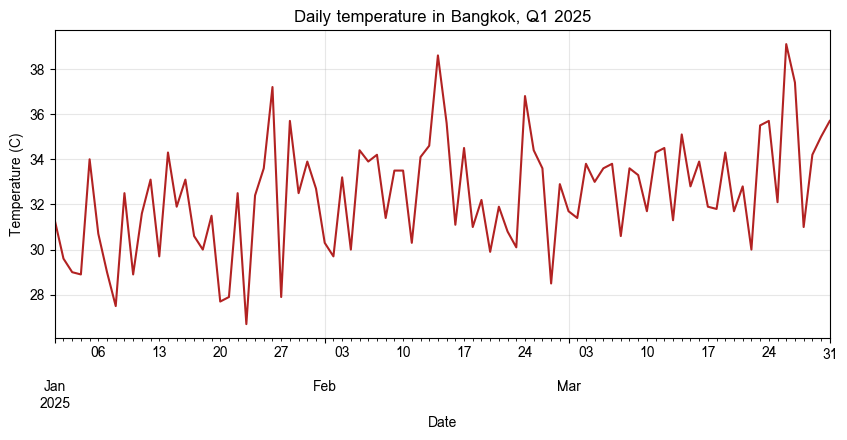

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

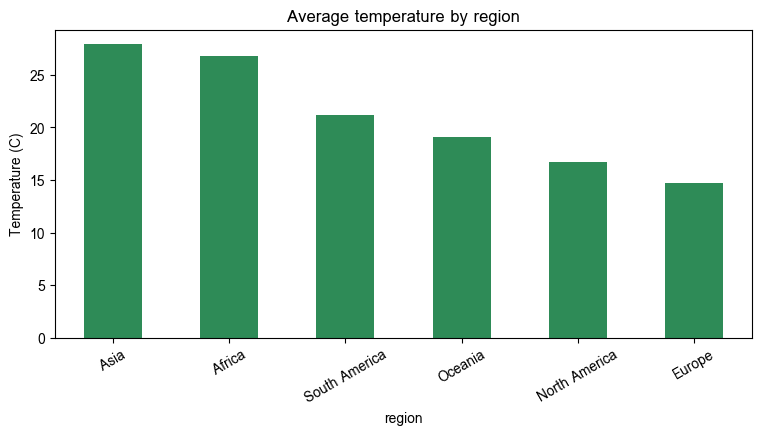

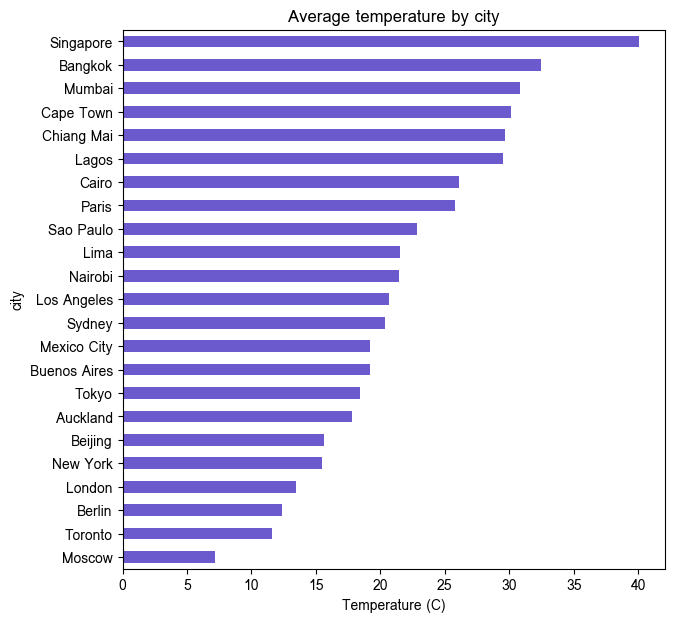

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

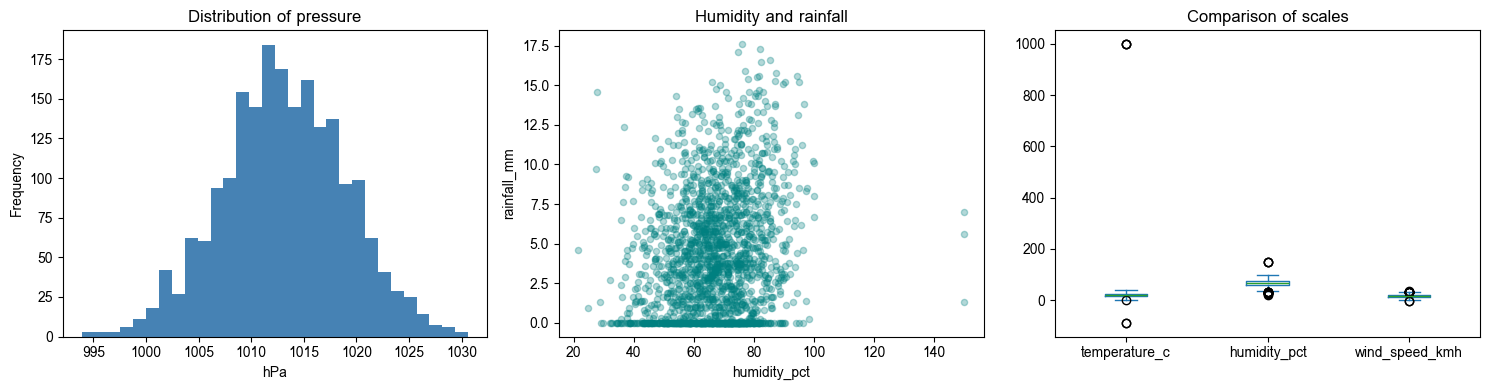

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

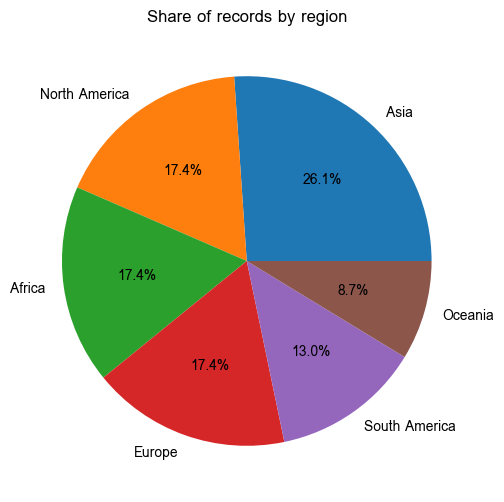

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

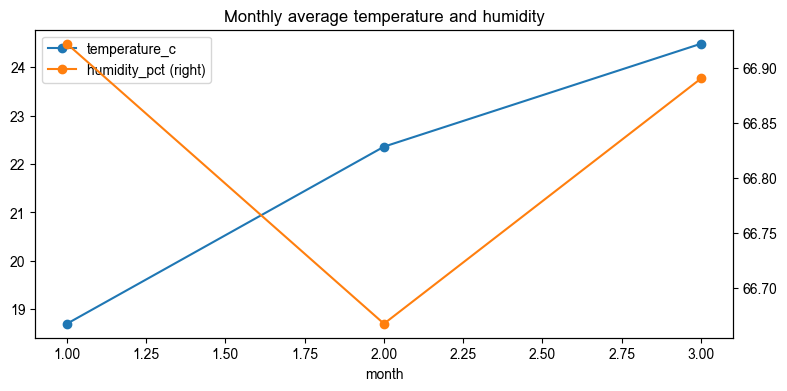

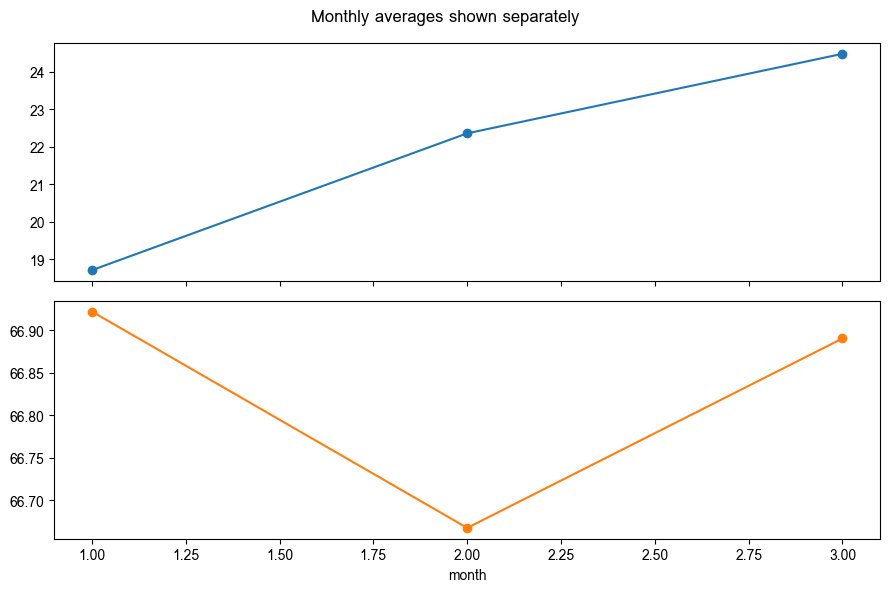

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

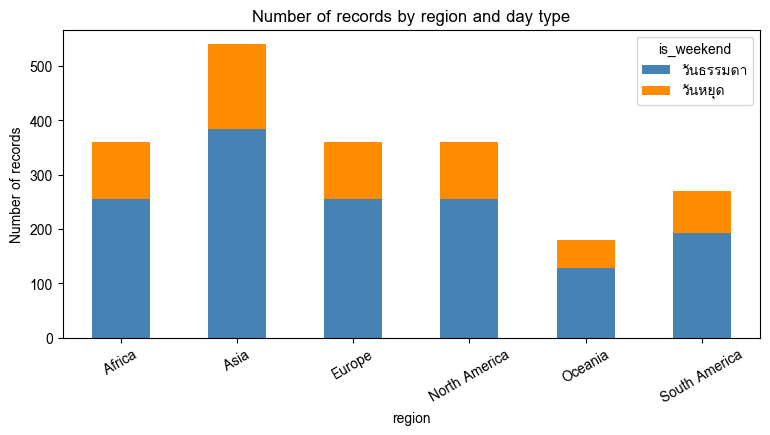

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

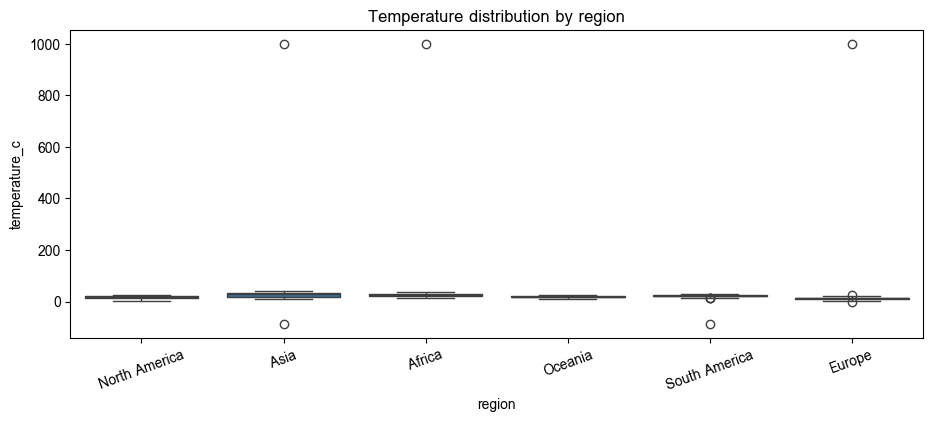

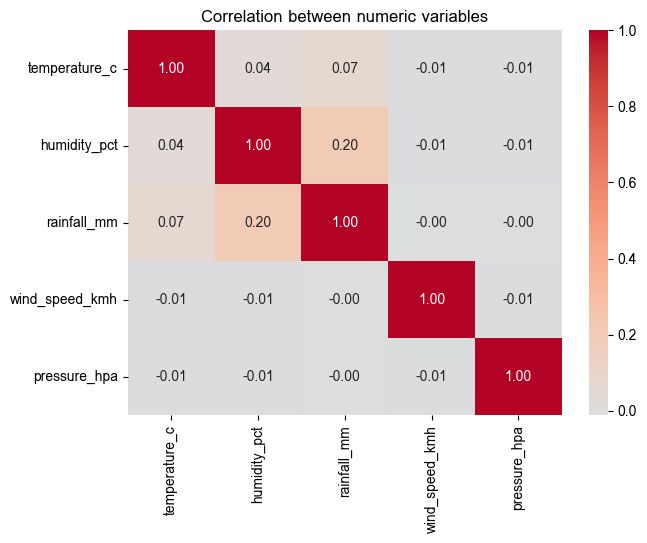

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

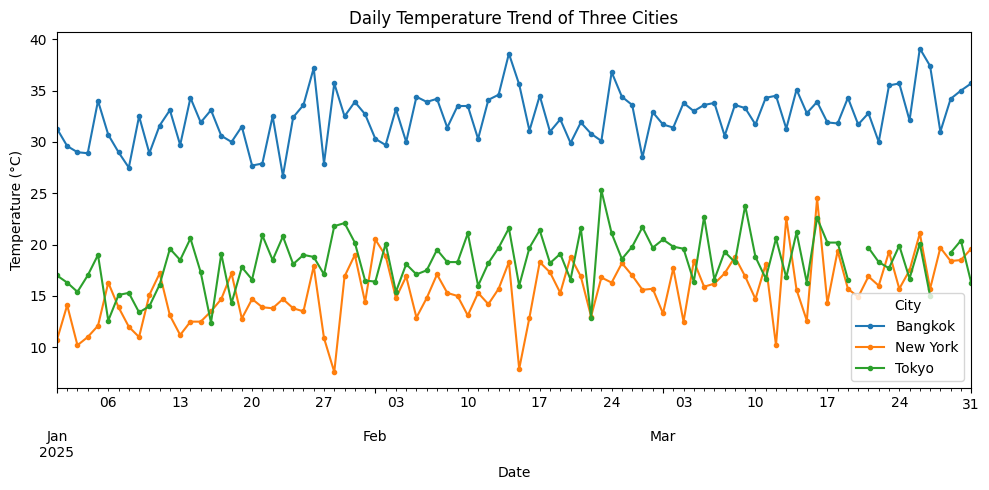

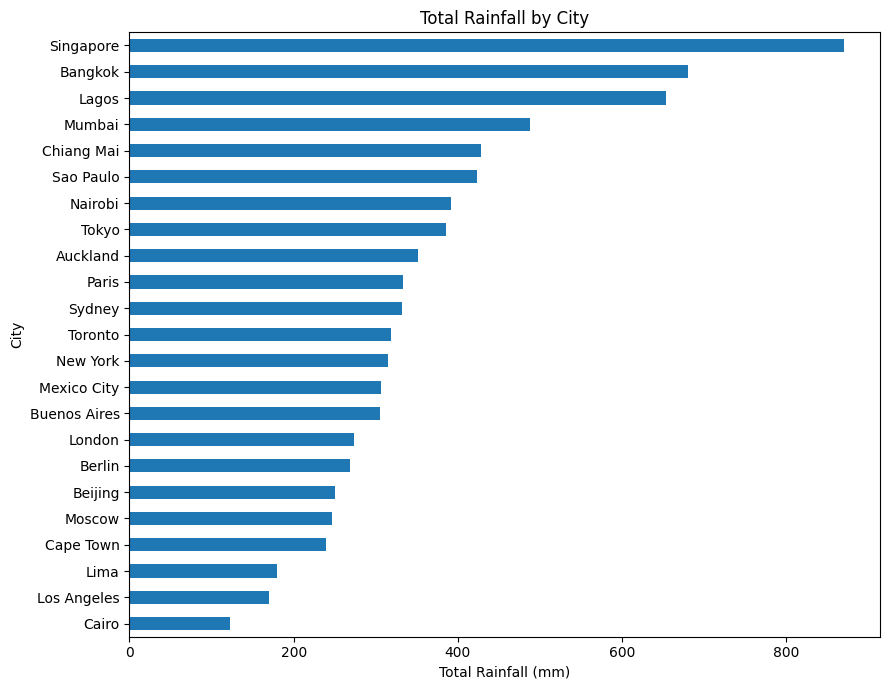

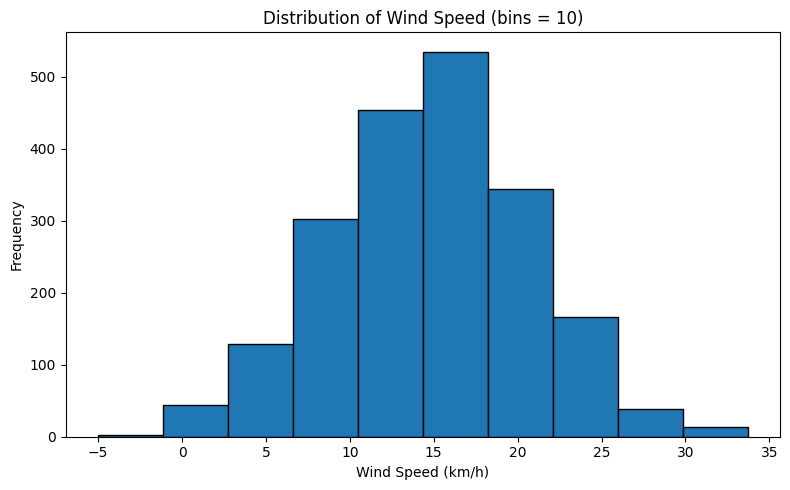

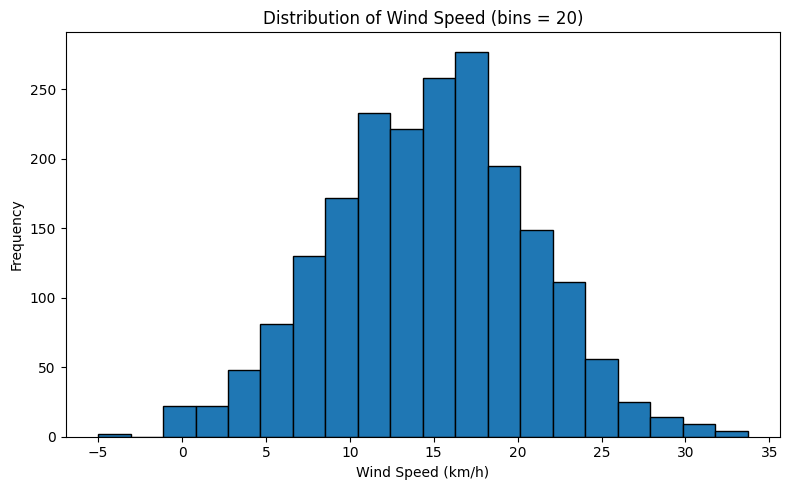

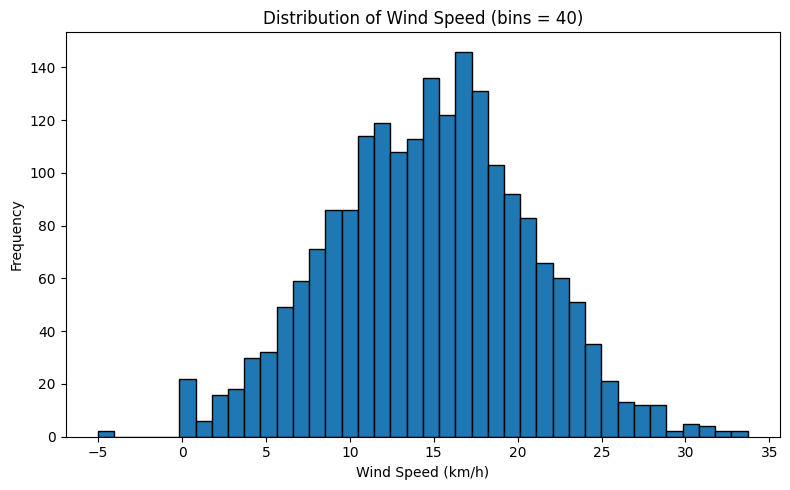

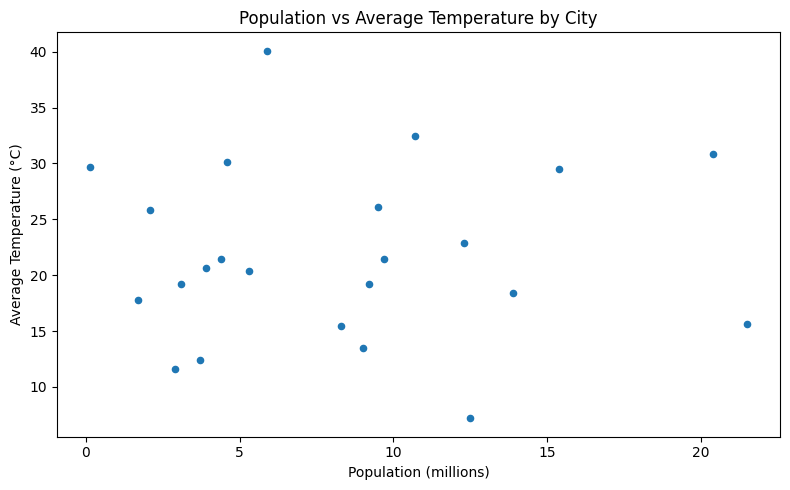

ข้อมูลที่ใช้สร้าง Scatter Plot:


,city,avg_temperature_c,population_millions
0,Beijing,15.598876,21.50
1,Mumbai,30.872222,20.40
2,Lagos,29.494253,15.40
3,Tokyo,18.414773,13.90
4,Moscow,7.192135,12.50
5,Sao Paulo,22.841573,12.30
6,Bangkok,32.438889,10.70
7,Lima,21.490000,9.70
8,Cairo,26.070455,9.50
9,Mexico City,19.187778,9.20


In [ ]:
# คำตอบข้อ 17.1

import matplotlib.pyplot as plt

# ============================================================
# 1) Line plot:
# แนวโน้มอุณหภูมิรายวันของ 3 เมือง
# ============================================================

selected_cities = ["Bangkok", "Tokyo", "New York"]

temp_daily = (
    df[df["city"].isin(selected_cities)]
    .pivot_table(
        index="date",
        columns="city",
        values="temperature_c",
        aggfunc="mean"
    )
    .sort_index()
)

ax1 = temp_daily.plot(
    figsize=(10, 5),
    marker="o",
    markersize=3
)

ax1.set_title("Daily Temperature Trend of Three Cities")
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (°C)")
ax1.legend(title="City")

plt.tight_layout()
plt.show()


# ============================================================
# 2) Horizontal bar plot:
# ปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
# ============================================================

rain_by_city = (
    df.groupby("city", observed=True)["rainfall_mm"]
    .sum()
    .sort_values(ascending=False)
)

ax2 = rain_by_city.plot(
    kind="barh",
    figsize=(9, 7)
)

ax2.invert_yaxis()
ax2.set_title("Total Rainfall by City")
ax2.set_xlabel("Total Rainfall (mm)")
ax2.set_ylabel("City")

plt.tight_layout()
plt.show()


# ============================================================
# 3) Histogram:
# ทดลอง bins 3 ค่าแตกต่างกัน
# ============================================================

for bins_value in [10, 20, 40]:

    ax3 = df["wind_speed_kmh"].plot(
        kind="hist",
        bins=bins_value,
        figsize=(8, 5),
        edgecolor="black"
    )

    ax3.set_title(
        f"Distribution of Wind Speed (bins = {bins_value})"
    )
    ax3.set_xlabel("Wind Speed (km/h)")
    ax3.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 4) Scatter plot:
# population_millions กับอุณหภูมิเฉลี่ยรายเมือง
# ============================================================

city_temp = (
    df.groupby("city", observed=True)["temperature_c"]
    .mean()
    .rename("avg_temperature_c")
    .reset_index()
)

city_scatter = city_temp.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left",
    validate="one_to_one"
)

ax4 = city_scatter.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temperature_c",
    figsize=(8, 5)
)

ax4.set_title("Population vs Average Temperature by City")
ax4.set_xlabel("Population (millions)")
ax4.set_ylabel("Average Temperature (°C)")

plt.tight_layout()
plt.show()


# ============================================================
# แสดงข้อมูลที่ใช้ใน scatter เพื่อตรวจสอบ
# ============================================================

print("ข้อมูลที่ใช้สร้าง Scatter Plot:")
display(
    city_scatter
    .sort_values("population_millions", ascending=False)
    .reset_index(drop=True)
)

### อธิบายผลข้อ 17.1

**1. กราฟเส้นแนวโน้มอุณหภูมิรายวันของ 3 เมือง**

จากกราฟพบว่า Bangkok มีอุณหภูมิสูงกว่า New York และ Tokyo
เกือบตลอดช่วงเดือนมกราคมถึงมีนาคม โดยส่วนใหญ่อยู่ประมาณ 28–38°C

Tokyo มีอุณหภูมิอยู่ระดับกลาง ส่วนใหญ่อยู่ประมาณ 15–22°C
ขณะที่ New York มีอุณหภูมิต่ำกว่าอีกสองเมืองเป็นส่วนใหญ่
และมีความผันผวนค่อนข้างมากในบางวัน

ดังนั้นกราฟเส้นช่วยให้เห็นทั้งระดับอุณหภูมิ
และการเปลี่ยนแปลงของแต่ละเมืองตามเวลาได้อย่างชัดเจน


**2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง**

เมื่อเรียงปริมาณฝนรวมจากมากไปน้อย
พบว่า Singapore มีปริมาณฝนรวมสูงที่สุด
รองลงมาคือ Bangkok และ Lagos

ส่วนเมืองที่มีปริมาณฝนรวมน้อยที่สุดคือ Cairo
โดยกราฟแท่งแนวนอนเหมาะกับข้อมูลนี้
เพราะมีจำนวนเมืองค่อนข้างมาก
และสามารถเปรียบเทียบลำดับของแต่ละเมืองได้ง่าย


**3. Histogram ของ wind_speed_kmh**

เมื่อใช้ `bins = 10`
กราฟจะแบ่งข้อมูลออกเป็นช่วงกว้าง
จึงเห็นภาพรวมของการกระจายได้ง่าย
โดยข้อมูลส่วนใหญ่กระจุกตัวอยู่ประมาณช่วง 10–20 km/h

เมื่อเพิ่มเป็น `bins = 20`
จะเห็นรายละเอียดของรูปแบบการกระจายมากขึ้น
และยังคงเห็นว่าค่าความเร็วลมส่วนใหญ่
อยู่บริเวณช่วงประมาณ 15–20 km/h

เมื่อใช้ `bins = 40`
แต่ละช่วงจะแคบลงมาก
ทำให้เห็นรายละเอียดและความผันผวนของข้อมูลมากที่สุด
แต่กราฟก็ดูไม่เรียบและซับซ้อนมากขึ้น

ดังนั้น การเลือกจำนวน bins มีผลต่อการตีความกราฟ
โดย bins น้อยเหมาะกับการดูภาพรวม
ส่วน bins มากเหมาะกับการดูรายละเอียดของการกระจาย

นอกจากนี้กราฟยังพบค่าความเร็วลมติดลบประมาณ -5 km/h
ซึ่งเป็นค่าที่ผิดปกติและควรตรวจสอบก่อนนำไปวิเคราะห์จริง


**4. Scatter Plot ระหว่างประชากรกับอุณหภูมิเฉลี่ยรายเมือง**

จากกราฟจุดยังไม่เห็นความสัมพันธ์ที่ชัดเจน
ระหว่างจำนวนประชากรของเมืองกับอุณหภูมิเฉลี่ย

เมืองที่มีประชากรสูงสามารถมีได้ทั้งอุณหภูมิสูงและต่ำ
เช่น Mumbai มีประชากรประมาณ 20.4 ล้านคน
แต่มีอุณหภูมิเฉลี่ยประมาณ 30.87°C
ขณะที่ Beijing มีประชากรประมาณ 21.5 ล้านคน
แต่อุณหภูมิเฉลี่ยประมาณ 15.60°C

ในทางกลับกัน Singapore มีประชากรประมาณ 5.9 ล้านคน
แต่มีค่าอุณหภูมิเฉลี่ยสูงประมาณ 40.08°C

ดังนั้น จากกราฟนี้ไม่สามารถสรุปได้ว่า
เมืองที่มีประชากรมากกว่าจะมีอุณหภูมิสูงกว่าหรือต่ำกว่าอย่างชัดเจน

อย่างไรก็ตาม ควรระมัดระวังในการตีความ
เพราะชุดข้อมูลมีค่าอุณหภูมิผิดปกติบางค่า
ซึ่งอาจทำให้ค่าเฉลี่ยของบางเมืองสูงกว่าความเป็นจริง

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

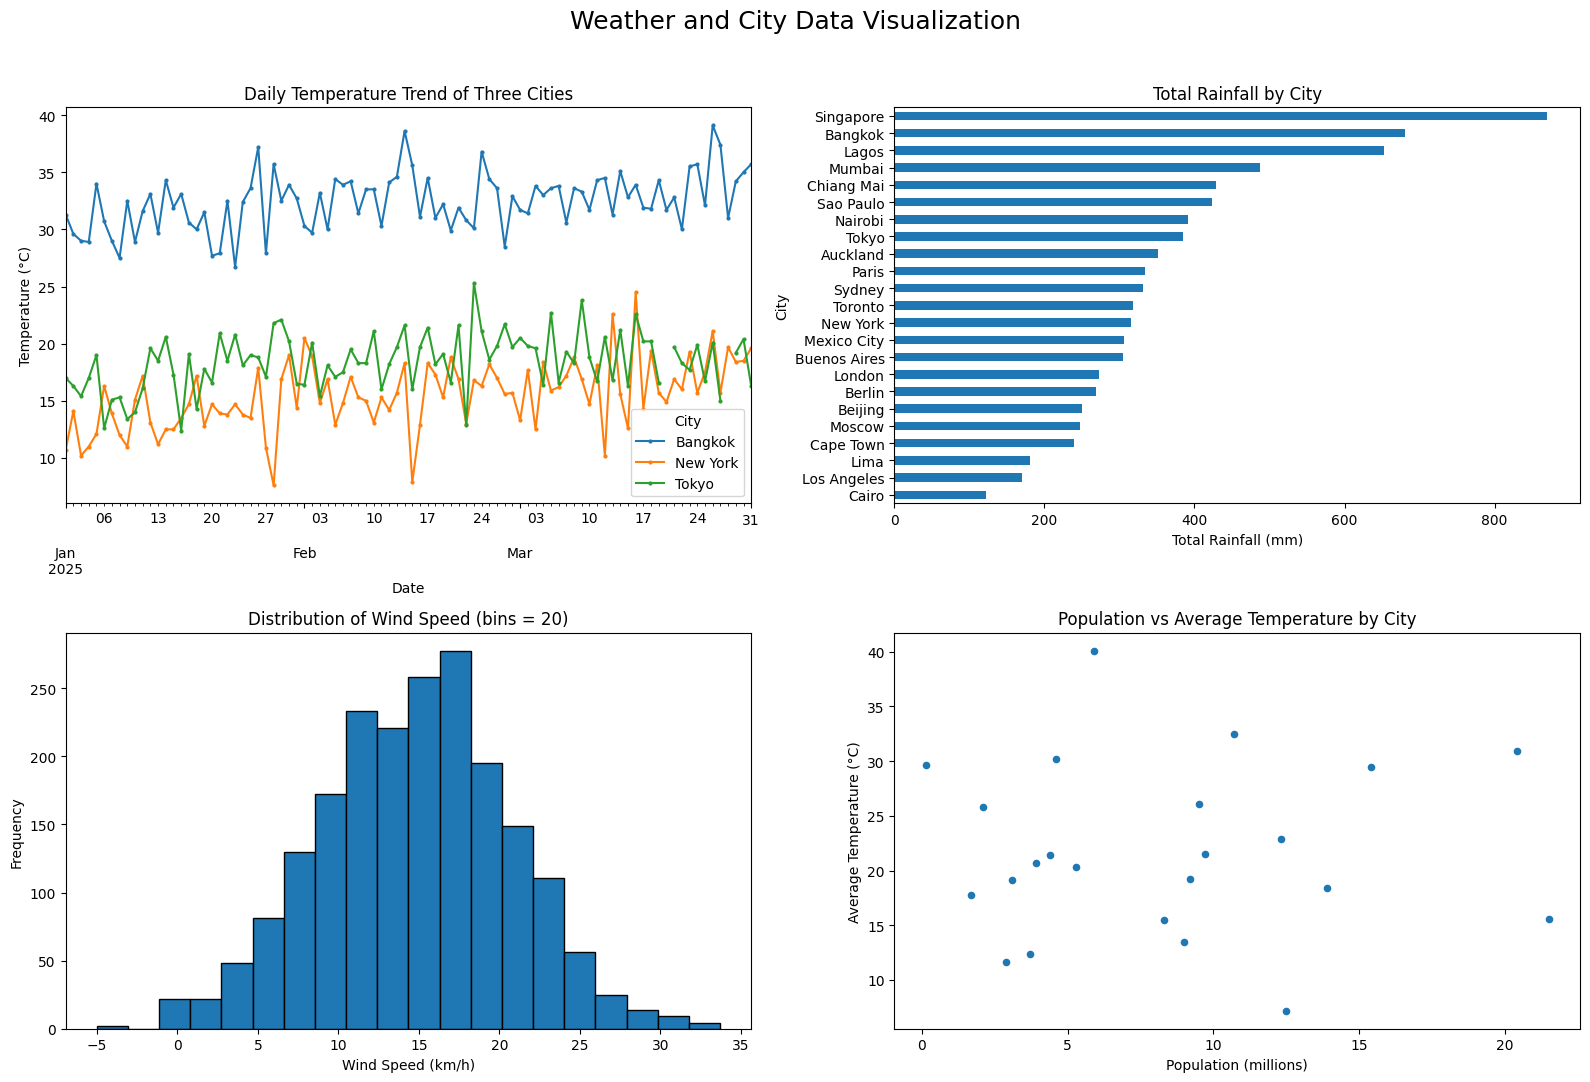

In [ ]:
# คำตอบข้อ 17.2

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ============================================================
# 1) Line plot: Daily temperature of 3 cities
# ============================================================

temp_daily.plot(
    ax=axes[0, 0],
    marker="o",
    markersize=2
)

axes[0, 0].set_title("Daily Temperature Trend of Three Cities")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].legend(title="City")


# ============================================================
# 2) Horizontal bar plot: Total rainfall by city
# ============================================================

rain_by_city.plot(
    kind="barh",
    ax=axes[0, 1]
)

axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Total Rainfall by City")
axes[0, 1].set_xlabel("Total Rainfall (mm)")
axes[0, 1].set_ylabel("City")


# ============================================================
# 3) Histogram: Wind speed
# ใช้ bins = 20 เป็นค่ากลางจากที่ทดลอง 10, 20, 40 ในข้อ 17.1
# ============================================================

df["wind_speed_kmh"].plot(
    kind="hist",
    bins=20,
    edgecolor="black",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribution of Wind Speed (bins = 20)")
axes[1, 0].set_xlabel("Wind Speed (km/h)")
axes[1, 0].set_ylabel("Frequency")


# ============================================================
# 4) Scatter plot: Population vs Average Temperature
# ============================================================

city_scatter.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temperature_c",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Population vs Average Temperature by City")
axes[1, 1].set_xlabel("Population (millions)")
axes[1, 1].set_ylabel("Average Temperature (°C)")


# ============================================================
# ชื่อรวมของภาพ
# ============================================================

fig.suptitle(
    "Weather and City Data Visualization",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### อธิบายผลข้อ 17.2

ในข้อนี้นำกราฟจากข้อ 17.1 มาจัดวางรวมกันในภาพเดียว
ด้วย `plt.subplots(2, 2)` ทำให้สามารถเปรียบเทียบข้อมูลหลายมุมมองได้พร้อมกัน

กราฟทั้ง 4 รูปประกอบด้วย

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของ Bangkok, New York และ Tokyo
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมของแต่ละเมือง
3. Histogram แสดงการกระจายของความเร็วลม โดยเลือกใช้ `bins = 20`
4. Scatter Plot แสดงความสัมพันธ์ระหว่างจำนวนประชากรกับอุณหภูมิเฉลี่ยรายเมือง

การจัดกราฟแบบ 2 × 2 ช่วยให้เห็นภาพรวมของข้อมูลได้ในหน้าเดียว
และสามารถเปรียบเทียบลักษณะของข้อมูลแต่ละประเภทได้สะดวกมากขึ้น

สำหรับ Histogram เลือกใช้ `bins = 20`
เนื่องจากให้รายละเอียดของการกระจายมากกว่า `bins = 10`
แต่ยังไม่ละเอียดและผันผวนมากเท่า `bins = 40`
จึงเหมาะสำหรับนำมาแสดงร่วมกับกราฟอื่นในภาพรวม

นอกจากนี้ได้กำหนดชื่อรวมของภาพด้วย `plt.suptitle()`
เพื่อสื่อว่ากราฟทั้งหมดเป็นการวิเคราะห์ข้อมูลด้านสภาพอากาศและเมืองร่วมกัน

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

จำนวนข้อมูลในแต่ละช่วงปริมาณฝน:


,count
rainfall_group,
No Rain (0 mm),469
Light Rain (>0-5 mm),802
Moderate Rain (>5-10 mm),560
Heavy Rain (>10 mm),177



จำนวนวันในแต่ละช่วงปริมาณฝน จำแนกตามภูมิภาค:


rainfall_group,No Rain (0 mm),Light Rain (>0-5 mm),Moderate Rain (>5-10 mm),Heavy Rain (>10 mm)
region,,,,
Africa,101,129,88,31
Asia,59,174,203,90
Europe,106,156,73,15
North America,92,161,84,11
Oceania,35,68,60,9
South America,76,114,52,21


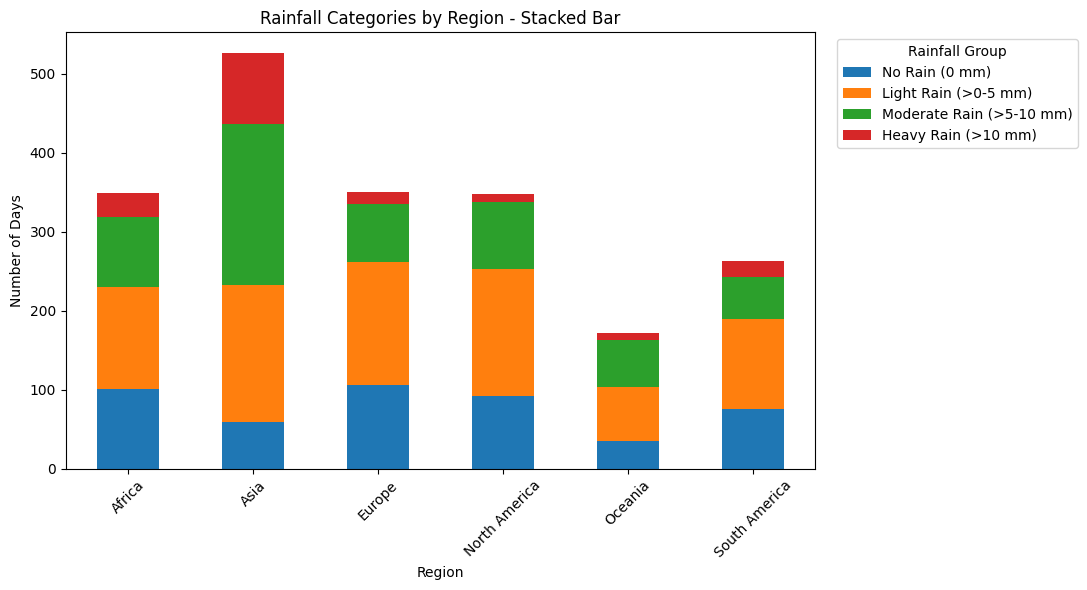

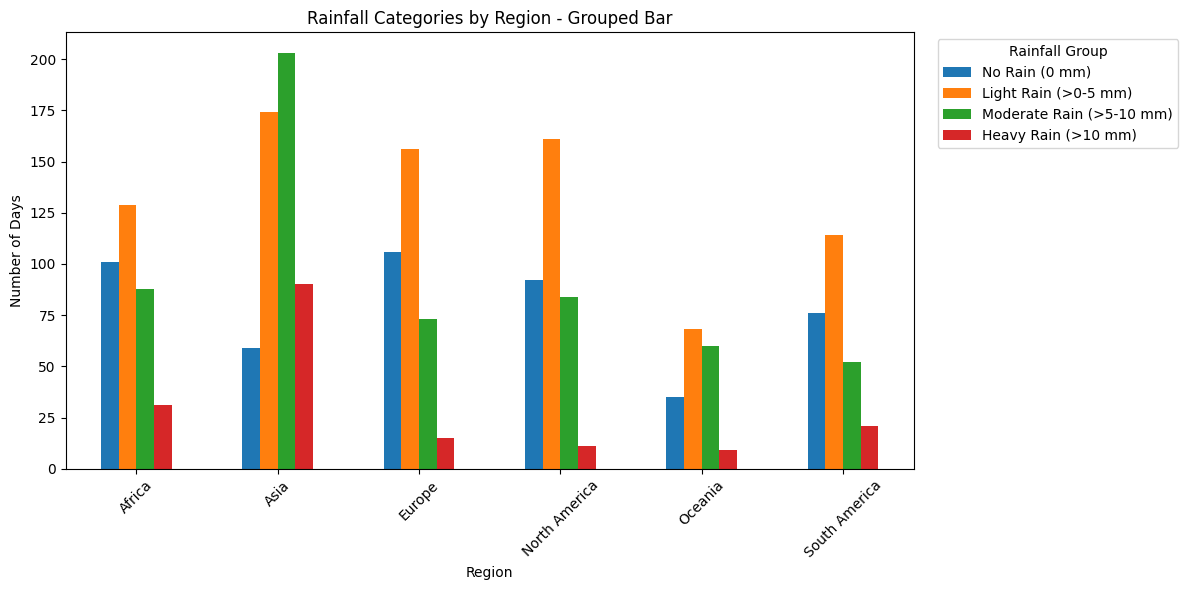

In [ ]:
# คำตอบข้อ 17.3

import matplotlib.pyplot as plt

# ============================================================
# 1) แบ่งช่วงปริมาณฝนด้วย pd.cut()
# ============================================================

rain_bins = [-float("inf"), 0, 5, 10, float("inf")]

rain_labels = [
    "No Rain (0 mm)",
    "Light Rain (>0-5 mm)",
    "Moderate Rain (>5-10 mm)",
    "Heavy Rain (>10 mm)"
]

df["rainfall_group"] = pd.cut(
    df["rainfall_mm"],
    bins=rain_bins,
    labels=rain_labels,
    include_lowest=True
)

print("จำนวนข้อมูลในแต่ละช่วงปริมาณฝน:")
display(
    df["rainfall_group"]
    .value_counts(sort=False)
    .to_frame("count")
)


# ============================================================
# 2) ตารางจำนวนวันแยกตาม region และ rainfall_group
# ============================================================

rain_region = pd.crosstab(
    df["region"],
    df["rainfall_group"],
    dropna=False
)

print("\nจำนวนวันในแต่ละช่วงปริมาณฝน จำแนกตามภูมิภาค:")
display(rain_region)


# ============================================================
# 3) Stacked bar chart
# ============================================================

ax1 = rain_region.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

ax1.set_title("Rainfall Categories by Region - Stacked Bar")
ax1.set_xlabel("Region")
ax1.set_ylabel("Number of Days")
ax1.legend(
    title="Rainfall Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 4) Grouped bar chart (stacked=False)
# ============================================================

ax2 = rain_region.plot(
    kind="bar",
    stacked=False,
    figsize=(12, 6)
)

ax2.set_title("Rainfall Categories by Region - Grouped Bar")
ax2.set_xlabel("Region")
ax2.set_ylabel("Number of Days")
ax2.legend(
    title="Rainfall Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### อธิบายผลข้อ 17.3

จากการแบ่งปริมาณฝนด้วย `pd.cut()` เป็น 4 ช่วง พบว่า

- No Rain (0 mm) = 469 แถว
- Light Rain (>0–5 mm) = 802 แถว
- Moderate Rain (>5–10 mm) = 560 แถว
- Heavy Rain (>10 mm) = 177 แถว

ดังนั้น ช่วงที่พบมากที่สุดคือ Light Rain
ส่วนช่วงที่พบน้อยที่สุดคือ Heavy Rain

เมื่อพิจารณาแยกตามภูมิภาค พบว่า Asia
มีจำนวนข้อมูลรวมในแต่ละช่วงฝนมากที่สุด
โดยเฉพาะ Moderate Rain จำนวน 203 แถว
และ Heavy Rain จำนวน 90 แถว

ในขณะที่ Oceania มีจำนวนข้อมูลรวมต่ำที่สุด
เมื่อเทียบกับภูมิภาคอื่น

กราฟแท่งซ้อน (`stacked=True`)
เหมาะเมื่อเราต้องการดูทั้งจำนวนรวมของแต่ละภูมิภาค
และดูว่าสัดส่วนภายในประกอบด้วยช่วงปริมาณฝนใดบ้าง
เช่น สามารถเห็นได้ชัดว่า Asia มีจำนวนวันรวมสูงกว่าภูมิภาคอื่น

ส่วนกราฟแท่งเรียงข้างกัน (`stacked=False`)
เหมาะเมื่อเราต้องการเปรียบเทียบแต่ละกลุ่มปริมาณฝน
ระหว่างภูมิภาคโดยตรง
เพราะแท่งของแต่ละกลุ่มเริ่มจากฐานเดียวกัน
ทำให้เปรียบเทียบความสูงได้ง่ายกว่า

ดังนั้น ถ้าต้องการดู "ภาพรวมและองค์ประกอบ"
กราฟแท่งซ้อนจะเหมาะสมกว่า
แต่ถ้าต้องการเปรียบเทียบค่าของแต่ละกลุ่มแบบละเอียด
กราฟแท่งเรียงข้างกันจะอ่านง่ายกว่า

นอกจากนี้ จำนวนข้อมูลที่ถูกจัดเข้ากลุ่มทั้งหมดเท่ากับ 2,008 แถว
ซึ่งน้อยกว่า df ทั้งหมด 2,070 แถว
แสดงว่ามีข้อมูลบางแถวที่ `rainfall_mm` เป็น NaN
จึงไม่ถูกจัดเข้าในช่วงของ `pd.cut()`

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

ค่า is_weekend:
is_weekend
False    1472
True      598
Name: count, dtype: int64

จำนวน population_millions ที่เป็น NaN = 0


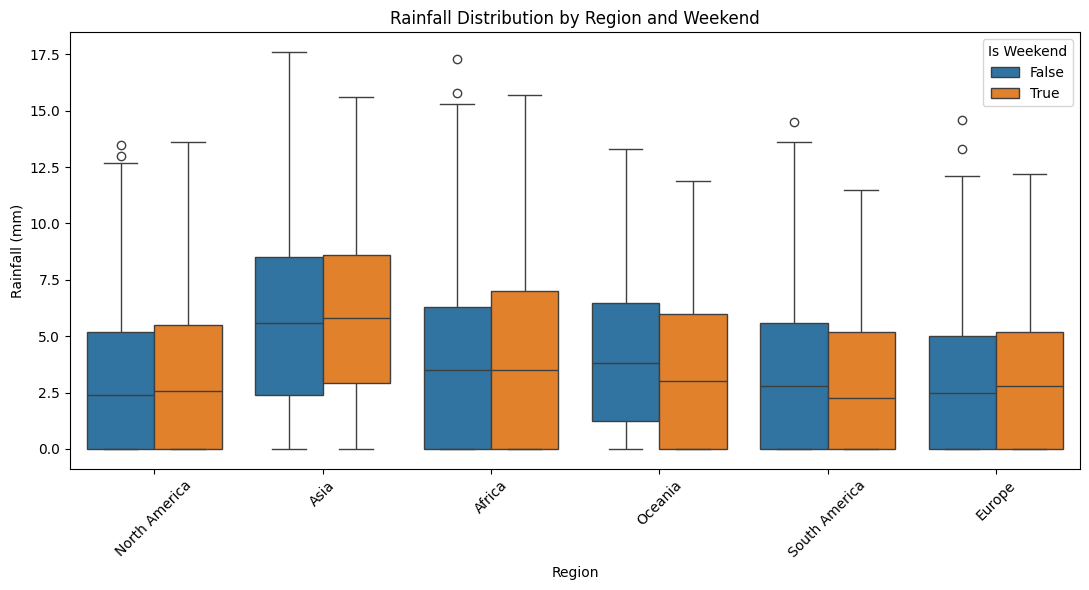


Correlation Matrix:


,temperature_c,humidity_pct,rainfall_mm,population_millions
temperature_c,1.000,0.038,0.068,0.003
humidity_pct,0.038,1.000,0.199,-0.106
rainfall_mm,0.068,0.199,1.000,0.061
population_millions,0.003,-0.106,0.061,1.000


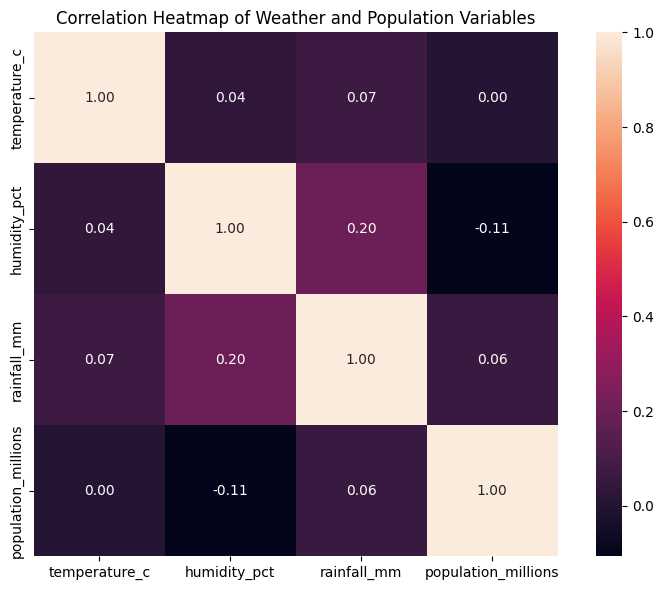

In [ ]:
# คำตอบข้อ 17.4

import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1) เตรียมข้อมูล
# ============================================================

df_174 = df.copy()

# สร้าง is_weekend จากวันที่
df_174["date"] = pd.to_datetime(df_174["date"])

df_174["is_weekend"] = (
    df_174["date"].dt.dayofweek >= 5
)

# เพิ่ม population_millions จาก city_info
df_174 = df_174.merge(
    city_info[["city", "population_millions"]],
    on="city",
    how="left",
    validate="many_to_one"
)

print("ค่า is_weekend:")
print(df_174["is_weekend"].value_counts())

print(
    "\nจำนวน population_millions ที่เป็น NaN =",
    df_174["population_millions"].isna().sum()
)


# ============================================================
# 2) Boxplot:
# rainfall_mm แยกตาม region และ is_weekend
# ============================================================

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_174,
    x="region",
    y="rainfall_mm",
    hue="is_weekend"
)

plt.title("Rainfall Distribution by Region and Weekend")
plt.xlabel("Region")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)
plt.legend(title="Is Weekend")

plt.tight_layout()
plt.show()


# ============================================================
# 3) Correlation Matrix
# ============================================================

corr_cols = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "population_millions"
]

corr_matrix = (
    df_174[corr_cols]
    .corr()
)

print("\nCorrelation Matrix:")
display(corr_matrix.round(3))


# ============================================================
# 4) Heatmap
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap of Weather and Population Variables")

plt.tight_layout()
plt.show()

### อธิบายผลข้อ 17.4

จากการแบ่งวันออกเป็นวันธรรมดาและวันหยุดสุดสัปดาห์
พบว่ามีวันธรรมดา (`False`) จำนวน 1,472 แถว
และวันหยุดสุดสัปดาห์ (`True`) จำนวน 598 แถว

**1. Boxplot ของปริมาณฝนจำแนกตามภูมิภาคและ is_weekend**

จากกราฟ boxplot พบว่า
การกระจายของปริมาณฝนในวันธรรมดาและวันหยุดสุดสัปดาห์
ของแต่ละภูมิภาคมีช่วงที่ค่อนข้างทับซ้อนกัน

Asia มีค่ากลางของปริมาณฝนค่อนข้างสูงกว่าหลายภูมิภาค
ทั้งในวันธรรมดาและวันหยุดสุดสัปดาห์

ขณะที่ North America, South America และ Europe
มีค่ากลางของปริมาณฝนอยู่ในระดับต่ำกว่า

ในบางภูมิภาคพบค่า outlier ของปริมาณฝน
ซึ่งแสดงว่ามีบางวันที่ปริมาณฝนสูงกว่าค่าปกติของกลุ่มอย่างชัดเจน

โดยรวมแล้ว จากกราฟนี้ยังไม่เห็นความแตกต่างที่เด่นชัด
ระหว่างปริมาณฝนในวันธรรมดากับวันหยุดสุดสัปดาห์
เพราะกล่องและช่วงการกระจายของทั้งสองกลุ่มทับซ้อนกันมาก


**2. Heatmap ของ Correlation**

จากตารางสหสัมพันธ์ พบว่า
ความสัมพันธ์ระหว่างตัวแปรส่วนใหญ่มีค่าค่อนข้างต่ำ

คู่ที่มีความสัมพันธ์เชิงบวกสูงที่สุดคือ
`humidity_pct` กับ `rainfall_mm`
โดยมีค่า correlation ประมาณ 0.199
แสดงถึงความสัมพันธ์เชิงบวกในระดับอ่อน
กล่าวคือ เมื่อความชื้นสูงขึ้น ปริมาณฝนอาจมีแนวโน้มเพิ่มขึ้นเล็กน้อย

`temperature_c` กับ `rainfall_mm`
มีค่า correlation ประมาณ 0.068
และ `temperature_c` กับ `humidity_pct`
มีค่าประมาณ 0.038
ซึ่งถือว่าเป็นความสัมพันธ์ที่อ่อนมาก

สำหรับ `temperature_c` กับ `population_millions`
มีค่า correlation ประมาณ 0.003
ซึ่งใกล้ศูนย์มาก
จึงไม่พบความสัมพันธ์เชิงเส้นที่ชัดเจนระหว่าง
จำนวนประชากรกับอุณหภูมิในชุดข้อมูลนี้

ส่วน `humidity_pct` กับ `population_millions`
มีค่า correlation ประมาณ -0.106
เป็นความสัมพันธ์เชิงลบในระดับอ่อน

ดังนั้น จาก heatmap นี้
ยังไม่พบคู่ตัวแปรใดที่มีความสัมพันธ์เชิงเส้นในระดับสูง
โดยคู่ที่เห็นความสัมพันธ์ชัดที่สุดคือ
ความชื้นกับปริมาณฝน แต่ก็ยังเป็นเพียงความสัมพันธ์ระดับอ่อน

ทั้งนี้ ค่า correlation แสดงเพียงความสัมพันธ์เชิงเส้น
และไม่ได้หมายความว่าตัวแปรหนึ่งเป็นสาเหตุของอีกตัวแปรหนึ่ง

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

จำนวนค่าอุณหภูมิผิดปกติที่เปลี่ยนเป็น NaN = 5

ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวันตามภูมิภาค:


,temperature_std
region,
Asia,7.16
Africa,4.88
North America,4.52
Europe,4.07
Oceania,3.08
South America,3.06



ภูมิภาคที่แปรปรวนที่สุด = Asia

ความแปรปรวนรายเมืองภายใน Asia:


,std,count
city,,
Beijing,2.87,89
Chiang Mai,2.86,90
Singapore,2.71,88
Mumbai,2.54,90
Tokyo,2.52,88
Bangkok,2.49,90


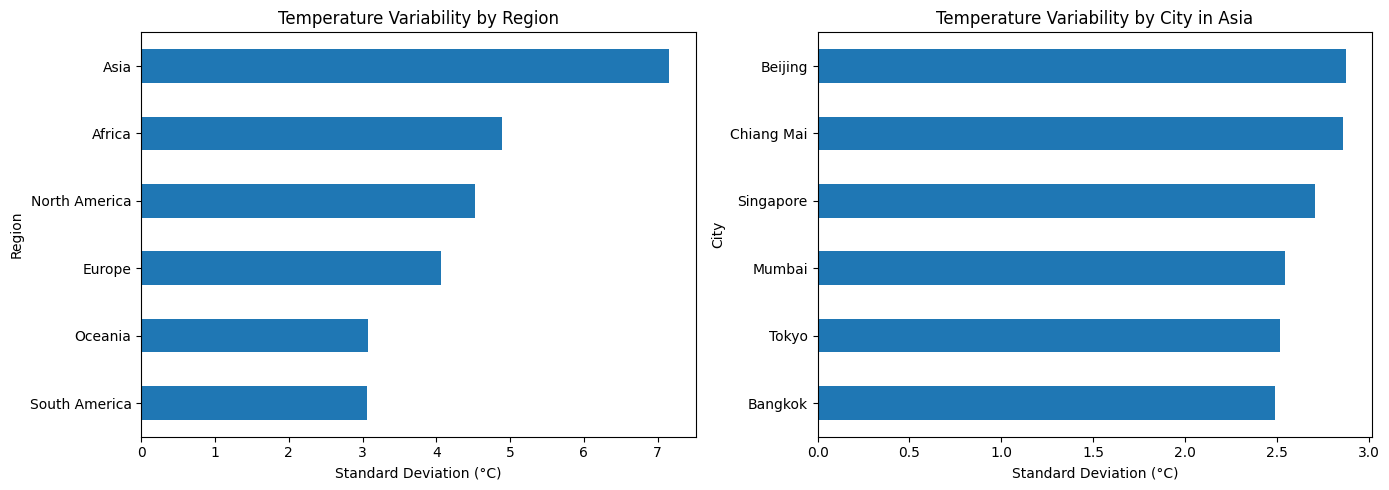

In [ ]:
# คำตอบข้อ 18.1

import matplotlib.pyplot as plt

# ============================================================
# 1) สร้างตารางรวมจาก 3 แหล่ง
#    weather + city_info + region_info
# ============================================================

analysis_18 = (
    df[
        [
            "record_id", "date", "city", "country", "region",
            "temperature_c", "humidity_pct", "rainfall_mm",
            "wind_speed_kmh", "pressure_hpa"
        ]
    ]
    .drop_duplicates()
    .merge(
        city_info[["city", "population_millions", "timezone"]],
        on="city",
        how="left",
        validate="many_to_one"
    )
    .merge(
        region_info,
        on="region",
        how="left",
        validate="many_to_one"
    )
)

analysis_18["date"] = pd.to_datetime(analysis_18["date"])


# ============================================================
# 2) ทำความสะอาดอุณหภูมิ
#    ค่านอกช่วง -60 ถึง 60°C ให้เป็น NaN
# ============================================================

analysis_18["temperature_clean"] = (
    analysis_18["temperature_c"]
    .where(analysis_18["temperature_c"].between(-60, 60))
)

print(
    "จำนวนค่าอุณหภูมิผิดปกติที่เปลี่ยนเป็น NaN =",
    (
        analysis_18["temperature_c"].notna()
        & ~analysis_18["temperature_c"].between(-60, 60)
    ).sum()
)


# ============================================================
# 3) เลือกข้อมูลไตรมาสแรก
# ============================================================

q1 = analysis_18[
    analysis_18["date"].dt.month.isin([1, 2, 3])
]


# ============================================================
# 4) ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวันแต่ละ region
# ============================================================

region_std = (
    q1.groupby("region", observed=True)["temperature_clean"]
    .std()
    .sort_values(ascending=False)
)

print("\nส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวันตามภูมิภาค:")
display(
    region_std
    .round(2)
    .to_frame("temperature_std")
)

most_variable_region = region_std.index[0]

print(
    "\nภูมิภาคที่แปรปรวนที่สุด =",
    most_variable_region
)


# ============================================================
# 5) ตรวจสอบเมืองภายในภูมิภาคที่แปรปรวนที่สุด
# ============================================================

city_std = (
    q1[q1["region"] == most_variable_region]
    .groupby("city", observed=True)["temperature_clean"]
    .agg(["std", "count"])
    .sort_values("std", ascending=False)
)

print(
    f"\nความแปรปรวนรายเมืองภายใน {most_variable_region}:"
)

display(
    city_std.round(2)
)


# ============================================================
# 6) กราฟเปรียบเทียบ
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_std.sort_values().plot(
    kind="barh",
    ax=axes[0]
)

axes[0].set_title("Temperature Variability by Region")
axes[0].set_xlabel("Standard Deviation (°C)")
axes[0].set_ylabel("Region")


city_std["std"].sort_values().plot(
    kind="barh",
    ax=axes[1]
)

axes[1].set_title(
    f"Temperature Variability by City in {most_variable_region}"
)
axes[1].set_xlabel("Standard Deviation (°C)")
axes[1].set_ylabel("City")

plt.tight_layout()
plt.show()

### สรุปผลข้อ 18.1

หลังเปลี่ยนค่าอุณหภูมิผิดปกติ 5 ค่าเป็น `NaN`
พบว่า Asia มีความแปรปรวนสูงที่สุด โดยมีส่วนเบี่ยงเบนมาตรฐาน 7.16°C

เมื่อพิจารณารายเมืองใน Asia ค่า std อยู่ใกล้เคียงกันประมาณ 2.49–2.87°C
จึงสรุปได้ว่าความแปรปรวนไม่ได้เกิดจากเมืองใดเมืองหนึ่งเป็นหลัก
แต่เกิดจากความแตกต่างของอุณหภูมิระหว่างหลายเมืองในภูมิภาค

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [ ]:
# คำตอบข้อ 18.2

# ============================================================
# 1) สรุปจำนวนวันฝนตกหนักและจำนวนวันที่มีข้อมูลฝน
#    กำหนด Heavy Rain = rainfall_mm > 10
# ============================================================

heavy_rain_summary = (
    analysis_18
    .groupby("city", observed=True)["rainfall_mm"]
    .agg(
        observed_days="count",
        heavy_rain_days=lambda s: (s > 10).sum()
    )
)

heavy_rain_summary["heavy_rain_pct"] = (
    heavy_rain_summary["heavy_rain_days"]
    / heavy_rain_summary["observed_days"]
    * 100
)


# ============================================================
# 2) Top 5 เมื่อวัดด้วย "สัดส่วน"
# ============================================================

top5_proportion = (
    heavy_rain_summary
    .sort_values(
        ["heavy_rain_pct", "heavy_rain_days"],
        ascending=False
    )
    .head(5)
    .reset_index()
)

top5_proportion.insert(
    0, "rank_by_proportion",
    range(1, len(top5_proportion) + 1)
)


# ============================================================
# 3) Top 5 เมื่อวัดด้วย "จำนวนวัน"
# ============================================================

top5_count = (
    heavy_rain_summary
    .sort_values(
        ["heavy_rain_days", "heavy_rain_pct"],
        ascending=False
    )
    .head(5)
    .reset_index()
)

top5_count.insert(
    0, "rank_by_count",
    range(1, len(top5_count) + 1)
)


# ============================================================
# 4) แสดงผลเปรียบเทียบ
# ============================================================

print("Top 5 เมื่อวัดด้วยสัดส่วน:")
display(
    top5_proportion.round({
        "heavy_rain_pct": 2
    })
)

print("\nTop 5 เมื่อวัดด้วยจำนวนวัน:")
display(
    top5_count.round({
        "heavy_rain_pct": 2
    })
)

Top 5 เมื่อวัดด้วยสัดส่วน:


,rank_by_proportion,city,observed_days,heavy_rain_days,heavy_rain_pct
0,1,Singapore,90,44,48.89
1,2,Bangkok,87,23,26.44
2,3,Lagos,88,22,25.00
3,4,Sao Paulo,88,11,12.50
4,5,Chiang Mai,85,9,10.59



Top 5 เมื่อวัดด้วยจำนวนวัน:


,rank_by_count,city,observed_days,heavy_rain_days,heavy_rain_pct
0,1,Singapore,90,44,48.89
1,2,Bangkok,87,23,26.44
2,3,Lagos,88,22,25.00
3,4,Sao Paulo,88,11,12.50
4,5,Chiang Mai,85,9,10.59


### สรุปผลข้อ 18.2

เมื่อวัดด้วยสัดส่วน เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกคือ
Singapore, Bangkok, Lagos, Sao Paulo และ Chiang Mai

ผลลัพธ์เหมือนกับการจัดอันดับด้วยจำนวนวันทั้งหมด
โดย Singapore สูงสุดที่ 44 วันจาก 90 วัน หรือ 48.89%

สาเหตุที่สองวิธีให้ผลเหมือนกันในครั้งนี้
เพราะจำนวนวันที่มีข้อมูลของแต่ละเมืองใกล้เคียงกันมาก
จึงทำให้อันดับจากจำนวนวันและจากสัดส่วนไม่เปลี่ยนแปลง

อย่างไรก็ตาม การใช้สัดส่วนเหมาะกว่าเมื่อแต่ละเมืองมีจำนวนวันที่มีข้อมูลไม่เท่ากัน
เพราะช่วยลดผลกระทบจากข้อมูลที่ขาดหาย

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

ตารางข้อมูลระดับเมือง:


,city,population_millions,avg_temperature_c,avg_rainfall_mm
0,Auckland,1.70,17.80,4.14
1,Bangkok,10.70,32.44,7.82
2,Beijing,21.50,15.60,2.84
3,Berlin,3.70,12.38,3.09
4,Buenos Aires,3.10,20.39,3.47
5,Cairo,9.50,26.07,1.41
6,Cape Town,4.60,19.15,2.75
7,Chiang Mai,0.13,29.65,5.04
8,Lagos,15.40,29.49,7.42
9,Lima,9.70,21.49,2.07



Correlation กับจำนวนประชากร:


,correlation
avg_temperature_c,0.159
avg_rainfall_mm,0.123


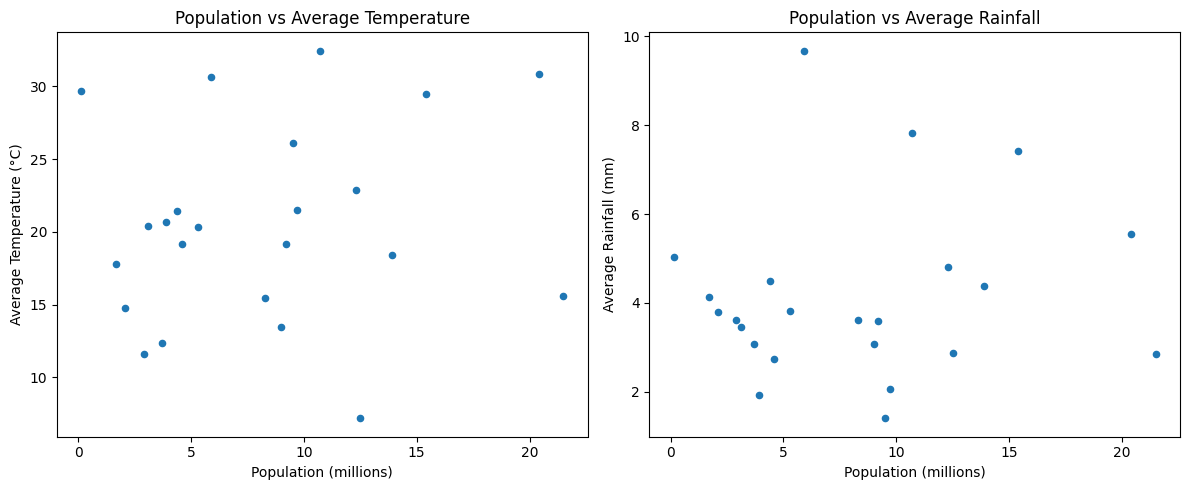

In [ ]:
# คำตอบข้อ 18.3

import matplotlib.pyplot as plt

# ============================================================
# 1) สรุปข้อมูลให้เป็นระดับเมือง
#    ใช้อุณหภูมิที่ทำความสะอาดแล้วจากข้อ 18.1
# ============================================================

city_relation = (
    analysis_18
    .assign(
        temperature_clean=lambda x:
            x["temperature_c"].where(
                x["temperature_c"].between(-60, 60)
            )
    )
    .groupby("city", observed=True)
    .agg(
        population_millions=("population_millions", "first"),
        avg_temperature_c=("temperature_clean", "mean"),
        avg_rainfall_mm=("rainfall_mm", "mean")
    )
    .dropna()
    .reset_index()
)

print("ตารางข้อมูลระดับเมือง:")
display(
    city_relation.round(2)
)


# ============================================================
# 2) คำนวณ correlation
# ============================================================

corr_population = (
    city_relation[
        [
            "population_millions",
            "avg_temperature_c",
            "avg_rainfall_mm"
        ]
    ]
    .corr()
    .loc[
        "population_millions",
        ["avg_temperature_c", "avg_rainfall_mm"]
    ]
)

print("\nCorrelation กับจำนวนประชากร:")
display(
    corr_population
    .round(3)
    .to_frame("correlation")
)


# ============================================================
# 3) Scatter plots สำหรับดูความสัมพันธ์
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

city_relation.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temperature_c",
    ax=axes[0]
)

axes[0].set_title("Population vs Average Temperature")
axes[0].set_xlabel("Population (millions)")
axes[0].set_ylabel("Average Temperature (°C)")


city_relation.plot(
    kind="scatter",
    x="population_millions",
    y="avg_rainfall_mm",
    ax=axes[1]
)

axes[1].set_title("Population vs Average Rainfall")
axes[1].set_xlabel("Population (millions)")
axes[1].set_ylabel("Average Rainfall (mm)")

plt.tight_layout()
plt.show()

### สรุปผลข้อ 18.3

เมื่อวิเคราะห์ในระดับเมือง พบว่า
จำนวนประชากรมีความสัมพันธ์เชิงบวกกับอุณหภูมิเฉลี่ยเพียงเล็กน้อย
โดยมีค่า correlation = 0.159

ส่วนความสัมพันธ์กับปริมาณฝนเฉลี่ยก็อยู่ในระดับต่ำ
โดยมีค่า correlation = 0.123

ดังนั้น ยังไม่พบความสัมพันธ์ที่ชัดเจนระหว่างจำนวนประชากร
กับอุณหภูมิหรือปริมาณฝนในชุดข้อมูลนี้

ทั้งนี้ correlation แสดงเพียงความสัมพันธ์เชิงเส้น
และไม่สามารถสรุปความเป็นเหตุเป็นผลได้

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

เดือนที่ควรหลีกเลี่ยงมากที่สุดของแต่ละภูมิภาค:


,region,month_name,heavy_rain_pct,avg_wind_kmh,temp_std,travel_risk_score
0,Asia,January,15.93,15.09,7.27,0.94
1,Africa,January,10.00,15.59,4.55,0.80
2,South America,January,8.79,14.95,3.04,0.59
3,Europe,February,3.70,15.01,3.98,0.57
4,North America,February,3.67,14.88,4.32,0.54
5,Oceania,March,10.91,14.55,2.75,0.46


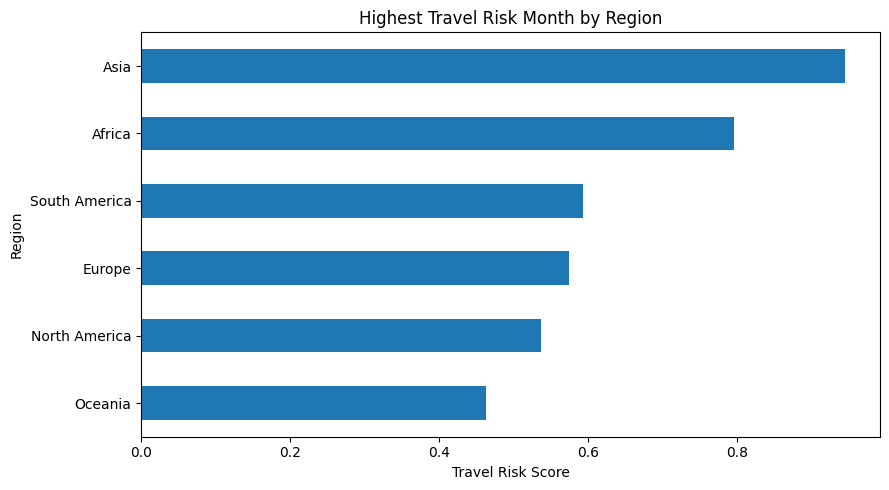

In [ ]:
# คำตอบข้อ 18.4

import matplotlib.pyplot as plt

# ============================================================
# 1) เตรียมข้อมูล
#    - temperature นอก -60 ถึง 60°C -> NaN
#    - wind_speed ติดลบ -> NaN
# ============================================================

travel_data = (
    analysis_18
    .assign(
        month=lambda x: x["date"].dt.month,
        temperature_clean=lambda x:
            x["temperature_c"].where(
                x["temperature_c"].between(-60, 60)
            ),
        wind_clean=lambda x:
            x["wind_speed_kmh"].where(
                x["wind_speed_kmh"] >= 0
            )
    )
)


# ============================================================
# 2) สรุปข้อมูลระดับ region × month
#
# ใช้ 3 เกณฑ์:
# - heavy_rain_pct  = สัดส่วนวันที่มีฝน > 10 mm
# - avg_wind_kmh    = ความเร็วลมเฉลี่ย
# - temp_std        = ความผันผวนของอุณหภูมิ
# ============================================================

region_month_risk = (
    travel_data
    .groupby(["region", "month"], observed=True)
    .agg(
        observed_rain=("rainfall_mm", "count"),
        heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
        avg_wind_kmh=("wind_clean", "mean"),
        temp_std=("temperature_clean", "std")
    )
    .reset_index()
)

region_month_risk["heavy_rain_pct"] = (
    region_month_risk["heavy_rain_days"]
    / region_month_risk["observed_rain"]
    * 100
)


# ============================================================
# 3) ทำคะแนนให้อยู่ในสเกลเดียวกันด้วย percentile rank
# ============================================================

region_month_risk["rain_score"] = (
    region_month_risk["heavy_rain_pct"].rank(pct=True)
)

region_month_risk["wind_score"] = (
    region_month_risk["avg_wind_kmh"].rank(pct=True)
)

region_month_risk["temp_score"] = (
    region_month_risk["temp_std"].rank(pct=True)
)

region_month_risk["travel_risk_score"] = (
    region_month_risk[
        ["rain_score", "wind_score", "temp_score"]
    ].mean(axis=1)
)


# ============================================================
# 4) เลือกเดือนที่มีคะแนนสูงสุดของแต่ละภูมิภาค
# ============================================================

worst_month = (
    region_month_risk
    .sort_values(
        ["region", "travel_risk_score"],
        ascending=[True, False]
    )
    .groupby("region", observed=True)
    .head(1)
    .sort_values("travel_risk_score", ascending=False)
    .reset_index(drop=True)
)

month_name = {
    1: "January",
    2: "February",
    3: "March"
}

worst_month["month_name"] = (
    worst_month["month"].map(month_name)
)


print("เดือนที่ควรหลีกเลี่ยงมากที่สุดของแต่ละภูมิภาค:")

display(
    worst_month[
        [
            "region",
            "month_name",
            "heavy_rain_pct",
            "avg_wind_kmh",
            "temp_std",
            "travel_risk_score"
        ]
    ].round(2)
)


# ============================================================
# 5) กราฟสรุป
# ============================================================

plot_data = (
    worst_month
    .set_index("region")["travel_risk_score"]
    .sort_values()
)

ax = plot_data.plot(
    kind="barh",
    figsize=(9, 5)
)

ax.set_title("Highest Travel Risk Month by Region")
ax.set_xlabel("Travel Risk Score")
ax.set_ylabel("Region")

plt.tight_layout()
plt.show()

### สรุปผลข้อ 18.4

กำหนดเกณฑ์ความเสี่ยงจาก 3 ปัจจัย ได้แก่
สัดส่วนวันที่ฝนตกหนัก ความเร็วลมเฉลี่ย และความแปรปรวนของอุณหภูมิ
โดยแปลงแต่ละตัวเป็นคะแนนในสเกลเดียวกันก่อนนำมาเฉลี่ย

ผลพบว่า Asia และ Africa ควรหลีกเลี่ยงเดือน January มากที่สุด
ส่วน Europe และ North America คือ February
และ Oceania คือ March

Asia มีคะแนนความเสี่ยงสูงที่สุดที่ 0.94
เนื่องจากมีทั้งสัดส่วนฝนตกหนักและความแปรปรวนของอุณหภูมิสูง

ดังนั้น เดือนที่ควรหลีกเลี่ยงแตกต่างกันตามภูมิภาค
เพราะลักษณะสภาพอากาศของแต่ละพื้นที่ไม่เหมือนกัน

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️